# **Beyond Brute Force**
## Optimizing a from-scratch Search Engine from Inverted Index to WAND

### Project Authors

*   *Valentina Bertei*
*   *Alex Sgammato*
*   *Francesco Tarchi*
*   *Alessandro Tumminelli*

### Introduction and Project Scope
Information Retrieval (IR) is the task at the heart of every search engine: given a free-text query, the system must return, in a fraction of a second, a ranked list of the most relevant documents from a collection that may contain millions of items. This goes beyond simple keyword matching, since the system must decide not only *which* documents match a query, but also *how well* each of them does.

### Objective
The primary objective of this project is to build, optimize, and rigorously evaluate, entirely from scratch, a ranked retrieval system based on a compressed inverted index, capable of answering queries over the **MS MARCO Passage Ranking** collection (≈8.8 million passages) and of competing in quality with an established IR framework such as **PyTerrier**.

### The Challenge
Building a search engine at this scale inherently suffers from severe challenges:
1. **Collection size:** with millions of passages, both the raw collection and the uncompressed index are too large to be handled naively in memory, and a sequential pure-Python indexer becomes a major bottleneck.
2. **Efficiency vs. memory trade-off:** naive matching strategies scan every posting list from beginning to end, scoring documents that will never reach the top-*k*, while keeping intermediate scores in memory inflates peak memory usage.
3. **Ranking quality and reliable evaluation:** different weighting models and matching strategies produce rankings that differ only slightly, and such differences may stem from tie-breaking or floating-point effects rather than from genuine improvements: only a proper statistical analysis can tell them apart.

### Project Roadmap
To address these challenges, this notebook documents a systematic, iterative approach:

* **Phase 1: Index Engineering:** implementing the text preprocessing pipeline and building a disk-based inverted index compressed with **d-gaps** and **Variable-Byte encoding**, then parallelizing the indexer with a **MapReduce**-style architecture (multiprocessing and memory mapping) and validating the index through **Boolean retrieval** (conjunctive and disjunctive queries).
* **Phase 2: Baseline Ranked Retrieval:** implementing **TAAT** (Term-At-A-Time) and **DAAT** (Document-At-A-Time) matching strategies combined with three weighting models (**TF**, **TF-IDF** and **BM25**), to establish our initial execution time and peak memory metrics.
* **Phase 3: Query Processing Optimization:** removing the object-oriented overhead of the baseline (posting-list iterators, auxiliary classes and repeated function calls) in favor of native iterators and inlined logic, in order to drastically cut execution time without increasing memory usage.
* **Phase 4: Dynamic Pruning:** introducing the **WAND** (Weak AND) algorithm with upper bounds pre-computed at indexing time, to skip documents that cannot enter the top-*k*, and analyzing how the tightness of such bounds makes its efficiency depend on the chosen weighting model.
* **Phase 5: Relevance Evaluation and Statistical Validation:** measuring the effectiveness of all nine combinations of matching strategy and weighting model on the *test-2019* and *test-2020* query sets (**RR**, **nDCG@10**, **P@10**, **R@10**, **AP**), and validating the differences with the **paired t-test** (after checking its normality assumption with the **Shapiro-Wilk test**) and the **Wilcoxon Signed-Rank Test**.
* **Phase 6: Benchmarking against PyTerrier:** reproducing the same indexing and retrieval experiments with **PyTerrier**, and comparing it against the best configuration of our system in terms of indexing time, retrieval effectiveness and statistical significance.

# **0. Initial Settings**
This section provides the essential configurations required to ensure the seamless execution of the notebook. Furthermore, some auxiliary code is implemented here to enhance code readability and maintainability in subsequent sections.

## Colab
The cells below are needed to have correct interaction with Colab.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/MIRCV/IR/

/content/drive/.shortcut-targets-by-id/13_G7QQCCmlKsTsy5ucUD-47ZyGSNpivr/MIRCV/IR


## Paths
We instantiate here some general paths to retrieve some resources saved to disk.

**Dataset Paths**
* `collection.tsv`: a file containing the entire raw **dataset** to index;
* `msmarco-test2019-queries.tsv`: a file containing a first set of **queries** to execute on the dataset;
* `msmarco-test2020-queries.tsv`: a file containing a second set of **queries** to execute on the dataset;
* `2019qrels-pass.txt`: a file containing the **qrels** of the first set of queries (*test-2019*);
* `2020qrels-pass.txt`: a file containing the **qrels** of the second set of queries (*test-2020*);

**Index Paths**
* `index_metadata.pickle`: the file that will contain the **lexicon** (with pointers), the document index, and collection statistics;
* `inv_index_docids.dat`: the binary file to store *only* the compressed **docID posting lists**;
* `inv_index_freqs.dat`: the binary file to store *only* the compressed **term frequency (TF) posting lists**;
* `index/wand/index_metadata.pickle`: the file that will contain the **lexicon** and metadata file supporting **WAND**;
* `index/wand/inv_index_docids.dat`: the binary file to store *only* the compressed **docID posting lists** supporting **WAND**;
* `index/wand/inv_index_freqs.dat`: the binary file to store *only* the compressed **term frequency (TF) posting lists** supporting **WAND**;

**Results Paths (Standard & Optimized Implementation)**
* `results_taat_tf_test.csv`: a file for storing the results of the execution of **TAAT** with **TF** scoring;
* `results_daat_tf_test.csv`: a file for storing the results of the execution of **DAAT** with **TF** scoring;
* `results_taat_tfidf_test.csv`: a file for storing the results of the execution of **TAAT** with **TF-IDF** scoring;
* `results_daat_tfidf_test.csv`: a file for storing the results of the execution of **DAAT** with **TF-IDF** scoring;
* `results_taat_bm25_test.csv`: a file for storing the results of the execution of **TAAT** with **BM25** scoring;
* `results_daat_bm25_test.csv`: a file for storing the results of the execution of **DAAT** with **BM25** scoring;
* `results_taat_tf_opt_test.csv`: a file for storing the results of the execution of **optimized TAAT** with **TF** scoring;
* `results_daat_tf_opt_test.csv`: a file for storing the results of the execution of **optimized DAAT** with **TF** scoring;
* `results_wand_tf_opt_test.csv`: a file for storing the results of the execution of **optimized WAND** with **TF** scoring;
* `results_taat_tfidf_opt_test.csv`: a file for storing the results of the execution of **optimized TAAT** with **TF-IDF** scoring;
* `results_daat_tfidf_opt_test.csv`: a file for storing the results of the execution of **optimized DAAT** with **TF-IDF** scoring;
* `results_wand_tfidf_opt_test.csv`: a file for storing the results of the execution of **optimized WAND** with **TF-IDF** scoring;
* `results_taat_bm25_opt_test.csv`: a file for storing the results of the execution of **optimized TAAT** with **BM25** scoring;
* `results_daat_bm25_opt_test.csv`: a file for storing the results of the execution of **optimized DAAT** with **BM25** scoring;
* `results_wand_bm25_opt_test.csv`: a file for storing the results of the execution of **optimized WAND** with **BM25** scoring;

**Execution Time Paths (Standard & Optimized Implementation)**
* `execution_time_comparison_taat_daat.csv`: a file containing the **total execution time** comparison between TAAT and DAAT (standard);
* `execution_time_query_comparison_taat_daat.csv`: a file containing **per-query execution time** comparison between TAAT and DAAT (standard);
* `graph_execution_time_comparison_taat_daat.svg`: a **graph** visualizing the execution time comparison between TAAT and DAAT (standard);
* `graph_execution_time_comparison_taat_daat_wand.svg`: a **graph** visualizing the execution time comparison between TAAT, DAAT, and WAND (standard);
* `execution_time_comparison_taat_daat_opt.csv`: a file containing the **total execution time** comparison between TAAT and DAAT (optimized);
* `execution_time_query_comparison_taat_daat_opt.csv`: a file containing **per-query execution time** comparison between TAAT and DAAT (optimized);
* `execution_time_comparison_taat_daat_wand_opt.csv`: a file containing the **total execution time** comparison between TAAT, DAAT, and WAND (optimized);
* `execution_time_query_comparison_taat_daat_wand_opt.csv`: a file containing **per-query execution time** comparison between TAAT, DAAT, and WAND (optimized);
* `graph_execution_time_comparison_taat_daat_opt.svg`: a **graph** visualizing the execution time comparison between TAAT and DAAT (optimized);
* `graph_execution_time_comparison_taat_daat_wand_opt.svg`: a **graph** visualizing the execution time comparison between TAAT, DAAT, and WAND (optimized);
* `graph_std_vs_opt_execution_time_taat_daat.svg`: a **graph** comparing execution times between **standard and optimized** versions of TAAT and DAAT;

**Peak Memory Paths (Standard & Optimized Implementation)**
* `peak_memory_comparison_taat_daat.csv`: a file containing the **peak memory usage** comparison between TAAT and DAAT (standard);
* `peak_memory_comparison_taat_daat_wand.csv`: a file containing the **peak memory usage** comparison between TAAT, DAAT, and WAND (standard);
* `peak_memory_comparison_taat_daat.svg`: a **graph** visualizing the peak memory usage comparison between TAAT and DAAT (standard);
* `peak_memory_comparison_taat_daat_wand.svg`: a **graph** visualizing the peak memory usage comparison between TAAT, DAAT, and WAND (standard);
* `peak_memory_comparison_taat_daat_opt.csv`: a file containing the **peak memory usage** comparison between TAAT and DAAT (optimized);
* `peak_memory_comparison_taat_daat_wand_opt.csv`: a file containing the **peak memory usage** comparison between TAAT, DAAT, and WAND (optimized);
* `peak_memory_comparison_taat_daat_opt.svg`: a **graph** visualizing the peak memory usage comparison between TAAT and DAAT (optimized);
* `peak_memory_comparison_taat_daat_wand_opt.svg`: a **graph** visualizing the peak memory usage comparison between TAAT, DAAT, and WAND (optimized);
* `std_vs_opt_peak_memory_taat_daat.svg`: a **graph** comparing peak memory usage between **standard and optimized** versions of TAAT and DAAT;

**PyTerrier Paths**
* `index/pyterrier/`: the directory containing the **PyTerrier index** files;
* `results/pyterrier/`: the directory for storing **PyTerrier results**;
* `res_exp_trial.csv`: a file for storing the metrics of the execution of the trial experiment with `pyterrier.Experiment()`.

In [ ]:
## Dataset paths ##
collection_path = "./dataset/corpus/collection.tsv"

queries_2019_path = "./dataset/queries/msmarco-test2019-queries.tsv"
queries_2020_path = "./dataset/queries/msmarco-test2020-queries.tsv"

qrels_2019_path = "./dataset/queries/2019qrels-pass.txt"
qrels_2020_path = "./dataset/queries/2020qrels-pass.txt"

## Index paths ##
index_metadata_path = "./index/index_metadata.pickle"
index_docids_path = "./index/inv_index_docids.dat"
index_freqs_path = "./index/inv_index_freqs.dat"

index_metadata_wand_path = "./index/wand/index_metadata.pickle"
index_docids_wand_path = "./index/wand/inv_index_docids.dat"
index_freqs_wand_path = "./index/wand/inv_index_freqs.dat"

## Results paths ##
results_taat_tf_test_path = "./results/std/results_taat_tf_test.csv"
results_daat_tf_test_path = "./results/std/results_daat_tf_test.csv"
results_taat_tfidf_test_path = "./results/std/results_taat_tfidf_test.csv"
results_daat_tfidf_test_path = "./results/std/results_daat_tfidf_test.csv"
results_taat_bm25_test_path = "./results/std/results_taat_bm25_test.csv"
results_daat_bm25_test_path = "./results/std/results_daat_bm25_test.csv"

results_taat_tf_opt_test_path = "./results/opt/results_taat_tf_opt_test.csv"
results_daat_tf_opt_test_path = "./results/opt/results_daat_tf_opt_test.csv"
results_wand_tf_opt_test_path = "./results/opt/results_wand_tf_opt_test.csv"
results_taat_tfidf_opt_test_path = "./results/opt/results_taat_tfidf_opt_test.csv"
results_daat_tfidf_opt_test_path = "./results/opt/results_daat_tfidf_opt_test.csv"
results_wand_tfidf_opt_test_path = "./results/opt/results_wand_tfidf_opt_test.csv"
results_taat_bm25_opt_test_path = "./results/opt/results_taat_bm25_opt_test.csv"
results_daat_bm25_opt_test_path = "./results/opt/results_daat_bm25_opt_test.csv"
results_wand_bm25_opt_test_path = "./results/opt/results_wand_bm25_opt_test.csv"

## Execution time paths ##
execution_time_comparison_taat_daat_path = "./results/std/execution_time_comparison_taat_daat.csv"
execution_time_query_comparison_taat_daat_path = "./results/std/execution_time_query_comparison_taat_daat.csv"

graph_execution_time_comparison_taat_daat_svg_path = "./graphs/std/execution_time_comparison_taat_daat.svg"
graph_execution_time_comparison_taat_daat_wand_svg_path = "./graphs/std/execution_time_comparison_taat_daat_wand.svg"

execution_time_comparison_taat_daat_opt_path = "./results/opt/execution_time_comparison_taat_daat_opt.csv"
execution_time_query_comparison_taat_daat_opt_path = "./results/opt/execution_time_query_comparison_taat_daat_opt.csv"
execution_time_comparison_taat_daat_wand_opt_path = "./results/opt/execution_time_comparison_taat_daat_wand_opt.csv"
execution_time_query_comparison_taat_daat_wand_opt_path = "./results/opt/execution_time_query_comparison_taat_daat_wand_opt.csv"

graph_execution_time_comparison_taat_daat_opt_svg_path = "./graphs/opt/execution_time_comparison_taat_daat_opt.svg"
graph_execution_time_comparison_taat_daat_wand_opt_svg_path = "./graphs/opt/execution_time_comparison_taat_daat_wand_opt.svg"

graph_std_vs_opt_execution_time_taat_daat_svg_path = "./graphs/std_vs_opt_execution_time_taat_daat.svg"

## Peak memory paths ##
peak_memory_comparison_taat_daat_path = "./results/std/peak_memory_comparison_taat_daat.csv"
peak_memory_comparison_taat_daat_wand_path = "./results/std/peak_memory_comparison_taat_daat_wand.csv"

graph_peak_memory_comparison_taat_daat_svg_path = "./graphs/std/peak_memory_comparison_taat_daat.svg"
graph_peak_memory_comparison_taat_daat_wand_svg_path = "./graphs/std/peak_memory_comparison_taat_daat_wand.svg"

peak_memory_comparison_taat_daat_opt_path = "./results/opt/peak_memory_comparison_taat_daat_opt.csv"
peak_memory_comparison_taat_daat_wand_opt_path = "./results/opt/peak_memory_comparison_taat_daat_wand_opt.csv"

graph_peak_memory_comparison_taat_daat_opt_svg_path = "./graphs/opt/peak_memory_comparison_taat_daat_opt.svg"
graph_peak_memory_comparison_taat_daat_wand_opt_svg_path = "./graphs/opt/peak_memory_comparison_taat_daat_wand_opt.svg"

graph_std_vs_opt_peak_memory_taat_daat_svg_path = "./graphs/std_vs_opt_peak_memory_taat_daat.svg"

## Pyterrier paths ##
index_pyterrier_dir = "./index/pyterrier/"
results_pyterrier_dir = "./results/pyterrier/"
res_exp_trial_path = "./results/pyterrier/res_exp_trial.csv"

## Retrieving online resources
We download and install here some online resources nedeed for notebook execution: both `python-terrier` and `PyStemmer` need to be installed every time the runtime gets disconnected, since Colab deletes all additional packages at each disconnection.

The `-q` option in command `pip install -q python-terrier` means *quiet* and prevents from printing on screen the entire installation pipeline.

In [ ]:
%pip install -q python-terrier
%pip install PyStemmer

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.3/208.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.1/866.1 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.0/149.0 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 745.3/745.3 kB 12.4 MB/s eta 0:00:00


# **1. Import Core Libraries**
This cell imports all the essential Python packages required for the project.

* **`os`**: For interaction with the operating system.
* **`Path` (from `pathlib`)**: For manipulating and checking paths.
* **`pandas`**: For data manipulation and reading the TSV files.
* **`string`**: To access standard string constants (e.g., punctuation).
* **`re`**: For regular expression operations during text preprocessing.
* **`nltk`**: The Natural Language Toolkit, used for stopwords and stemming.
* **`stopwords` (from `nltk`)**: Specific module for stopword removal.
* **`PorterStemmer` (from `nltk`)**: Specific module for Porter stemming.
* **`Stemmer`**: The PyStemmer library, a highly efficient C-based implementation used for fast stemming in the optimized preprocessing pipeline.
* **`defaultdict` (from `collections`)**: A utility that provides default values for missing keys, simplifying the construction of inverted indexes by avoiding manual key checks.
* **`Counter` (from `collections`)**: A utility to efficiently count term frequencies in documents.
* **`pickle`**: For serializing and deserializing the built index (saving/loading).
* **`math`**: Provides basic mathematical functions.
* **`numpy`**: Used for numerical operations, especially for compression (d-gaps).
* **`scipy.sparse`**: Used for efficient sparse matrix operations and storage, useful for handling large numerical data structures.
* **`stats` (from `scipy`)**: Provides pre-built function to execute *t-test* and *Wilcoxon test*.
* **`matplotlib.pyplot`**: Utility that allows to build and plot graphs.
* **`matplotlib.colors`**: Utility that allows to manage colors when plotting graphs with `matplotlib`.
* **`seaborn`**: Utility that allows to build and plot graphs.
* **`multiprocessing`**: A package that supports spawning processes, allowing the system to leverage multiple CPU cores for parallel indexing by bypassing the Global Interpreter Lock (GIL).
* **`ProcessPoolExecutor` (from `concurrent.futures`)**: A high-level interface for asynchronously executing callables, used to manage the pool of worker processes in the MapReduce pipeline.
* **`heapq`**: Implements the heap queue algorithm (priority queues), essential for efficiently retrieving the top-k results during the ranking process.
* **`mmap`**: Provides memory-mapped file objects, enabling efficient reading of large files by mapping them directly into virtual memory without loading the entire content into RAM.
* **`tracemalloc`**: A debug tool to trace memory blocks allocated by Python, useful for monitoring memory usage during resource-intensive tasks.
* **`gc`**: The Garbage Collector interface, used to manually trigger garbage collection and free up memory when handling large objects.
* **`tqdm` (from `tqdm.auto`)**: A utility to display progress bars, which is crucial for long-running processes like indexing.
* **`time`**: Utility used to track and measure the execution duration of specific tasks.
* **`wraps` (from `functools`)**: A decorator used to preserve the original function's metadata (such as name and docstring) when it is wrapped by another decorator.
* **`pyterrier`**: A Python API for the Terrier Information Retrieval platform, used for advanced indexing, ranking, and evaluation of retrieval models, in order to compare our sistyem performances with those of PyTerrier.
* **`*` (from `pyterrier.measures`)**: A PyTerrier package that allows us to use Python `ir_measures` package when it comes to explicit metrics inside experiments, allowing an easier way to express measure configurations.

In [ ]:
import os
from pathlib import Path

import pandas as pd

import string
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import Stemmer
from collections import defaultdict
from collections import Counter

import pickle

import math
import numpy as np
import scipy.sparse as sp
from scipy import stats

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

import multiprocessing
from concurrent.futures import ProcessPoolExecutor

import heapq

import mmap
import tracemalloc
import gc

from tqdm.auto import tqdm
import time

from functools import wraps

import pyterrier as pt
from pyterrier.measures import *    # type: ignore

We set some properties of `pandas` we need to correctly print on screen dataframes.

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.width', None)

pd.options.display.float_format = '{:.3f}'.format

We download the set of *stopwords* we need from `nltk`.

In [ ]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\franc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# **2. Text Preprocessing Pipeline**
This cell defines the core `preprocess()` function. This function takes a raw text string and transforms it into a list of normalized tokens (terms). This process is fundamental for both indexing documents and processing queries to ensure they can be matched.

The pipeline follows standard preprocessing practices in this order:
1.  **Lowercasing**: Converts all text to lowercase.
2.  **Special Character Handling**: Normalizes special quotes and ampersands.
3.  **Punctuation Removal**: Removes all punctuation marks.
4.  **Whitespace Stripping**: Removes excess whitespace.
5.  **Tokenization**: Splits the clean string into a list of tokens (words).
6.  **Stopword Removal**: Filters out common words (e.g., "the", "is", "in") using the provided `stop_words_set`.
7.  **Stemming**: Reduces tokens to their root form (e.g., "running" -> "run") using the provided `stemmer`.

**Note:** Passing the `stemmer` and `stop_words_set` as arguments is an efficient practice that avoids re-initializing them every time the function is called.

In [ ]:
def preprocess(text, stemmer, stop_words_set):
    s = str(text).lower()
    s = s.replace("&", " and ")
    s = s.translate(dict([(ord(x), ord(y)) for x, y in zip("‘’´“”–-", "'''\\\"\\\"--")]))
    s = re.sub(r"\\.(?!(\\S[^. ])|\\d)", "", s)
    s = s.translate(str.maketrans(string.punctuation, " " * len(string.punctuation)))
    s = s.strip()

    while "  " in s:
        s = s.replace("  ", " ")

    tokens_raw = s.split()
    tokens_stopped = [t for t in tokens_raw if t not in stop_words_set]
    tokens = [stemmer.stem(t) for t in tokens_stopped]

    return tokens

# **3. Inverted Index Construction**
This cell contains the `build_index_from_tsv()` function, the most critical part of the project. It builds a complete inverted index from the large TSV collection.

It processes the file in **chunks** (`chunksize=1000`) rather than loading it all into memory at once: this approach is memory-efficient.

For each document in a chunk, it:
1.  **Preprocesses** the text using the function from the previous cell.
2.  **Counts term frequencies** (`token_tf`) for that document.
3.  **Updates the main index structures**:
    * **`lexicon` (Dictionary)**: Maps a `token` (string) to its `[term_id, doc_freq, collection_freq]`.
    * **`inv_d` (Dictionary)**: The inverted list for document IDs. Maps `term_id` -> `[docid_1, docid_2, ...]`.
    * **`inv_f` (Dictionary)**: The inverted list for term frequencies. Maps `term_id` -> `[tf_1, tf_2, ...]`.
    * **`doc_index` (List)**: A forward index. The list index is the internal `docid`, and it stores a tuple `(docno, doc_length)`.
4.  **Collects Statistics**: Aggregates total document count, unique terms, and total tokens.

Finally, it returns all four data structures.

In [ ]:
def build_index_from_tsv(filepath, chunksize):
    docno_column_index = 0
    text_column_index = 1

    lexicon = {}
    doc_index = []
    inv_d, inv_f = {}, {}
    termid_counter = 0
    docid_counter = 0
    total_dl = 0

    stemmer = PorterStemmer()
    stop_words_set = set(stopwords.words("english"))

    print(f"Avvio indicizzazione in chunk (chunksize={chunksize})...")

    try:
        chunk_iterator = pd.read_csv(
            filepath,
            sep="\t",
            chunksize=chunksize,
            header=None,
            usecols=[docno_column_index, text_column_index]
        )

        for chunk in tqdm(chunk_iterator, desc="Chunks Elaboration"):
            for _, row in chunk.iterrows():
                doc_text = row.iloc[text_column_index]
                docno = row.iloc[docno_column_index]
                docid = docid_counter

                tokens = preprocess(doc_text, stemmer, stop_words_set)
                token_tf = Counter(tokens)
                doclen = len(tokens)

                for token, tf in token_tf.items():
                    # Updating lexicon
                    if token not in lexicon:
                        lexicon[token] = [termid_counter, 0, 0]
                        inv_d[termid_counter], inv_f[termid_counter] = [], []
                        termid_counter += 1
                    lexicon[token][1] += 1
                    lexicon[token][2] += tf

                    # Updating inverted index
                    token_id = lexicon[token][0]
                    inv_d[token_id].append(docid)
                    inv_f[token_id].append(tf)

                # Updating document index
                doc_index.append((str(docno), doclen))

                total_dl += doclen
                docid_counter += 1

    except Exception as e:
        print(f"Errore durante l'elaborazione dei chunk: {e}")
        print(f"Assicurati che gli indici colonna '{docno_column_index}' e '{text_column_index}' siamo corretti.")
        return None, None, None, None

    print(f"Indicizzazione completata. Documenti totali: {docid_counter}, Termini unici: {len(lexicon)}")

    stats = {
        'num_docs': docid_counter,
        'num_terms': len(lexicon),
        'num_tokens': total_dl,
    }

    return lexicon, {'docids': inv_d, 'freqs': inv_f}, doc_index, stats

# **4. Index Compression Utilities**
This cell provides the functions necessary for index compression, as discussed in the course materials. Compressing the index is vital for managing large-scale collections, as it significantly reduces disk and memory usage.

We implement the following three functions.
* **`VBEncode(n)`**: Encodes a single integer `n` into its Variable-Byte (VB) representation.
* **`VBEncodeList(n_list)`**: Applies VB encoding to a list of integers, returning a single compressed `bytes` object.
* **`dgaps(n_list)`**: Calculates **d-gaps** (differences between consecutive sorted docIDs). This is a crucial pre-step for compressing posting lists (docIDs), as the resulting small gap numbers are highly compressible.

In [ ]:
def VBEncode(n):
    byte = []
    while True:
        n = int(n)
        byte.append(n % 128)
        if n < 128:
            break
        n //= 128
    byte[0] += 128
    return byte[::-1]

def VBEncodeList(n_list):
    b = bytearray()
    for n in n_list:
        b.extend(VBEncode(n))
    return bytes(b)

def dgaps(n_list):
    if not n_list: return []
    return [n_list[0]] + list(np.diff(np.array(n_list, dtype=np.int64)))

# **5. Main Indexing, Compression, and Disk Serialization**
This section provides our **indexer**, i.e. the code that orchestrates the entire indexing pipeline: it transforms data from `collection.tsv` into a persistent index stored on disk.

## 5.1. Standard version
In the cell below we build a *standard version* indexing system by calling the function defined in section ***3. Inverted Index Construction***. We also define and call a function `save_index_to_disk()` that saves to disk the index just built, divided into three files:
*   `inv_index_docids`, containing *posting lists* with *document IDs*;
*   `inv_index_freqs`, containing *posting lists* with *document frequencies*;
*   `index_metadata`, containing *lexicon*, *document index* and *collection statistics*.

The workflow is as follows.

1.  **Build In-Memory Index**: It calls `build_index_from_tsv()` (defined in section ***3. Inverted Index Construction***) to process the entire dataset in chunks. This creates the complete, uncompressed index structures (`lex`, `inv_raw`, `doc_idx`, `stats`) in the machine's RAM.

2.  **Initialize Disk Storage**: It initializes a new dictionary, `lexicon_with_pointers`, which will become our new, lightweight lexicon.

3.  **Compress and Write to Binary Files**:
    * It opens the two `.dat` files in binary write mode (`'wb'`).
    * It iterates through every `(term, old_lex_info)` pair in the in-memory `lex` dictionary.
    * **For each term**:
        * **DocIDs**: It retrieves the raw docID list (`inv_raw['docids'][term_id]`), calculates its **d-gaps** (`dgaps()`), and compresses the gaps into a `bytes` object using **Variable-Byte encoding** (`VBEncodeList()`).
        * **Frequencies**: It retrieves the raw frequency list (`inv_raw['freqs'][term_id]`) and compresses it directly using `VBEncodeList()`.
        * **Get Pointers**: Before writing, it uses `file_docids.tell()` and `file_freqs.tell()` to get the current byte offset (the "address") in each file. These offsets are our **pointers**.
        * **Write Data**: It writes the raw `docids_compressed_bytes` and `freqs_compressed_bytes` sequentially into their respective `.dat` files.
        * **Store Pointers**: It records the pointers (`ptr_docid`, `ptr_freq`) and the length in bytes of the data just written (`len_docid`, `len_freq`) into the `lexicon_with_pointers` dictionary, along with the term's other metadata (`termid`, `doc_freq`, `coll_freq`).

4.  **Memory Management**:
    * After the loop finishes, the two massive in-memory objects, `inv_raw` and `lex`, are deleted from RAM using `del`. This is the crucial step that prevents `MemoryError` and releases system resources.

5.  **Save Metadata**:
    * Finally, it saves only the *small* metadata structures (`lexicon_with_pointers`, `doc_idx`, `stats`) into the single `index_metadata.pickle` file.

This "pointer-based" approach is extremely memory-efficient. When we need to run a query, we will only load the small `pickle` file (which fits easily in RAM) and then use the pointers in the lexicon to seek (`f.seek()`) and read (`f.read()`) *only the specific posting lists we need* from the large `.dat` files on disk, avoiding loading the entire 2.11 GB index.

In [ ]:
def save_index_to_disk(lex, inv, doc_idx, stats, index_docids_path, index_freqs_path, index_metadata_path):
    if lex:
        files_to_check = [index_docids_path, index_freqs_path, index_metadata_path]
        for file_path in files_to_check:
            if os.path.exists(file_path):
                try:
                    os.remove(file_path)
                except OSError as e:
                    print(f"Error deleting {file_path}: {e}")

        lexicon_with_pointers = {}
        try:
            with open(index_docids_path, 'wb') as file_docids, open(index_freqs_path, 'wb') as file_freqs:
                for term, old_lex_info in tqdm(lex.items(), desc="Saving inverted index"):
                    term_id = old_lex_info[0]

                    docids_list = inv['docids'][term_id]
                    docids_gaps = dgaps(docids_list)
                    docids_compressed_bytes = VBEncodeList(docids_gaps)

                    pointer_docid = file_docids.tell()
                    file_docids.write(docids_compressed_bytes)
                    len_docids_bytes = len(docids_compressed_bytes)

                    freqs_list = inv['freqs'][term_id]
                    freqs_compressed_bytes = VBEncodeList(freqs_list)

                    pointer_freqs = file_freqs.tell()
                    file_freqs.write(freqs_compressed_bytes)
                    len_freqs_bytes = len(freqs_compressed_bytes)

                    lexicon_with_pointers[term] = {
                        'termid': term_id,
                        'doc_freq': old_lex_info[1],
                        'coll_freq': old_lex_info[2],
                        'ptr_docid': pointer_docid,
                        'len_docid': len_docids_bytes,
                        'ptr_freq': pointer_freqs,
                        'len_freq': len_freqs_bytes
                    }

        except Exception as e:
            print(f"Error during file writing: {e}")

        del inv
        del lex

        with tqdm(total=1, desc="Saving index matadata") as pbar:
            with open(index_metadata_path, 'wb') as f:
                pickle.dump((lexicon_with_pointers, doc_idx, stats), f)
            pbar.update(1)
    else:
        print("Index building failed: no lexicon available.")

In [ ]:
lex, inv, doc_idx, stats = build_index_from_tsv(collection_path, chunksize=100000)
save_index_to_disk(lex, inv, doc_idx, stats, index_docids_path, index_freqs_path, index_metadata_path)

Avvio indicizzazione in chunk (chunksize=100000)...


Chunks Elaboration: 0it [00:00, ?it/s]

Indicizzazione completata. Documenti totali: 8841823, Termini unici: 1749486


Saving inverted index:   0%|          | 0/1749486 [00:00<?, ?it/s]

Saving index matadata:   0%|          | 0/1 [00:00<?, ?it/s]

From the statistics above, we can see that it took *1 hour, 13 minutes and 18 seconds (4398 seconds)* to index the entire collection, to which we must add *3 minutes and 58 seconds (238 seconds)* taken to save index files to disk.

Since the indexer reported to have gone through about *8.8 millions* documents (the effective number of documents in *MSMARCO Passage Ranking* dataset), in total we obtain the following values.

*   **Total indexing time**: $1h 17m 16s$ ($4636s$).
*   **Average documents per second**: $≈1907 docs/s$.
*   **Average time per document**: $≈524 μs/doc$.

From time statistics above we clearly see that our indexer is not so fast (especially looking at indexing time obtained using *PyTerrier* in section ***14. PyTerrier Implementation***). In next cells we introduce some improvements aimed to take down indexing time.

## 5.2. Improved version
We introduce two main improvements in order to cut down the *indexing time*:
*   modifications to *preprocessing* phase;
*   parallelization of *indexing* phase.

### *Preprocessing* phase improvements
The actual function `preprocess()` is quite inefficient and such slowliness turns into a considerable overhead due to the dimension of the collection to index (as already stated, the *MSMARCO Passage Ranking* dataset has approximately *8.8 millions* documents).

Therofore, we optimize the *preprocessing* phase, introducing the following improvements.

* **Global pre-computation**: We create a class `PreProcessor` in which *stemmer*, *stopwords set*, *charachter substitution maps* and *regex patterns* are defined globally once, avoiding initialization for every single document.
* **Efficient Whitespace Handling**: We remove the manual `while` loop for cleaning spaces. Python's native `.split()` method handles multiple spaces automatically and is significantly faster.
* **Fast Stemming (C-based)**: We switch to **PyStemmer**. Instead of iterating through tokens one by one in Python (like NLTK), we use `.stemWords()` to process the entire list of tokens at once, leveraging the underlying C implementation of PyStemmer.

In [ ]:
class PreProcessor():
    def __init__(self):
        self.stemmer = Stemmer.Stemmer('english')
        self.stopwords = set(stopwords.words("english"))

        self.SMART_QUOTES_MAP = str.maketrans({ord(x): ord(y) for x, y in zip("‘’´“”–-", "'''\"\"--")})
        self.REGEX_CLEAN = re.compile(r"\.(?!\S[^. ]|\d)")
        self.PUNCTUATION_MAP = str.maketrans(string.punctuation, " " * len(string.punctuation))

    def preprocess_optimized(self, text):
        s = str(text).lower()
        s = s.replace("&", " and ")
        s = s.translate(self.SMART_QUOTES_MAP)
        s = self.REGEX_CLEAN.sub("", s)
        s = s.translate(self.PUNCTUATION_MAP)
        tokens_raw = s.split()

        tokens_stopped = [t for t in tokens_raw if t not in self.stopwords]
        tokens = self.stemmer.stemWords(tokens_stopped)

        return tokens

### *Indexing* phase improvements
After having improved the *preprocessing* phase, we focus on the *indexing* phase, which is the main bottleneck of our indexer. We redesign the architecture from a sequential Pandas-based approach to a parallel **MapReduce** pipeline.

The new implementation `build_index_optimized()` incorporates the following three optimizations.

* **Parallel Processing (Multiprocessing)**: We bypass Python's *Global Interpreter Lock (GIL)* by assigning each file chunk to a separate process (worker). In this way, we can reach 100% of CPU utilization, leveraging all CPU cores at the same time, unlike the previous single-threaded loop.
* **Memory Mapping (`mmap`)**: Instead of using standard file I/O (buffered reads), we map the dataset file directly into virtual memory. This allows the OS to handle paging efficiently and lets us split the file into logical byte-aligned chunks without reading the entire content into RAM.
* **Disk-Based IPC (Inter-Process Communication)**: In order to avoid the high overhead of serializing (pickling) large dictionaries between processes, workers dump their partial indices to temporary files on disk. The main process then performs a merge of these files. This prevents memory saturation and inter-process communication bottlenecks.

In [ ]:
def get_file_chunks_mmap(filepath, num_chunks):
    file_size = os.path.getsize(filepath)
    chunk_size = file_size // num_chunks
    offsets = []

    with open(filepath, 'rb') as f:
        with mmap.mmap(f.fileno(), 0, access=mmap.ACCESS_READ) as mm:
            current_pos = 0
            for i in range(num_chunks):
                start = current_pos

                if i == num_chunks - 1:
                    end = file_size
                else:
                    seek_target = start + chunk_size
                    if seek_target >= file_size:
                        end = file_size
                    else:
                        mm.seek(seek_target)
                        end_line = mm.find(b'\n', seek_target)
                        if end_line == -1:
                            end = file_size
                        else:
                            end = end_line + 1

                offsets.append((start, end))
                current_pos = end
    return offsets

def worker_process_chunk_mmap(args):
    filepath, start_byte, end_byte, chunk_index, temp_dir = args

    preprocessor = PreProcessor()

    local_lexicon = {}
    local_inv_d = defaultdict(list)
    local_inv_f = defaultdict(list)
    local_doc_index = []
    token_to_id = {}

    docid_counter = 0
    termid_counter = 0

    try:
        with open(filepath, 'rb') as f:
            length = end_byte - start_byte
            if length <= 0: return None

            mm = mmap.mmap(f.fileno(), 0, access=mmap.ACCESS_READ)
            mm.seek(start_byte)

            chunk_data = mm.read(length)
            mm.close()

            lines = chunk_data.decode('utf-8', errors='ignore').splitlines()

            for line in lines:
                parts = line.split('\t')
                if len(parts) < 2: continue

                docno = parts[0]
                text = parts[1]

                tokens = preprocessor.preprocess_optimized(text)

                doclen = len(tokens)
                token_tf = Counter(tokens)

                for token, tf in token_tf.items():
                    if token not in token_to_id:
                        token_to_id[token] = termid_counter
                        termid_counter += 1

                    # Updating lexicon
                    if token not in local_lexicon:
                        local_lexicon[token] = [0, 0]
                    local_lexicon[token][0] += 1
                    local_lexicon[token][1] += tf

                    # Updating inverted index
                    tid = token_to_id[token]
                    local_inv_d[tid].append(docid_counter)
                    local_inv_f[tid].append(tf)

                # Updating document index
                local_doc_index.append((str(docno), doclen))

                docid_counter += 1

    except Exception as e:
        print(f"[Chunk {chunk_index}] ERROR: {e}")
        import traceback
        traceback.print_exc()
        return None

    output_filename = os.path.join(temp_dir, f"chunk_{chunk_index}.pkl")
    with open(output_filename, 'wb') as out_f:
        pickle.dump((local_lexicon, local_inv_d, local_inv_f, local_doc_index, token_to_id), out_f)

    return output_filename


def build_index_optimized(filepath):
    num_cpus = multiprocessing.cpu_count()
    num_chunks = num_cpus * 4

    temp_dir = "temp_index_chunks"
    os.makedirs(temp_dir, exist_ok=True)

    print(f"Optimized indexing: {num_cpus} CPU, {num_chunks} chunks.")

    chunks = get_file_chunks_mmap(filepath, num_chunks)
    tasks = [(filepath, start, end, i, temp_dir) for i, (start, end) in enumerate(chunks)]

    temp_files = []
    with ProcessPoolExecutor(max_workers=num_cpus) as executor:
        temp_files = list(tqdm(executor.map(worker_process_chunk_mmap, tasks), total=num_chunks, desc="Indexing chunks"))

    if any(f is None for f in temp_files):
        print("Error in workers.")
        return None, None, None, None

    global_lexicon = {}
    global_inv_d = defaultdict(list)
    global_inv_f = defaultdict(list)
    global_doc_index = []

    global_term_id_counter = 0
    global_doc_offset = 0
    total_tokens = 0

    for pkl_file in tqdm(temp_files, desc="Merging indexes"):
        with open(pkl_file, 'rb') as f: # type: ignore
            l_lex, l_inv_d, l_inv_f, l_doc_idx, l_token_map = pickle.load(f)

        global_doc_index.extend(l_doc_idx)
        current_chunk_docs = len(l_doc_idx)
        total_tokens += sum(d[1] for d in l_doc_idx)

        for token, stats in l_lex.items():
            local_tid = l_token_map[token]

            if token not in global_lexicon:
                global_lexicon[token] = [global_term_id_counter, 0, 0]
                global_term_id_counter += 1

            global_tid = global_lexicon[token][0]
            global_lexicon[token][1] += stats[0]
            global_lexicon[token][2] += stats[1]

            shifted_docids = [d + global_doc_offset for d in l_inv_d[local_tid]]
            global_inv_d[global_tid].extend(shifted_docids)
            global_inv_f[global_tid].extend(l_inv_f[local_tid])

        global_doc_offset += current_chunk_docs

        os.remove(pkl_file) # type: ignore

    os.rmdir(temp_dir)

    final_inv = {'docids': global_inv_d, 'freqs': global_inv_f}
    stats = {
        'num_docs': len(global_doc_index),
        'num_terms': len(global_lexicon),
        'num_tokens': total_tokens,
    }

    return global_lexicon, final_inv, global_doc_index, stats

In [ ]:
lex, inv, doc_idx, stats = build_index_optimized(collection_path)
save_index_to_disk(lex, inv, doc_idx, stats, index_docids_path, index_freqs_path, index_metadata_path)

print(f"Total docs indexed: {stats['num_docs']}")       # type: ignore
print(f"Total terms indexed: {stats['num_terms']}")     # type: ignore
print(f"Total tokens indexed: {stats['num_tokens']}")   # type: ignore

Optimized indexing: 24 CPU, 96 chunks.


Indexing chunks:   0%|          | 0/96 [00:00<?, ?it/s]

Merging indexes:   0%|          | 0/96 [00:00<?, ?it/s]

Saving inverted index:   0%|          | 0/1791090 [00:00<?, ?it/s]

Saving index matadata:   0%|          | 0/1 [00:00<?, ?it/s]

Total docs indexed: 8841823
Total terms indexed: 1791090
Total tokens indexed: 306531228


From summing up all execution times we see above, we can conclude that the entire indexing process (from reading raw dataset to saving index to disk) took *15 minutes and 6 seconds (906 seconds)*.

Since the indexer reported to have correctly gone through about *8.8 millions* documents, we can make a performance comparison between the "standard" indexer and the optmized one.

*   **Standard indexer**
    *   **Total indexing time**: $1h 17m 16s$ ($4636s$)
    *   **Average docs per second**: $≈1907 docs/s$
    *   **Average time per doc**: $≈524 μs/doc$

*   **Optimized indexer**
    *   **Total indexing time**: $15m 6s$ ($906s$)
    *   **Average docs per second**: $≈9759 docs/s$
    *   **Average time per doc**: $≈102 μs/doc$

We clearly see how **faster** the indexer has become with the improvements: we have a performance improvement of $≈80\%$.

The new performance values will be compared with those obtained using PyTerrier in paragraph ***14.1. PyTerrier Indexer***.

# **6. Index Decompression Utilities**
This cell provides the essential **"reader"** functions, required to decompress and interpret the data stored in the binary `.dat` files.

To retrieve a posting list during a query, we must reverse the compression process. This is a two-step operation:

1.   we decode the Variable-Byte (VB) stream of bytes back into a list of integers (the gaps);
2.   we convert those gaps back into the original docIDs.

Carrying out these actions demanded for the implementation of the following two functions.

* **`VBDecode(byte_list_bytes)`**: This function reverses the `VBEncodeList` process.
    * It takes a `bytes` object (e.g., `b'\x86\x70'`) as input and converts it into a list of integers (e.g., `[134, 112]`).
    * It iterates through each byte, using the 8th bit (the value `128`) as a "stop bit" or "terminator" flag.
    * If a byte `b` is **less than 128**, it means this byte is *not* the end of the number. Its 7 bits are added to the current accumulator `n`, which is then shifted left by 7 bits (multiplied by 128) to make room for the next byte.
    * If a byte `b` is **128 or greater**, it signifies the *end* of a number. Its 7 bits of value (`b - 128`) are added to the accumulator `n` one last time, the complete integer `n` is appended to the `n_list`, and the accumulator is reset to `0` to start building the next number.

* **`undgaps(gaps_list)`**: This function reverses the `dgaps` process to reconstruct the original, sorted list of `docID`s.
    * Since d-gaps store the *difference* between consecutive docIDs, this function performs the inverse operation: a **cumulative sum**.
    * It efficiently uses `np.cumsum` to achieve this. For example, a `gaps_list` of `[10, 2, 3, 5]` is instantly transformed back into the original `docID` list `[10, 12, 15, 20]`.
    * This function is applied *only* to the docID lists, as the frequency lists were not encoded with d-gaps.

In [ ]:
def VBDecode(byte_list_bytes):
    byte_list = list(byte_list_bytes)
    n_list = []
    n = 0
    for b in byte_list:
        if b < 128:
            n = 128 * n + b
        else:
            n = 128 * n + (b - 128)
            n_list.append(n)
            n = 0
    return n_list

def undgaps(gaps_list):
    if not gaps_list: return []
    return list(np.cumsum(np.array(gaps_list, dtype=np.int64)))

# **7. Load and Preprocess Test Queries**
This cell is responsible for loading the set of test queries from the `msmarco-test2019-queries.tsv` and `msmarco-test2020-queries.tsv` files (from now on, for simplicity we will refer to such query sets as *test-2019* and *test-2020*) and preparing them to be executed against our newly built index.

This process is critical and must mirror the preprocessing pipeline used for the documents.

**N.B.**: Since the query sets are both composed by 200 queries (which is not a huge number), we unify the two sets into a single set called `all_queries` in code. Our tests will be carried out on this "big" set. We will refer to this set as *all-queries*.

The cells below define and execute a function `preprocess_queries()` that performs two key operations.

1.  **Parsing (ID Stripping)**:
    * It reads each line from the `.tsv` file.
    * Since each line has the format `QUERY_ID\tQUERY_TEXT` (e.g., `1108939\twhat slows down...`), it uses `line.split('\t', 1)[1]`.
    * This precisely splits the line at the *first tab character*, isolating and extracting **only the raw query text** (e.g., `what slows down...`) while discarding the ID.

2.  **Normalization**:
    * It passes this raw query text to the **exact same function** `PreProcessor.preprocess_optimized()` (defined in paragraph ***5.2. Improved version - Preprocessing phase improvements***) that was used to build the index.
    * This ensures the queries undergo the identical transformation: lowercasing, stopword removal, and stemming.

> **Why this is essential:** For the search to work, the query terms must be in the same normalized format as the terms in the lexicon.
> * If we search for `"slows"`, it will not match the indexed term `"slow"`.
> * By applying the same stemmer, this cell correctly transforms the query `"what slows down the flow of blood"` into the token list `['slow', 'flow', 'blood']`.
> * These tokens can now be found in the lexicon.

Finally, the cells print the output for the first 10 queries as a verification step and store the final list of processed query tokens in the `queries_pp` variable.

In [ ]:
queries_2019=[]
queries_2020=[]

with open(queries_2019_path, "r", encoding="utf-8") as f:
    queries_2019 = [line.strip() for line in f if line.strip() != ""]
with open(queries_2020_path, "r", encoding="utf-8") as f:
    queries_2020 = [line.strip() for line in f if line.strip() != ""]

all_queries = queries_2019 + queries_2020

print(f"Loaded {len(queries_2019)} queries from test-2019.")
print(f"Loaded {len(queries_2020)} queries from test-2020.")
print(f"Total queries to process: {len(all_queries)}")

Loaded 200 queries from test-2019.
Loaded 200 queries from test-2020.
Total queries to process: 400


In [ ]:
def preprocess_queries(queries):
    queries_pp = []
    original_query_texts = []

    preprocessor = PreProcessor()

    for line in queries:
        try:
            query_text = line.split('\t', 1)[1]
            original_query_texts.append(query_text)

            tokens = preprocessor.preprocess_optimized(query_text)
            queries_pp.append(tokens)

        except (ValueError, IndexError):
            print(f"Warning: query row badly formatted or without ID: {line}")
            original_query_texts.append(line)
            queries_pp.append(preprocessor.preprocess_optimized(line))

    print("Examples of preprocessed queries:")
    for q_text, q_pp in list(zip(original_query_texts, queries_pp))[:10]:
        print(f'"{q_text}" -> {q_pp}')
    print("")

    return queries_pp

In [ ]:
queries_pp = preprocess_queries(all_queries)

Examples of preprocessed queries:
"what slows down the flow of blood" -> ['slow', 'flow', 'blood']
"what is the county for grand rapids, mn" -> ['counti', 'grand', 'rapid', 'mn']
"what is ruclip" -> ['ruclip']
"what do you do when you have a nosebleed from having your nose" -> ['noseble', 'nose']
"where is sugar lake lodge located" -> ['sugar', 'lake', 'lodg', 'locat']
"where is steph currys home in nc" -> ['steph', 'curri', 'home', 'nc']
"iur definition" -> ['iur', 'definit']
"meaning of heat capacity" -> ['mean', 'heat', 'capac']
"synonym for treatment" -> ['synonym', 'treatment']
"what party is paul ryan in" -> ['parti', 'paul', 'ryan']



# **8. Boolean Retrieval Functions**
This cell defines the core functions for executing Boolean queries. These functions read the compressed, pointer-based index from the `.dat` files on disk, ensuring that only the necessary data is loaded into memory.

The following three functions have been implemented.

* **`get_posting_list(term, lexicon, f_docids, f_freqs)`**:
    * This is the I/O helper function that performs the disk read.
    * It takes a `term` (string) and the file handlers for the docid and frequency files.
    * It looks up the term in the `lexicon` to find its metadata (the pointer `ptr_docid` and byte length `len_docid`).
    * It uses `f_docids.seek()` to jump to the correct byte offset in the `.dat` file.
    * It uses `f_docids.read()` to read *only* the compressed bytes for that term.
    * It then calls `VBDecode()` and `undgaps()` to decompress the bytes back into the original list of `docIDs`.
    * It repeats this process for the frequencies list.
    * It returns the two decompressed lists: `(docids_list, freqs_list)`.

* **`process_query_conjunctive_binary(query_terms, ...)`**:
    * This function implements a Boolean **AND** query.
    * It iterates through each term in the query. For each term, it calls `get_posting_list()` to retrieve its full list of docIDs.
    * If any term is not found in the lexicon, it immediately returns an empty set (as the intersection must be empty).
    * It builds a list of sets (one set of docIDs for each query term).
    * Finally, it computes and returns the **set intersection** (`&`) of all posting lists.

* **`process_query_disjunctive_binary(query_terms, ...)`**:
    * This function implements a Boolean **OR** query.
    * It initializes an empty set `result`.
    * It iterates through each term in the query. If the term is found, it calls `get_posting_list()` to get its docIDs.
    * It computes and returns the **set union** (`|`) of all posting lists, adding all docIDs to the `result` set.

In [ ]:
print("Defining boolean retrieval functions...")
def get_posting_list(term, lexicon, file_docids, file_freqs):
    if term not in lexicon:
        return [], []

    term_metadata = lexicon[term]

    file_docids.seek(term_metadata['ptr_docid'])
    docids_compressed = file_docids.read(term_metadata['len_docid'])
    docids_gaps = VBDecode(docids_compressed)
    docids_list = undgaps(docids_gaps)

    file_freqs.seek(term_metadata['ptr_freq'])
    freqs_compressed = file_freqs.read(term_metadata['len_freq'])
    freqs_list = VBDecode(freqs_compressed)

    return docids_list, freqs_list


def process_query_conjunctive_binary(query_terms, lexicon, file_docids, file_freqs):
    if not query_terms:
        return set()

    posting_lists = []

    for term in query_terms:
        if term not in lexicon:
            return set()

        docids_list, freqs_list = get_posting_list(term, lexicon, file_docids, file_freqs)
        posting_lists.append(set(docids_list))

    if not posting_lists:
        return set()

    result = posting_lists[0]
    for i in range(1, len(posting_lists)):
        result &= posting_lists[i]

    return result


def process_query_disjunctive_binary(query_terms, lexicon, file_docids, file_freqs):
    if not query_terms:
        return set()

    result = set()

    for term in query_terms:
        if term in lexicon:
            docids_list, freqs_list = get_posting_list(term, lexicon, file_docids, file_freqs)
            result |= set(docids_list)

    return result
print("Boolean retrieval functions defined successfully.")

Defining boolean retrieval functions...
Boolean retrieval functions defined successfully.


# **9. Load Metadata and Execute Queries (Conjunctive & Disjunctive)**
These are the main execution cells that perform retrieval tasks using the persistent, compressed index. They demonstrate the flexibility of the system by testing two different boolean retrieval strategies: **Conjunctive (AND)** and **Disjunctive (OR)**.



They perform the following steps.

1.  **Load Metadata**: Loads the small `index_metadata.pickle` file. This brings the `lexicon` (with pointers), the `doc_idx` (the docid-to-docno mapping), and collection `stats` into memory.
2.  **Open File Handlers**: Opens the two large binary data files (`inv_index_docids.dat` and `inv_index_freqs.dat`) in read-binary (`'rb'`) mode. These files remain on disk to save RAM.
3.  **Retrieve Postings**: For each query term, the system uses the metadata pointers to `seek()` to the correct position in the binary files, `read()` the compressed bytes, and decompress them (using `VBDecode` and `undgaps`) to reconstruct the posting lists on the fly.
4.  **Execute Strategies**:
    * **Conjunctive (AND)**: Uses `process_query_conjunctive_binary` to perform **set intersection (`&`)**. This returns only documents containing *all* query terms (high precision, fewer results).
    * **Disjunctive (OR)**: Uses `process_query_disjunctive_binary` to perform **set union (`|`)**. This returns documents containing *at least one* query term (high recall, many results).
5.  **Display Results**: Finally, the code converts the integer `docid`s from the results back into their original string `docno`s using the `doc_idx` list and prints the total number of matches found for each strategy.

**N.B.**: This section is here only to demonstrate the functioning of such type of retrieval. Evaluation of performances will be done only for *ranked retrieval* from section ***10. Retrieving System*** on. Therefore, we execute only the first 10 queries in `all_queries` just for demonstration in next cells.

In [ ]:
def load_index_metadata(index_metadata_path):
    print(f"Loading metadata from '{index_metadata_path}'...")

    try:
        with open(index_metadata_path, 'rb') as f:
            lexicon, doc_idx, stats = pickle.load(f)
        print("Metadata loaded successfully.")
        print(f"Total documents: {stats['num_docs']}, Total terms: {stats['num_terms']}, Total tokens: {stats['num_tokens']}")

        return lexicon, doc_idx, stats

    except FileNotFoundError:
        print(f"Error: Metadata file not found at {index_metadata_path}")
        return None, None, None

    except Exception as e:
        print(f"Error loading metadata: {e}")
        return None, None, None

lexicon, doc_idx, stats = load_index_metadata(index_metadata_path)

Loading metadata from './index/index_metadata.pickle'...
Metadata loaded successfully.
Total documents: 8841823, Total terms: 1749486, Total tokens: 306849183


In [ ]:
try:
    print("Conjunctive query execution (first 10 queries)...")
    with open(index_docids_path, 'rb') as file_docids, open(index_freqs_path, 'rb') as file_freqs:
        for i in range(min(10, len(all_queries))):
            q = all_queries[i]
            q_pp = queries_pp[i]

            res_docids = process_query_conjunctive_binary(q_pp, lexicon, file_docids, file_freqs)
            num_docs = len(res_docids)
            print(f'\nQuery "{q}" matches conjunctively with {num_docs} documents.')

            if res_docids:
                docids_to_print = list(res_docids)[:10]

                matching_docnos = [doc_idx[docid][0] for docid in docids_to_print if 0 <= docid < len(doc_idx)] # type: ignore
                print(f"First 10 matching docnos: {matching_docnos}")
            else:
                print("No matching documents found.")

except Exception as e:
    print(f"Error during conjunctive execution: {e}")

Conjunctive query execution (first 10 queries)...

Query "1108939	what slows down the flow of blood" matches conjunctively with 580 documents.
First 10 matching docnos: ['6092800', '1351681', '1351682', '8804355', '8181772', '8181777', '7569427', '8593433', '3004441', '4661275']

Query "1112389	what is the county for grand rapids, mn" matches conjunctively with 7 documents.
First 10 matching docnos: ['4337251', '4337253', '8138766', '8138768', '8138769', '7119576', '4931198']

Query "792752	what is ruclip" matches conjunctively with 12 documents.
First 10 matching docnos: ['6571521', '5080327', '5080330', '8803595', '8803596', '8666254', '8803598', '8803599', '8803602', '8803603']

Query "1119729	what do you do when you have a nosebleed from having your nose" matches conjunctively with 507 documents.
First 10 matching docnos: ['1204242', '2900022', '2109505', '858179', '2109508', '858181', '858186', '858187', '8294479', '8294480']

Query "1105095	where is sugar lake lodge located" matc

In [ ]:
try:
    print("Disjunctive query execution (first 10 queries)...")
    with open(index_docids_path, 'rb') as file_docids, open(index_freqs_path, 'rb') as file_freqs:
        for i in range(min(10, len(all_queries))):
            q = all_queries[i]
            q_pp = queries_pp[i]

            res_docids = process_query_disjunctive_binary(q_pp, lexicon, file_docids, file_freqs)
            num_docs = len(res_docids)
            print(f'\nQuery "{q.strip()}" matches disjunctively with {num_docs} documents.')

            if res_docids:
                docids_to_print = list(res_docids)[:10]

                matching_docnos = []
                for docid in docids_to_print:
                    if 0 <= docid < len(doc_idx):   # type: ignore
                        matching_docnos.append(doc_idx[docid][0])   # type: ignore
                    else:
                        matching_docnos.append(str(docid))

                print(f"First 10 matching docnos: {matching_docnos}")
            else:
                print("No matching documents found.")

except Exception as e:
    print(f"Error during disjunctive execution: {e}")

Disjunctive query execution (first 10 queries)...

Query "1108939	what slows down the flow of blood" matches disjunctively with 316668 documents.
First 10 matching docnos: ['3145735', '9', '8388620', '1458892', '1048596', '7340054', '7340055', '25', '26', '5242908']

Query "1112389	what is the county for grand rapids, mn" matches disjunctively with 211407 documents.
First 10 matching docnos: ['6815746', '6815748', '6815749', '6291469', '6291470', '8388622', '1572889', '6291481', '6291482', '2621468']

Query "792752	what is ruclip" matches disjunctively with 12 documents.
First 10 matching docnos: ['6571521', '5080327', '5080330', '8803595', '8803596', '8666254', '8803598', '8803599', '8803602', '8803603']

Query "1119729	what do you do when you have a nosebleed from having your nose" matches disjunctively with 28592 documents.
First 10 matching docnos: ['6422532', '7274503', '5767177', '5767178', '5767179', '917516', '917517', '5767180', '5767181', '5767182']

Query "1105095	where is s

# **10. Retrieving System**
In this section we first build some classes using code written in previous sections, then we leverage such classes to implement query processing, i.e. a *retrieving system* that takes a query as input and matches relevant documents using an *inverted index*, giving as output a list of top-matching documents for each specific query.

We test three different *weighting models*:
1.   a **TF** version;
2.   a **TF-IDF** version;
3.   a **BM25** version.

For each *weighting model*, we test two different *matching strategies*:
1.   **TAAT (Term-At-A-Time)**;
2.   **DAAT (Document-At-A-Time)**.

For each combination above, we show the *execution time* spent for processing the query set `all_queries`, obtained in section ***7. Load and Preprocess Test Queries*** by unifying `test-2019` and `test-2020` query sets of *MSMARCO Passage Ranking*\.

## **10.1. Class definition**
In these cells we describe and define the class `InvertedIndex` and the class `TopQueue`, that we use further in the notebook.

### InvertedIndex
The `InvertedIndex` class is a key data structure in *Information Retrieval systems*, enabling highly-readable code that access documents containing specific terms. It manages both the lexicon and the posting lists, with the `PostingListIterator` subclass allowing for a clear and indipendent scrolling of each posting list and computation of scores with three different *weighting models* (TF, TF-IDF and BM25).

The `VBDecode()` and `undgaps()` methods are copied and pasted from section ***6. Index Decompression Utilities***. They are inserted here to ease notebook execution.

The `load_index_metadata()` method is copied from section ***9. Load Metadata and Execute Queries (Conjunctive & Disjunctive)*** and slightly modified in order to save the loaded metadata directly into class members instead of returning data to the caller. It is inserted here to ease notebook execution.

In [ ]:
print("Defining InvertedIndex class...")
class InvertedIndex:

    ## Auxiliary class to iterate over posting lists ##
    class PostingListIterator:
        def __init__(self, docids, freqs, doc_idx, num_docs, num_tokens, doc_freq):
            self.docids = docids
            self.freqs = freqs
            self.pos = 0
            self.doc_idx = doc_idx
            self.N = num_docs
            self.avg_dl = num_tokens/num_docs if (num_docs and num_tokens) else None
            self.df = doc_freq

        def is_end_list(self):
            return self.pos >= len(self.docids)

        def docid(self):
            if self.is_end_list():
                return math.inf
            return self.docids[self.pos]

        def next(self, target=None):
            if not target:
                if not self.is_end_list():
                    self.pos += 1
            else:
                while not self.is_end_list() and self.docid() < target:
                    self.pos += 1

        def get_docid(self):
            return self.docids[self.pos]

        def get_dl(self):
            return self.doc_idx[self.get_docid()][1]

        def compute_tf(self):
            return self.freqs[self.pos]

        def compute_tf_log(self):
            return 1 + math.log(self.compute_tf())

        def compute_idf(self):
            return math.log(self.N / self.df) if self.df > 0 else 0

        def compute_tfidf(self):
            return self.compute_tf_log() * self.compute_idf()

        def compute_okapi_bm25(self, k1, b):
            return self.compute_tf()/(k1*(1-b+b*(self.get_dl()/self.avg_dl))+self.compute_tf())*self.compute_idf()

        def score(self, weighting_model="TF", k1=1.5, b=0.75):
            score = 0
            if self.is_end_list():
                return score
            if weighting_model == "TF":
                score = self.compute_tf_log()
            if weighting_model == "TF-IDF":
                score = self.compute_tfidf()
            if weighting_model == "BM25":
                score = self.compute_okapi_bm25(k1, b)
            return score

    ## Constructor and destructor ##
    def __init__(self, metadata_path, docids_path, freqs_path):
        self.metadata_path = metadata_path
        self.docids_path = docids_path
        self.freqs_path = freqs_path

        self.load_index(self.metadata_path, self.docids_path, self.freqs_path)

        print(f"\nTotal documents: {self.stats['num_docs']}\nTotal terms: {self.stats['num_terms']}\nTotal tokens: {self.stats['num_tokens']}\n")

    def __del__(self):
        self._file_docids.close()
        self._file_freqs.close()

    ## Methods to load index components ##
    def load_index_metadata(self, metadata_path):
        print(f"Loading metadata from '{metadata_path}'...")
        try:
            with open(metadata_path, 'rb') as f:
                self.lexicon, self.doc_idx, self.stats = pickle.load(f)
            print("Metadata loaded successfully.")
        except FileNotFoundError:
            print(f"Error: Metadata file not found at {metadata_path}")
        except Exception as e:
            print(f"Error loading metadata: {e}")

    def load_index_docids(self, docids_path):
        print(f"Loading docids from '{docids_path}'...")
        try:
            self._file_docids = open(docids_path, 'rb')
            print("Docids loaded successfully.")
        except FileNotFoundError:
            print(f"Error: Docids file not found at {docids_path}")
        except Exception as e:
            print(f"Error loading docids: {e}")

    def load_index_freqs(self, freqs_path):
        print(f"Loading freqs from '{freqs_path}'...")
        try:
            self._file_freqs = open(freqs_path, 'rb')
            print("Freqs loaded successfully.")
        except FileNotFoundError:
            print(f"Error: Freqs file not found at {freqs_path}")
        except Exception as e:
            print(f"Error loading freqs: {e}")

    def load_index(self, metadata_path, docids_path, freqs_path):
        self.load_index_metadata(metadata_path)
        self.load_index_docids(docids_path)
        self.load_index_freqs(freqs_path)

    ## Methods to decode postings ##
    def VBDecode(self, byte_list_bytes):
        byte_list = list(byte_list_bytes)
        n_list = []
        n = 0
        for b in byte_list:
            if b < 128:
                n = 128 * n + b
            else:
                n = 128 * n + (b - 128)
                n_list.append(n)
                n = 0
        return n_list

    def undgaps(self, gaps_list):
        if not gaps_list: return []
        return list(np.cumsum(np.array(gaps_list, dtype=np.int64)))

    ## Methods to access index statistics ##
    def num_docs(self):
        return self.stats['num_docs']

    def num_terms(self):
        return self.stats['num_terms']

    def num_tokens(self):
        return self.stats['num_tokens']

    def get_token_info(self, token):
        return self.lexicon.get(token)

    ## Methods to access posting lists ##
    def _get_posting_list_from_file(self, token_info):
        self._file_docids.seek(token_info['ptr_docid'])
        compressed_bytes = self._file_docids.read(token_info['len_docid'])
        docids_gaps = self.VBDecode(compressed_bytes)
        docids_list = self.undgaps(docids_gaps)

        self._file_freqs.seek(token_info['ptr_freq'])
        compressed_bytes = self._file_freqs.read(token_info['len_freq'])
        freqs_list = self.VBDecode(compressed_bytes)

        return docids_list, freqs_list

    def get_posting(self, token):
        token_info = self.get_token_info(token)
        if not token_info:
            return InvertedIndex.PostingListIterator([], [], self.doc_idx, None, None, None)
        else:
            docids_list, freqs_list = self._get_posting_list_from_file(token_info)
            return InvertedIndex.PostingListIterator(docids_list, freqs_list, self.doc_idx, self.num_docs(), self.num_tokens(), token_info['doc_freq'])

    def get_postings(self, tokens):
        return [self.get_posting(token) for token in tokens]

print("Class defined successfully.")

Defining InvertedIndex class...
Class defined successfully.


We instantiate an object `inv_index` with type `InvertedIndex`, in order to access to the inverted index with such object from now on.

In [ ]:
print("Creating inverted index...")
inv_index = InvertedIndex(
    metadata_path=index_metadata_path,
    docids_path=index_docids_path,
    freqs_path=index_freqs_path
)
print("Inverted index created successfully.")

Creating inverted index...
Loading metadata from './index/index_metadata.pickle'...
Metadata loaded successfully.
Loading docids from './index/inv_index_docids.dat'...
Docids loaded successfully.
Loading freqs from './index/inv_index_freqs.dat'...
Freqs loaded successfully.

Total documents: 8841823
Total terms: 1791090
Total tokens: 306531228

Inverted index created successfully.


### TopQueue
The **`TopQueue`** class implements a bounded priority queue designed to maintain the **top-`k` elements** according to a numeric **score**. This is particularly useful in *Information Retrieval* and ranking tasks, where only the highest-scoring documents need to be kept while lower-scoring ones are discarded.

Inside the class we have the following functions.
1. `__init__(k, threshold)`: Inizialization of the class.
   - `k`: The maximum number of elements the queue can hold.  
   - `threshold`: The minimum score for an element to be considered for insertion.  
   - `queue`: The internal list storing **(score, docid)** tuples as a heap.

2. `size()`: Returns the current number of elements in the queue.

3. `would_enter(score)`: Checks whether a given **score** exceeds the current **threshold**, indicating eligibility for entry into the queue.

4. `clear(new_threshold=None)`: Empties the queue and optionally resets the **threshold** to a new value.

5. `insert(docid, score)`: Inserts a new **(score, docid)** tuple if the **score** exceeds the current **threshold**.  
   - If the queue is full (**size ≥ k**), it replaces the smallest element using `heapreplace`.  
   - If not full, it pushes the new element onto the heap.  
   - The **threshold** is dynamically updated to reflect the lowest score in the **top-k elements**, ensuring only higher-scoring entries are added subsequently.  
   - Returns **True** if the element is inserted, **False** otherwise.

6. `__repr__()`: Provides a readable representation of the queue, showing the **number of items**, the **threshold**, and the current **heap content**.

In [ ]:
class TopQueue:
    def __init__(self, k=10, threshold=0.0):
        self.queue = []
        self.k = k
        self.threshold = threshold

    def size(self):
        return len(self.queue)

    def would_enter(self, score):
        return score > self.threshold

    def clear(self, new_threshold=None):
        self.queue = []
        if new_threshold:
            self.threshold = new_threshold

    def __repr__(self):
        return f'<{self.size()} items, th={self.threshold} {self.queue}'

    def insert(self, docid, score):
        if score > self.threshold:
            if self.size() >= self.k:
                heapq.heapreplace(self.queue, (score, docid))
            else:
                heapq.heappush(self.queue, (score, docid))
            if self.size() >= self.k:
                self.threshold = max(self.threshold, self.queue[0][0])
            return True
        return False

## **10.2 Function definition**
In these cells we describe and define all the functions we need to implement the *retrieving system* that processes queries on the *inverted index*.

### Auxiliary functions
In these cells we define some auxiliary functions we use during query processing: our *retrieving system* uses all these functions to correctly process queries.

The function `time_profile()` measures the *execution time* of another function. The latter must be annotated with `@time_profile` just before function definition in order to be tracked over time. The time profiler "intercepts" the output of the annotated function and concatenates to it the *execution time* of the function (expressed in milliseconds).

The function `memory_profile()` measures the *RAM usage* of another function. The latter must be annotated with `@memory_profile` just before function definition in order to be tracked over time. The memory profiler "intercepts" the output of the annotated function and concatenates to it the *peak RAM usage* of the function (expressed in MegaBytes).

The function `results_to_dataframe()` transforms a dictionary containing the results of query processing into a `pandas.DataFrame`. After calling this function, we can save results to disk in CSV format, by leveraging the function `pandas.to_csv()`.

The function `min_docid()` is necessary in the DAAT algorithm to compute the smallest `docid` among the currently pointed documents in a list of posting lists.

In [ ]:
def time_profile(f):
    @wraps(f)
    def profiler(*args, **kwargs):
        start = time.time()
        result = f(*args, **kwargs)
        end = time.time()
        ms = (end - start) * 1000
        return result, ms
    return profiler

def memory_profile(f):
    @wraps(f)
    def profiler(*args, **kwargs):
        gc.collect()
        tracemalloc.start()
        peak = 0
        try:
            result = f(*args, **kwargs)
            _, peak = tracemalloc.get_traced_memory()
        finally:
            tracemalloc.stop()
        peak_MB = peak / 10**6
        return result, peak_MB
    return profiler

def results_to_dataframe(results_dict):
    data = []

    for query_key, doc_list in results_dict.items():
        try:
            query_id = query_key.split('\t')[0]
        except:
            query_id = query_key

        for rank, (score, doc_id) in enumerate(doc_list):
            data.append({
                'query_id': query_id,
                'doc_id': doc_id,
                'rank': rank + 1,
                'score': score
            })

    return pd.DataFrame(data)

def min_docid(postings):
    min_docid = math.inf
    for p in postings:
        if not p.is_end_list():
            min_docid = min(p.docid(), min_docid)
    return min_docid

### Query Processing
The functions `query_processing_time()` and `query_processing_mem()` are our *main query processing framework*. They both firstly preprocess and then process a set of queries on a given index. They both execute each single query one by one with a specified *matching strategy* and *weighting model*. At the end, they return to the caller the set of results of all queries processed.

We have two different versions to track indipendently *execution time* and *peak memory usage*, in order to have clean statistics in both cases. Therefore, the first one is tracked by the `@time_profile` annotation, whilst the second one is tracked by the `@memory_profile` annotation.

For both function, the parameters have the following meanings.
*   `queries`: The set of queries the function must execute on the inverted index.
*   `inv_index`: The inverted index the function must use to execute queries on.
*   `matching_strategy`: The *matching strategy* the function must use to scroll through posting lists in the inverted index. It must be a function definition. We will pass as third argument the functions `taat` and `daat`.
*   `weighting_model="TF"`: The *weighting model* the function should use to compute scores for each $(d, q)$ pair, where $q$ is the currently processed query and $d$ is the currently examined document.
*   `k1=0.82` [$_1$]: A parameter necessary to compute scores with BM25.
*   `b=0.68` [$_1$]: A parameter necessary to compute scores with BM25.

---
[$_1$] These values for `k1` and `b` have been choosen accordingly to [BM25 Baseline for MS MARCO Passage Ranking](https://github.com/castorini/pyserini/blob/master/docs/experiments-msmarco-passage.md#:~:text=Here%2C%20we%20set%20the%20BM25%20parameters%20to%20k1%3D0.82%2C%20b%3D0.68%20(tuned%20by%20grid%20search).). They have been kept constant throughout the entire notebook.

In [ ]:
@time_profile
def query_processing_time(queries, inv_index, matching_strategy, weighting_model="TF", k1=0.82, b=0.68):
    k = 10
    results = {}
    preprocessor = PreProcessor()

    if not isinstance(queries, list):
        queries = list(queries)

    print(f"Processing queries with {matching_strategy.__name__.upper()} and {weighting_model}...")
    for q in queries:
        tokens = preprocessor.preprocess_optimized(q)[1:]
        if not tokens:
            continue

        postings = inv_index.get_postings(tokens)
        results[q] = matching_strategy(postings, k, weighting_model, k1, b)

    return results


@memory_profile
def query_processing_mem(queries, inv_index, matching_strategy, weighting_model="TF", k1=0.82, b=0.68):
    k = 10
    results = {}
    preprocessor = PreProcessor()

    if not isinstance(queries, list):
        queries = list(queries)

    print(f"Processing queries with {matching_strategy.__name__.upper()} and {weighting_model}...")
    for q in queries:
        tokens = preprocessor.preprocess_optimized(q)[1:]
        if not tokens:
            continue

        postings = inv_index.get_postings(tokens)
        results[q] = matching_strategy(postings, k, weighting_model, k1, b)

    return results

### TAAT
The function `taat()` is our implementation of the **Term At A Time (TAAT) matching strategy**. It scrolls through a list of posting lists and find the *top-k* best matching document, according to the *weighting model* choosen by the caller. It returns to the caller a sorted list of the *k* best matching documents.

The parameters have the following meanings.
*   `postings`: The list of posting lists the function should scroll through.
*   `k=10`: The number of documents the function should return to the caller.
*   `weighting_model="TF"`: The *weighting model* the function should use to compute scores for each $(d, q)$ pair, where $q$ is the current query to process and $d$ is the current document examined.

In [ ]:
def taat(postings, k=10, weighting_model="TF", k1=0.82, b=0.68):
    A = defaultdict(float)
    for posting in postings:
        current_docid = posting.docid()
        while current_docid != math.inf:
            A[current_docid] += posting.score(weighting_model, k1, b)
            posting.next()
            current_docid = posting.docid()
    top = TopQueue(k)
    for docid, score in A.items():
        top.insert(docid, score)
    return sorted(top.queue, reverse=True)

### DAAT
The function `daat()` is our implementation of the **Document At A Time (DAAT) matching strategy**. It scrolls through a list of posting lists and find the *top-k* best matching document, according to the *weighting model* choosen by the caller. It returns to the caller a sorted list of the *k* best matching documents.

The parameters have the following meanings.
*   `postings`: The list of posting lists the function should scroll through.
*   `k=10`: The number of documents the function should return to the caller.
*   `weighting_model="TF"`: The *weighting model* the function should use to compute scores for each $(d, q)$ pair, where $q$ is the current query to process and $d$ is the current document examined.

In [ ]:
def daat(postings, k=10, weighting_model="TF", k1=0.82, b=0.68):
    top = TopQueue(k)
    current_docid = min_docid(postings)
    while current_docid != math.inf:
        score = 0
        next_docid = math.inf
        for posting in postings:
            if posting.docid() == current_docid:
                score += posting.score(weighting_model, k1, b)
                posting.next()
            if not posting.is_end_list():
                next_docid = posting.docid()
        top.insert(current_docid, score)
        current_docid = next_docid
    return sorted(top.queue, reverse=True)

## **10.3. TF version**
**TF (Term Frequency)** is a really trivial *weighting model* based on the *absolute frequency* of a term $t$ in a document $d$. It assigns a weight $w_t$ to each term $t$ basically corresponding to the number of occurrences of $t$.

### The Mathematics

The score of a document $d$ for a query $q$ is calculated as the sum of the TF weights for each query term found in the document.

$$Score(d,q) = \sum_{t \in q}(1+\log(TF_{t,d}))$$

### Key Components

1.  **Term Frequency (TF)**: This measures local relevance as a raw count of the occurrences of a term in a document.

$$TF_{t,d} = f_{t,d}$$

2.  **Logarithmic attenuation ($\log(TF_{t,d})$)**: This is a sort of "normalization" to calm down the importance of a term occurring many times (a document with 10 occurrences of the term is more relevant than a document with 1 occurrence of the term, but not 10 times more relevant).

In [ ]:
print("Processing queries with time tracking...")
results, time_taat_tf = query_processing_time(all_queries, inv_index, taat, weighting_model="TF")
results, time_daat_tf = query_processing_time(all_queries, inv_index, daat, weighting_model="TF")

print("Saving results to disk...")
results_to_dataframe(results).to_csv(results_taat_tf_test_path, index=False)
results_to_dataframe(results).to_csv(results_daat_tf_test_path, index=False)

print(f"Total time processing all-queries set with TAAT: {time_taat_tf:.3f} ms")
print(f"Total time processing all-queries set with DAAT: {time_daat_tf:.3f} ms")

Processing queries with time tracking...
Processing queries with TAAT and TF...
Processing queries with DAAT and TF...
Saving results to disk...
Total time processing all-queries set with TAAT: 448022.908 ms
Total time processing all-queries set with DAAT: 933331.704 ms


In [ ]:
print("Processing queries with memory tracking...")
_, mem_taat_tf = query_processing_mem(all_queries, inv_index, taat, weighting_model="TF")
_, mem_daat_tf = query_processing_mem(all_queries, inv_index, daat, weighting_model="TF")

print(f"Peak memory usage processing all-queries set with TAAT: {mem_taat_tf:.3f} MB")
print(f"Peak memory usage processing all-queries set with DAAT: {mem_daat_tf:.3f} MB")

Processing queries with memory tracking...
Processing queries with TAAT and TF...
Processing queries with DAAT and TF...
Peak memory usage processing all-queries set with TAAT: 476.264 MB
Peak memory usage processing all-queries set with DAAT: 197.766 MB


## **10.4. TF-IDF version**
**TF-IDF (Term Frequency - Inverse Document Frequency)** is a numerical statistic used to reflect how important a word is to a document in a collection. It assigns a $w_t$ to each term $t$ based on two opposing principles:
1.  **Term Frequency (TF):** Rewards words that appear often in a document.
2.  **Inverse Document Frequency (IDF):** Penalizes words that appear in too many documents (e.g., "the", "is", "and").

### The Mathematics

The score of a document $d$ for a query $q$ is calculated as the sum of the TF-IDF weights for each query term found in the document:

$$Score(d,q) = \sum_{t \in q} TF_{t,d} \cdot IDF_t$$

### Key Components

1.  **Term Frequency (TF)**: This measures local relevance by counting the occurrences of a term $t$ in a document $d$ (same formula as in paragraph ***10.2. TF version***).

$$TF_{t,d} = 1 + \log(f_{t,d})$$

*Interpretation:* If a user queries for "computer", a document containing the word "computer" 5 times is likely more relevant than one containing it only once.

2.  **Inverse Document Frequency (IDF)**: This measures global specificity. It creates a balance by weighing down frequent terms and scaling up rare ones.
$$IDF_t = \log \left( \frac{N}{df_t} \right)$$
    * $N$ is the total number of documents in the collection.
    * $df_t$ (document frequency) is the number of documents containing term $t$

*Interpretation:* If a term appears in every document ($df_t = N$), its IDF is $\log(1) = 0$, meaning it has zero discriminative power (it's a stopword). If a term is very rare ($df_t \approx 1$), its IDF is maximized.

In [ ]:
print("Processing queries with time tracking...")
results, time_taat_tfidf = query_processing_time(all_queries, inv_index, taat, weighting_model="TF-IDF")
results, time_daat_tfidf = query_processing_time(all_queries, inv_index, daat, weighting_model="TF-IDF")

print("Saving results to disk...")
results_to_dataframe(results).to_csv(results_taat_tfidf_test_path, index=False)
results_to_dataframe(results).to_csv(results_daat_tfidf_test_path, index=False)

print(f"Total time processing all-queries set with TAAT: {time_taat_tfidf:.3f} ms")
print(f"Total time processing all-queries set: {time_daat_tfidf:.3f} ms")

Processing queries with time tracking...
Processing queries with TAAT and TF-IDF...
Processing queries with DAAT and TF-IDF...
Saving results to disk...
Total time processing all-queries set with TAAT: 503677.139 ms
Total time processing all-queries set: 1015467.878 ms


In [ ]:
print("Processing queries with memory tracking...")
_, mem_taat_tfidf = query_processing_mem(all_queries, inv_index, taat, weighting_model="TF-IDF")
_, mem_daat_tfidf = query_processing_mem(all_queries, inv_index, daat, weighting_model="TF-IDF")

print(f"Peak memory usage processing all-queries set with TAAT: {mem_taat_tfidf:.3f} MB")
print(f"Peak memory usage processing all-queries set with DAAT: {mem_daat_tfidf:.3f} MB")

Processing queries with memory tracking...
Processing queries with TAAT and TF-IDF...
Processing queries with DAAT and TF-IDF...
Peak memory usage processing all-queries set with TAAT: 476.264 MB
Peak memory usage processing all-queries set with DAAT: 197.808 MB


## **10.5. BM25 version**
**Okapi BM25 (Okapi Best Matching 25)** is widely considered the state-of-the-art ranking function for text retrieval. Unlike TF and TF-IDF, BM25 is based on the **Probabilistic Information Retrieval** framework.

It was designed to overcome two specific limitations of TF-IDF:
1.  **Term Frequency Saturation:** Preventing the score from growing linearly with term frequency (a term appearing 10 times is not necessarily 10 times more relevant than a term appearing 1 time), assessing that the damping effect given by the logarithmic attenuation is not enough.
2.  **Document Length Normalization:** Adjusting scores based on document length to prevent long documents from unfairly dominating the results simply because they contain more words.

### The Mathematics

Given a query $q$ containing keywords $q_1, ..., q_n$, the BM25 score of a document $d$ is computed as follows.

$$Score(d,q) = \sum_{t \in q} \frac{tf_{t,d}}{k_1 \left(1 - b + b \frac{|d|}{avg\_dl} \right)+tf_{t,d}}IDF_t$$
*   $tf_{t,d}$: raw absolute frequency of term $t$ in document $d$
*   $|d|$: length of document $d$ (total number of words)
*   $avg\_dl$: average length of documents in the collection

**N.B.**: The value $tf_{t,d} \ne TF_{t,d}$, i.e. the term frequency $tf$ of this formula does not have the logarithmic damping of the Term Frequency $TF$ presented in paragraph ***10.3. TF version***. It is indeed aim of the denominator of the formula to give a damping effect to term frequency $tf$.

### Key Components

1.  **Inverse Document Frequency (IDF)**: This component ensures that rare terms contribute more to the relevance score than common terms (same formula as in paragraph ***10.4. TF-IDF version***).
$$IDF_t = \log \left( \frac{N}{df_t} \right)$$

2.  **Term Frequency Saturation**: The fraction $\frac{tf_{t,d}}{k_1(\dots)+tf_{t,d}}$ ensures that as $tf_{t,d}$ increases, the score approaches an upper bound rather than increasing indefinitely.
    * For **low** $k_1$, the score grows rapidly with $tf_{t,d}$ growth.
    * For **high** $k_1$, the score grows slowly with $tf_{t,d}$ growth (almost linear saturation function).

3.  **Saturation speed ($k_1$)**: The parameter $k_1$ (typically set between $1.2$ and $2.0$) controls how quickly the term frequency contribution saturates.
    * If $k_1 = 0$, the model ignores term frequency (fraction would become $\frac{tf_{t,d}}{tf_{t,d}}=1$).
    * If $k_1>0$ (**low** $k_1$ values, tipically $< 2.0$), the model behaves like TF-IDF, with a **fast** saturation effect (term frequency impact is lightly dampen).
    * If $k_1>>0$ (**high** $k_1$ values, tipically $> 2.0$), the model behaves like TF-IDF, with a **slow** saturation effect (term frequency is heavily dampen).

4.  **Document Length Normalization**: The term $1 - b + b \frac{|d|}{avg\_dl}$ acts as a correction factor respect to document length.
    * For $|d| > avg\\_dl$, the denominator increases, reducing the score (**penalizing long** documents).
    * For $|d| < avg\\_dl$, the denominator decreases, boosting the score (**rewarding concise** documents).

5.  **Normalization intensity ($b$)**: The parameter $b$ (typically set to $0.75$) controls the intensity to which document length normalizes term frequency.
    * If $b = 0$, **no normalization** is applied, meaning that document length does not influence score.
    * If $b = 1$, **full normalization** is applied, meaning that score is scaled down linearly with document length.

In [ ]:
print("Processing queries with time tracking...")
results, time_taat_bm25 = query_processing_time(all_queries, inv_index, taat, weighting_model="BM25")
results, time_daat_bm25 = query_processing_time(all_queries, inv_index, daat, weighting_model="BM25")

print("Saving results to disk...")
results_to_dataframe(results).to_csv(results_taat_bm25_test_path, index=False)
results_to_dataframe(results).to_csv(results_daat_bm25_test_path, index=False)

print(f"Total time processing all-queries set with TAAT: {time_taat_bm25:.3f} ms")
print(f"Total time processing all-queries set with DAAT: {time_daat_bm25:.3f} ms")

Processing queries with time tracking...
Processing queries with TAAT and BM25...
Processing queries with DAAT and BM25...
Saving results to disk...
Total time processing all-queries set with TAAT: 541259.053 ms
Total time processing all-queries set with DAAT: 1072055.815 ms


In [ ]:
print("Processing queries with memory tracking...")
_, mem_taat_bm25 = query_processing_mem(all_queries, inv_index, taat, weighting_model="BM25")
_, mem_daat_bm25 = query_processing_mem(all_queries, inv_index, daat, weighting_model="BM25")

print(f"Peak memory usage processing all-queries set with TAAT: {mem_taat_bm25:.3f} MB")
print(f"Peak memory usage processing all-queries set with DAAT: {mem_daat_bm25:.3f} MB")

Processing queries with memory tracking...
Processing queries with TAAT and BM25...
Processing queries with DAAT and BM25...
Peak memory usage processing all-queries set with TAAT: 476.263 MB
Peak memory usage processing all-queries set with DAAT: 197.808 MB


## **10.6. Performance Comparison: TAAT vs DAAT**
In this cells we compare **execution times** and **peak memory usage** of all combinations of *matching strategies* and *weighting models* implemented in provious cells.

The main subjects of the comparison are **matching strategies** (since here the title of the current paragraph): we should see a big difference in execution times by varying the *matching strategy*, since they change the way our *inverted index* scroll through *posting lists*. If one of the two strategies goes through more of them, the execution time will be larger. At the same way, we are also interested to see the difference in peak memory usage, since the two strategies have different approaches with temporary stuctures need to store intermediate results.

The following code defines and executes a function which builds three structures containing all execution times and peak memory usages obtained in previous cells:
*   in the *first dataframe*, it inserts the **total execution times** of all the combinations (of *weighting models* and *matching strategies*);
*   in the *second dataframe*, it inserts the **per-query execution time** of all the combinations (of *weighting models* and *matching strategies*);
*   in the *third dataframe*, it inserts the **peak memory usage** of all the combinations (of *weighting models* and *matching strategies*).

In every case, the code firstly checks if there are already results saved to disk and loads them wether they have been found.

The function is matching the introduction of an optimized version of the retrieving system (section ***11. Optimized Retrieving System***) and of WAND *matching strategy* (section ***12. Efficient Query Processing via WAND (Weak AND)***).

In [ ]:
def init_paths(version, wand):
    times_path = ""
    times_query_path = ""
    peak_memory_path = ""
    if version == "std":
        times_path = execution_time_comparison_taat_daat_path
        times_query_path = execution_time_query_comparison_taat_daat_path
        peak_memory_path = peak_memory_comparison_taat_daat_path
    else:   # "opt"
        if wand:
            times_path = execution_time_comparison_taat_daat_wand_opt_path
            times_query_path = execution_time_query_comparison_taat_daat_wand_opt_path
            peak_memory_path = peak_memory_comparison_taat_daat_wand_opt_path
        else:
            times_path = execution_time_comparison_taat_daat_opt_path
            times_query_path = execution_time_query_comparison_taat_daat_opt_path
            peak_memory_path = peak_memory_comparison_taat_daat_opt_path
    return times_path, times_query_path, peak_memory_path


def init_structs(wand):
    if wand:
        data = {
            "TF": [None, None, None],
            "TF-IDF": [None, None, None],
            "BM25": [None, None, None]
        }
        times_df = pd.DataFrame(data, index=["TAAT", "DAAT", "WAND"])
        times_query_df = pd.DataFrame(data, index=["TAAT", "DAAT", "WAND"])
        peak_memory_df = pd.DataFrame(data, index=["TAAT", "DAAT", "WAND"])
    else:
        data = {
                "TF": [None, None],
                "TF-IDF": [None, None],
                "BM25": [None, None]
            }
        times_df = pd.DataFrame(data, index=["TAAT", "DAAT"])
        times_query_df = pd.DataFrame(data, index=["TAAT", "DAAT"])
        peak_memory_df = pd.DataFrame(data, index=["TAAT", "DAAT"])
    return times_df, times_query_df, peak_memory_df


def build_times_df(times_path, times_df, version, wand):
    if Path(times_path).exists() and Path(times_path).is_file():
        with open(times_path, 'r') as f:
            times_df = pd.read_csv(f, index_col=0)
    else:
        print(f"Results file with total times not found. Proceeding with dataframe creation...")
        if version == "std":
            times_df.loc["TAAT", "TF"] = time_taat_tf
            times_df.loc["TAAT", "TF-IDF"] = time_taat_tfidf
            times_df.loc["TAAT", "BM25"] = time_taat_bm25
            times_df.loc["DAAT", "TF"] = time_daat_tf
            times_df.loc["DAAT", "TF-IDF"] = time_daat_tfidf
            times_df.loc["DAAT", "BM25"] = time_daat_bm25
        else:   # "opt"
            times_df.loc["TAAT", "TF"] = time_taat_tf_opt               # type: ignore
            times_df.loc["TAAT", "TF-IDF"] = time_taat_tfidf_opt        # type: ignore
            times_df.loc["TAAT", "BM25"] = time_taat_bm25_opt           # type: ignore
            times_df.loc["DAAT", "TF"] = time_daat_tf_opt               # type: ignore
            times_df.loc["DAAT", "TF-IDF"] = time_daat_tfidf_opt        # type: ignore
            times_df.loc["DAAT", "BM25"] = time_daat_bm25_opt           # type: ignore
            if wand:
                times_df.loc["WAND", "TF"] = time_wand_tf_opt           # type: ignore
                times_df.loc["WAND", "TF-IDF"] = time_wand_tfidf_opt    # type: ignore
                times_df.loc["WAND", "BM25"] = time_wand_bm25_opt       # type: ignore
        times_df.to_csv(times_path)
    return times_df


def build_times_query_df(times_query_path, times_query_df, version, wand):
    if Path(times_query_path).exists() and Path(times_query_path).is_file():
        with open(times_query_path, 'r') as f:
            times_query_df = pd.read_csv(f, index_col=0)
    else:
        print(f"Results file with per-query times not found. Proceeding with dataframe creation...")
        if version == "std":
            times_query_df.loc["TAAT", "TF"] = time_taat_tf / len(all_queries)
            times_query_df.loc["TAAT", "TF-IDF"] = time_taat_tfidf / len(all_queries)
            times_query_df.loc["TAAT", "BM25"] = time_taat_bm25 / len(all_queries)
            times_query_df.loc["DAAT", "TF"] = time_daat_tf / len(all_queries)
            times_query_df.loc["DAAT", "TF-IDF"] = time_daat_tfidf / len(all_queries)
            times_query_df.loc["DAAT", "BM25"] = time_daat_bm25 / len(all_queries)
        else:   # "opt"
            times_query_df.loc["TAAT", "TF"] = time_taat_tf_opt / len(all_queries)                  # type: ignore
            times_query_df.loc["TAAT", "TF-IDF"] = time_taat_tfidf_opt / len(all_queries)           # type: ignore
            times_query_df.loc["TAAT", "BM25"] = time_taat_bm25_opt / len(all_queries)              # type: ignore
            times_query_df.loc["DAAT", "TF"] = time_daat_tf_opt / len(all_queries)                  # type: ignore
            times_query_df.loc["DAAT", "TF-IDF"] = time_daat_tfidf_opt / len(all_queries)           # type: ignore
            times_query_df.loc["DAAT", "BM25"] = time_daat_bm25_opt / len(all_queries)              # type: ignore
            if wand:
                times_query_df.loc["WAND", "TF"] = time_wand_tf_opt / len(all_queries)              # type: ignore
                times_query_df.loc["WAND", "TF-IDF"] = time_wand_tfidf_opt / len(all_queries)       # type: ignore
                times_query_df.loc["WAND", "BM25"] = time_wand_bm25_opt / len(all_queries)          # type: ignore
        times_query_df.to_csv(times_query_path)
    return times_query_df


def build_peak_memory_df(peak_memory_path, peak_memory_df, version, wand):
    if Path(peak_memory_path).exists() and Path(peak_memory_path).is_file():
        with open(peak_memory_path, 'r') as f:
            peak_memory_df = pd.read_csv(f, index_col=0)
    else:
        print(f"Results file with peak memory usage not found. Proceeding with dataframe creation...")
        if version == "std":
            peak_memory_df.loc["TAAT", "TF"] = mem_taat_tf
            peak_memory_df.loc["TAAT", "TF-IDF"] = mem_taat_tfidf
            peak_memory_df.loc["TAAT", "BM25"] = mem_taat_bm25
            peak_memory_df.loc["DAAT", "TF"] = mem_daat_tf
            peak_memory_df.loc["DAAT", "TF-IDF"] = mem_daat_tfidf
            peak_memory_df.loc["DAAT", "BM25"] = mem_daat_bm25
        else:   # "opt"
            peak_memory_df.loc["TAAT", "TF"] = mem_taat_tf_opt                  # type: ignore
            peak_memory_df.loc["TAAT", "TF-IDF"] = mem_taat_tfidf_opt           # type: ignore
            peak_memory_df.loc["TAAT", "BM25"] = mem_taat_bm25_opt              # type: ignore
            peak_memory_df.loc["DAAT", "TF"] = mem_daat_tf_opt                  # type: ignore
            peak_memory_df.loc["DAAT", "TF-IDF"] = mem_daat_tfidf_opt           # type: ignore
            peak_memory_df.loc["DAAT", "BM25"] = mem_daat_bm25_opt              # type: ignore
            if wand:
                peak_memory_df.loc["WAND", "TF"] = mem_wand_tf_opt              # type: ignore
                peak_memory_df.loc["WAND", "TF-IDF"] = mem_wand_tfidf_opt       # type: ignore
                peak_memory_df.loc["WAND", "BM25"] = mem_wand_bm25_opt         # type: ignore
        peak_memory_df.to_csv(peak_memory_path)
    return peak_memory_df


def build_results_df(version="std", wand=False):
    times_path, times_query_path, peak_memory_path = init_paths(version, wand)
    times_df, times_query_df, peak_memory_df = init_structs(wand)
    times_df = build_times_df(times_path, times_df, version, wand)
    times_query_df = build_times_query_df(times_query_path, times_query_df, version, wand)
    peak_memory_df = build_peak_memory_df(peak_memory_path, peak_memory_df, version, wand)
    return times_df, times_query_df, peak_memory_df

In [ ]:
times_df, times_query_df, peak_memory_df = build_results_df(version="std", wand=False)
display(times_df, times_query_df, peak_memory_df)

Results file with total times not found. Proceeding with dataframe creation...
Results file with per-query times not found. Proceeding with dataframe creation...
Results file with peak memory usage not found. Proceeding with dataframe creation...


,TF,TF-IDF,BM25
TAAT,448022.908,503677.139,541259.054
DAAT,933331.705,1015467.878,1072055.815


,TF,TF-IDF,BM25
TAAT,1120.057,1259.193,1353.148
DAAT,2333.329,2538.670,2680.140


,TF,TF-IDF,BM25
TAAT,476.264,476.264,476.264
DAAT,197.767,197.808,197.808


The following code defines and executes a function which plots two histograms inside a single image:
*   in the *left panel*, we show the comparison among *total execution times*, transforming milliseconds into minutes and seconds and grouping columns into **DAAT** and **TAAT** (columns indicate **TF**, **TF-IDF** and **BM25**, keeping same colors between groups);
*   in the *right panel*, we show the comparison among *per-query execution times*, keeping vlaues in milliseconds and using the same grouping structure.

In this way, we allow an easy visual comparison of the impact of the three *weighting models* and the two *matching strategies*.

The function is matching the introduction of an optimized version of the retrieving system (section ***11. Optimized Retrieving System***) and of WAND *matching strategy* (section ***12. Efficient Query Processing via WAND (Weak AND)***).

In [ ]:
def plot_execution_time_comparison(version="std", wand=False):
    if not wand:
        _, axes = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
    else:
        _, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

    if version == "std":
        times_df = pd.read_csv(execution_time_comparison_taat_daat_path, index_col=0)
        times_query_df = pd.read_csv(execution_time_query_comparison_taat_daat_path, index_col=0)
        save_path = graph_execution_time_comparison_taat_daat_svg_path
    else:   # "opt"
        if not wand:
            times_df = pd.read_csv(execution_time_comparison_taat_daat_opt_path, index_col=0)
            times_query_df = pd.read_csv(execution_time_query_comparison_taat_daat_opt_path, index_col=0)
            save_path = graph_execution_time_comparison_taat_daat_opt_svg_path
        else:
            times_df = pd.read_csv(execution_time_comparison_taat_daat_wand_opt_path, index_col=0)
            times_query_df = pd.read_csv(execution_time_query_comparison_taat_daat_wand_opt_path, index_col=0)
            save_path = graph_execution_time_comparison_taat_daat_wand_opt_svg_path

    ### Total times graph ###
    times_df_seconds = times_df / 1000.0

    times_df_seconds.plot(
        kind='bar',
        ax=axes[0],
        rot=0,
        width=0.7,
        zorder=3
    )

    axes[0].set_title("Total time", fontsize=10, fontweight='bold')
    axes[0].legend(title="Weighting model", title_fontsize=8, fontsize=8, loc='upper left')
    axes[0].set_ylabel("Total time (seconds)", fontsize=8, fontweight='bold')
    axes[0].set_ylim(0, times_df_seconds.max().max() * 1.1)
    axes[0].tick_params(axis='both', labelsize=8)
    axes[0].grid(axis='y', linestyle='--', alpha=0.6, zorder=0)

    for p in axes[0].patches:
        value = p.get_height()
        if value > 0:
            minutes = int(value // 60)
            seconds = int(value % 60)
            label = f"{minutes}m {seconds}s"
            axes[0].annotate(label,
                            (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='bottom', xytext=(0, 1),
                            fontsize=6, color='black',
                            textcoords='offset points')

    ### Per-query times graph ###
    times_query_df.plot(
        kind='bar',
        ax=axes[1],
        rot=0,
        width=0.7,
        zorder=3
    )

    axes[1].set_title("Per-query time", fontsize=10, fontweight='bold')
    axes[1].legend(title="Weighting model", title_fontsize=8, fontsize=8, loc='upper left')
    axes[1].set_ylabel("Per-query time (milliseconds)", fontsize=8, fontweight='bold')
    axes[1].set_ylim(0, times_query_df.max().max() * 1.1)
    axes[1].tick_params(axis='both', labelsize=8)
    axes[1].grid(axis='y', linestyle='--', alpha=0.6, zorder=0)

    for p in axes[1].patches:
        value = p.get_height()
        if value > 0:
            label = f"{value:.0f}ms"
            axes[1].annotate(label,
                            (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='bottom', xytext=(0, 1),
                            fontsize=6, color='black',
                            textcoords='offset points')

    ### Generic ###
    plt.suptitle("Execution time comparison", fontsize=12, fontweight='bold')
    plt.tight_layout()

    plt.savefig(save_path)
    plt.show()

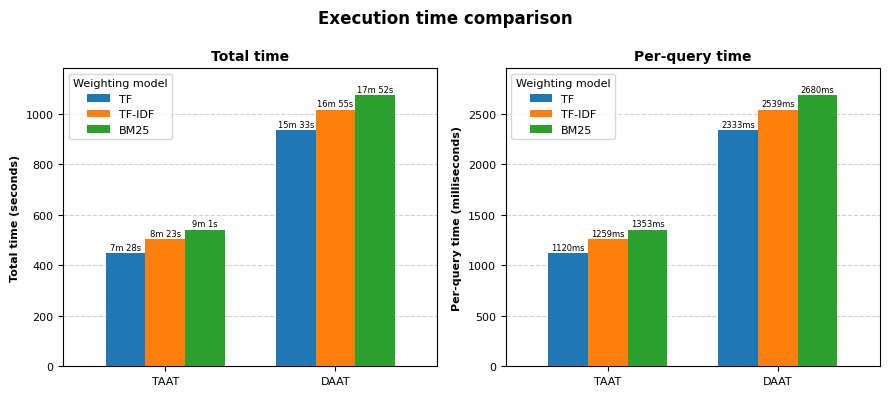

In [ ]:
plot_execution_time_comparison(version="std", wand=False)

The following code defines and executes a function which plots an histogram in which we show the comparison among the *peak memory usages*, expressing values in MBs and grouping columns into **DAAT** and **TAAT** (columns indicate **TF**, **TF-IDF** and **BM25**, keeping same colors between groups).

In this way, we allow an easy visual comparison of the impact of the three *weighting models* and the two *matching strategies*.

The function is matching the introduction of an optimized version of the retrieving system (section ***11. Optimized Retrieving System***) and of WAND *matching strategy* (section ***12. Efficient Query Processing via WAND (Weak AND)***).

In [ ]:
def plot_peak_memory(version="std", wand=False):
    if not wand:
        _, ax = plt.subplots(figsize=(4, 4))
    else:
        _, ax = plt.subplots(figsize=(6, 4))

    if version == "std":
        peak_memory_df = pd.read_csv(peak_memory_comparison_taat_daat_path, index_col=0)
        save_path = graph_peak_memory_comparison_taat_daat_svg_path
    else:   # "opt"
        if not wand:
            peak_memory_df = pd.read_csv(peak_memory_comparison_taat_daat_opt_path, index_col=0)
            save_path = graph_peak_memory_comparison_taat_daat_opt_svg_path
        else:
            peak_memory_df = pd.read_csv(peak_memory_comparison_taat_daat_wand_opt_path, index_col=0)
            save_path = graph_peak_memory_comparison_taat_daat_wand_opt_svg_path

    peak_memory_df.plot(
        kind='bar',
        ax=ax,
        rot=0,
        width=0.7,
        zorder=3
    )

    ax.set_title("Peak memory usage comparison", fontsize=10, fontweight='bold')
    ax.legend(title="Weighting model", title_fontsize=8, fontsize=8, loc='upper right')
    ax.set_ylabel("Peak memory usage (MB)", fontsize=8, fontweight='bold')
    ax.set_ylim(0, peak_memory_df.max().max() * 1.1)
    ax.tick_params(axis='both', labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.6, zorder=0)

    for p in ax.patches:
        value = p.get_height() # type: ignore
        if value > 0:
            label = f"{value:.3f}MB"
            ax.annotate(label,
                        (p.get_x() + p.get_width() / 2., p.get_height()), # type: ignore
                        ha='center', va='bottom', xytext=(0, 1),
                        fontsize=6, color='black',
                        rotation=-20,
                        textcoords='offset points')

    plt.tight_layout()

    plt.savefig(save_path)
    plt.show()

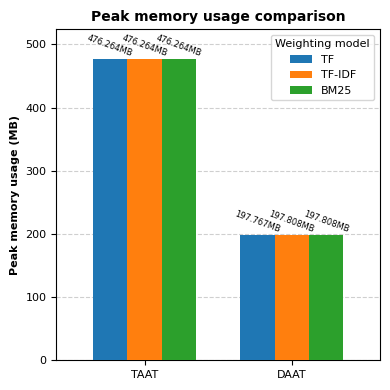

In [ ]:
plot_peak_memory(version="std", wand=False)

From these comparisons we can assume many conclusions.

1.   **DAAT** turnes out to be **much slower** than TAAT (even more than 100% slower): indeed, our (standard) version of DAAT scrolls through all posting lists at each iteration to check for the presence of the currently minimum `docid` (to update the score of such document). This behaviour leads to a huge number of scans of all the *posting lists*, resulting in a substantial overhead in execution time.

2.   One the other hand, as we were expecting, the execution times go lightly up switching *weighting model* from TF, to TF-IDF, to BM25. As we can clearly see from the histograms, **TF** turns out to be the **fastest** among the three *weighting models*. This result can be easily justified with the formulas of the *weighting models* themselves: TF has a much easier to compute formula then TF-IDF and mainly then BM25, where logarithms and other computations introduce an overhead which becomes not negligible when it comes to process large amount of queries.

3.  Overall, all the combinations of *matching strategies* and *weighting models* tested before turn out to be **pretty slow**: from the *per-query* histogram we can clearly see that **no system spends less than one second** to process a single query (on average). The "one second wall" should be a fine threshold to consider a *retrieving system* at least acceptable.

4.  Looking at the peak memory usage graph, we can conclude that **DAAT** is correctly sacrifying speed to **cut down memory usage**, which should be its main advantage. Indeed, DAAT does not use a temporary accumulator structure to store intermediate scores, but leverages its document-oriented architecture to compute the final score of a document in a single pass. Therefore, it mantains only the structure with the final results (the *top-k best matches*), discarding all documents (along with their own scores) which do not fit inside the final top ranking.

5.  Looking at the two groups of columns, we can firmly say that **changing *weighting model* does not lead to a considerably different peak memory usage**. That is perfectly reasonable since the *weighting model* impacts only on the formula used to compute the score of a document, but all three formulas have only one value as a result to be saved in memory. Therefore, peak memory usage should not differ heavily from one model to another.

In next sections, we introduce some modifications to our system in order to improve the execution time of our *retrieving system*. We will track also peak memory usage of the new versions to ensure that improvements in speed do not cause a degradation in memory consumption.

# **11. Optmized Retrieving System**
In this section we firstly build some classes using code written in previous sections and new code that aims to take down the *execution time* of our retrieving system. Then we test the *optmized version of our retrieving system* as done in section ***10. Retrieving System*** on the standard version. At the end of the section, we also build graphs to efficiently compare the performances of the standard version against the optimized one.

## **11.1. Class definition**
In these cells we re-define the class `InvertedIndex`, calling it `InvertedIndexOptimized`, and we define from scratch a new class `OurRetrieverOptimized`.

### InvertedIndexOptimized
After a careful analysis of the standard version of the `InvertedIndex`, we can observe that the `PostingListIterator` class presents a significant advantage, but also a major drawback.

- **PRO:** It achieves a *high level of code readability* for posting list traversal, as well as for TAAT and DAAT implementations. It makes the query execution flow of our retrieval system very easy to understand.
- **CON:** It represents the primary bottleneck of our retrieval system since it is *coded in Python* without leveraging built-in functions (which are written in C), as it enforces a heavily object-oriented approach that relies on class member functions to traverse the posting lists.

In order to remove such bottleneck we are going to introduce the next changes to the class `InvertedIndex`.

**Built-in Iterators**

The Object-Oriented approach forces us to use `while` loops in both TAAT and DAAT implementations, i.e. **iterating over lists with pure Python code**. Instead of doing so, we can use **built-in iterators** of Python, specifically the `iter()` and `next()` methods. These methods directly leverage an *underlying C implementation*, resulting in a big performance improvement in list iteration [[PEP 234 – Iterators](https://peps.python.org/pep-0234/)].

**"Pointer" Management**

The Object-Oriented approach forces us to **manually update** the integer "pointer" to the current document in each posting list (`self.pos += 1`) at every step. In the standard version of our retrieving system, this operation is performed $N$ times for each posting list, where $N$ is the length of the posting list itself (on average $\approx 127$ documents).

In Python, as any other piece of data [[Objects in Python](https://docs.python.org/3/reference/datamodel.html#objects-values-and-types)], integers are not primitive types but complex structures called `PyLongObject` (consuming 28 bytes per integer). Furthermore, integers larger than 256 are *immutable* objects that must be deallocated and re-allocated in a different area of memory whenever the value changes. However, the most significant bottleneck is not just memory allocation, but the **interpreter overhead**. Performing a single `self.pos += 1` involves:
1.  Attribute lookup (`self.pos`).
2.  The addition operation.
3.  Object creation/allocation for the new result.
4.  Attribute reassignment.

While a single update is fast, repeating this cycle millions of times across all posting lists during a query execution may accumulate a large delay.

By removing the sub-class `PostingListIterator` (and consequently switching to built-in Python iterators), we bypass the manual "pointer" management, delegating the iteration logic to highly optimized C code.

**Function Calls**

Another source of latency is the **overhead of function calls**, which are frequent in a pure Object-Oriented approach.

In Python, as stated before, also functions are represented by C data structures [[Callable types](https://docs.python.org/3/reference/datamodel.html#callable-types)]. Such structures contain a bunch of methods that define what can be done on a function (even code is represented by a method): mantaining such structure involves an overhead. Broadly speaking, each function call requires creating *at runtime* a new execution frame on the call stack, handling arguments and looking up variables in local/global scopes (*scope resolution*: searching for a variable in Python is a hash map search, not a direct memory access as in C) [[Why is a function/method call in Python expensive?](https://stackoverflow.com/questions/22893139/why-is-a-function-method-call-in-python-expensive)]. This overhead is negligible for a single call but becomes a major bottleneck inside loops (like iterating over postings).

By removing the sub-class `PostingListIterator` (and consequently inlining a function logic), we eliminate the repeated creation and destruction of stack frames, resulting in a substantial speedup.

Therefore, we implement all these changes by removing the sub-class `PostingListIterator` from the `InvertedIndex`: this choice also involves re-writing from scratch both `taat()` and `daat()` functions (we describe their changes in next paragraph). Moreover, for the same reasons, we also completely remove class `TopQueue`, delegating to TAAT and DAAT algorithms the task of mantaining an appropriate structure for the *top-k* matches.

In [ ]:
print("Defining InvertedIndexOptimized class...")
class InvertedIndexOptimized:
    ## Constructor and Destructor ##
    def __init__(self, metadata_path, docids_path, freqs_path):
        self.metadata_path = metadata_path
        self.docids_path = docids_path
        self.freqs_path = freqs_path

        self.load_index(self.metadata_path, self.docids_path, self.freqs_path)

        print(f"\nTotal documents: {self.stats['num_docs']}\nTotal terms: {self.stats['num_terms']}\nTotal tokens: {self.stats['num_tokens']}\n")

    def __del__(self):
        self._file_docids.close()
        self._file_freqs.close()

    ## Methods to load index components ##
    def load_index_metadata(self, metadata_path):
        print(f"Loading metadata from '{metadata_path}'...")
        try:
            with open(metadata_path, 'rb') as f:
                self.lexicon, self.doc_idx, self.stats = pickle.load(f)
            print("Metadata loaded successfully.")
        except FileNotFoundError:
            print(f"Error: Metadata file not found at {metadata_path}")
        except Exception as e:
            print(f"Error loading metadata: {e}")

    def load_index_docids(self, docids_path):
        print(f"Loading docids from '{docids_path}'...")
        try:
            self._file_docids = open(docids_path, 'rb')
            print("Docids loaded successfully.")
        except FileNotFoundError:
            print(f"Error: Docids file not found at {docids_path}")
        except Exception as e:
            print(f"Error loading docids: {e}")

    def load_index_freqs(self, freqs_path):
        print(f"Loading freqs from '{freqs_path}'...")
        try:
            self._file_freqs = open(freqs_path, 'rb')
            print("Freqs loaded successfully.")
        except FileNotFoundError:
            print(f"Error: Freqs file not found at {freqs_path}")
        except Exception as e:
            print(f"Error loading freqs: {e}")

    def load_index(self, metadata_path, docids_path, freqs_path):
        self.load_index_metadata(metadata_path)
        self.load_index_docids(docids_path)
        self.load_index_freqs(freqs_path)

    ## Methods to decode postings ##
    def VBDecode(self, byte_list_bytes):
        byte_list = list(byte_list_bytes)
        n_list = []
        n = 0
        for b in byte_list:
            if b < 128:
                n = 128 * n + b
            else:
                n = 128 * n + (b - 128)
                n_list.append(n)
                n = 0
        return n_list

    def undgaps(self, gaps_list):
        if not gaps_list: return []
        return list(np.cumsum(np.array(gaps_list, dtype=np.int64)))

    ## Methods to access index statistics ##
    def num_docs(self):
        return self.stats['num_docs']

    def num_terms(self):
        return self.stats['num_terms']

    def num_tokens(self):
        return self.stats['num_tokens']

    def get_token_info(self, token):
        return self.lexicon.get(token)

    ## Methods to access posting lists ##
    def _get_posting_list_from_file(self, token_info):
        self._file_docids.seek(token_info['ptr_docid'])
        compressed_bytes = self._file_docids.read(token_info['len_docid'])
        docids_gaps = self.VBDecode(compressed_bytes)
        docids_list = self.undgaps(docids_gaps)

        self._file_freqs.seek(token_info['ptr_freq'])
        compressed_bytes = self._file_freqs.read(token_info['len_freq'])
        freqs_list = self.VBDecode(compressed_bytes)

        return docids_list, freqs_list

    def get_posting(self, token):
        token_info = self.get_token_info(token)
        if not token_info:
            return token, ([], [])
        else:
            return token, self._get_posting_list_from_file(token_info)

    def get_postings(self, tokens):
        return [self.get_posting(token) for token in tokens]

print("Class defined successfully.")

Defining InvertedIndexOptimized class...
Class defined successfully.


In [ ]:
print("Creating inverted index...")
inv_index_optimized = InvertedIndexOptimized(
    index_metadata_path,
    index_docids_path,
    index_freqs_path
)
print("Inverted index created successfully.")

Creating inverted index...
Loading metadata from './index/index_metadata.pickle'...
Metadata loaded successfully.
Loading docids from './index/inv_index_docids.dat'...
Docids loaded successfully.
Loading freqs from './index/inv_index_freqs.dat'...
Freqs loaded successfully.

Total documents: 8841823
Total terms: 1791090
Total tokens: 306531228

Inverted index created successfully.


### OurRetrieverOptimized
The changes we made on `InvertedIndexOptimized` reflect into other changes in the code of both `taat()` and `daat()` functions.

**Direct List Traversal for Posting Lists (TAAT)**

Since we do not have `PostingListIterator` anymore and thanks to the logic of TAAT algorithm (which scrolls through a single posting list at-a-time), we can directly scroll through posting lists with a **simple `for` loop** in which we zip together corresponding elements of the posting list containing `docids` and the posting list containing `freqs` (`for docid, freq in zip(docids, freqs)`). The result is a consistent speed up of the traversal of a posting list compared to the standard version of our retrieving system.

**Loop Unswitching (both TAAT & DAAT)**

Both TAAT and DAAT methods use **loop unswitching** in weighting model dispatching (mainly evident in TAAT): instead of checking the weighting model inside the loop for every document, the check is performed outside the document loop. The code then enters a specific loop dedicated to that weighting model. This removes the cost of a conditional branch for every document in the posting list.

**Native Python Iterators for Posting Lists (DAAT)**

As anticipated in previous paragraph, the code converts standard posting lists into native Python iterators using `iter()`. This allows the algorithm to traverse posting lists using `next()`, without the overhead of list indexing or manual pointer management.

***Top-K* Results using Min-Heap (DAAT)**

From the original class `TopQueue` we mantain the storing method of the *top-k* results, i.e. using a **min-heap structure** `top_k_heap`, having $k$ elements inside. By leveraging the package `heapq`, we ensures that (only) the *top-k* documents are kept in memory always mantaining an increasing order [[heapq — Heap queue algorithm](https://docs.python.org/3/library/heapq.html)].

**"Pointing" Current Documents using Min-Heap (DAAT)**

The package `heapq` introduced in previous optimization let us manage an array as a *binary tree for which every parent node has a value less than or equal to any of its children*. This property causes the update of a min-heap to have a cost $O(log(n))$, where $n$ is the number of posting lists (i.e. the number of non-stopwords terms in a specific query).

Therefore, we use a **min-heap to manage the "pointers"** to the currently analyzed document in each posting list. The structure will always mantain the document with the **smallest** `docid` in the root of the tree (`min_heap[0]`), giving us some advantages:
- Finding the current document to analyze has a cost $O(1)$, by simply reading the first element of the array.
- We do not need to scroll through all the posting lists at each step to find the document with the smallest `docid` (since it always is in the first element), saving a cost $O(n)$. Of course, the structure must be updated at each step by removing a `docid` after having added its contribute to the document score, but the operation has a cost $O(log(n))$.

Inside the *min-heap*, each element contains a pair `(docid, i)`, where `i` represents the index of the element in `posting_data_store` where we mantain all info about the document $d$ (`docid`) inside a specific posting list (i.e. related to a specific term $t$). Therfore, reading info about a pair $(d, t)$ costs $O(1)$.

The logical operation of "advancing the pointer" inside a posting list is reported in code by overwriting a specific element in `posting_data_store` (it costs $O(1)$) and by replacing the root of the *min-heap* (it costs $O(log(n))$, since `heapq.heapreplace()` performs `heapq.pop()` and `heapq.push()` in a single pass). These costs are possible because advancing the iterator has a cost $O(1)$ if done with Python built-in function `next()`.

**Local Variable Caching (both TAAT & DAAT)**

Accessing **local variables** in Python is significantly faster than accessing object attributes (using `self.`) [[Local Acces VS Member Access](https://stackoverflow.com/questions/12397984/why-is-local-variable-access-faster-than-class-member-access-in-python)]. At the beginning of the functions, we assign to local variables those attributes that we use inside loops (e.g., `lexicon = self.inv_index.lexicon` or `N = self.N`), to reduce lookup overhead.

**Pre-Computing *IDF* and Skipping Negative Terms (both TAAT & DAAT)**

For non-TF weighting models, the *Inverse Document Frequency (IDF)* is computed exactly **once per term** loop rather than being re-computed repeatedly (since $IDF_t$ depends only on the current term $t$ and not on the current document $d$). Additionally, terms resulting in an $IDF_t \leq 0$ (which are extremely common non-stopwords terms) are skipped entirely to prevent unnecessary processing (they will never get inside the *top-k* matches).

**Pre-Computing BM25 Constants (both TAAT & DAAT)**

When using the BM25 weighting model, the code pre-compute the constant components of the formula outside of the inner loops. This prevents from performing the same arithmetic operations for every single document processed.

**Minimizing Document Length Lookups (DAAT)**

In the DAAT traversal loop, the document length (`doc_len`) is fetched from the index only once for each document. Even if multiple query terms appear in the same document, the code ensures the length is not retrieved redundantly for each term, reducing dictionary lookups.

In order to have an easier management and execution of the notebook, we build a new class called `OurRetrieverOptimized`, in which we include the following functions:
*   Both *matching strategies*, so (optimized) functions `taat()` and `daat()`.
*   Both *query processing frameworks* from paragraph ***10.2. Function definition - Query Processing***, so functions `query_processing_time()` and `query_processing_mem()` (slightly modified to support TAAT and DAAT as member functions).

We also copy and paste in cells below both *profilers* (i.e. functions `time_profile()` and `memory_profile()`) and the function `results_to_dataframe()` for easiness of execution. All these functions are taken from paragraph ***10.2. Function definition - Auxiliary functions***.

In [ ]:
def time_profile(f):
    @wraps(f)
    def profiler(*args, **kwargs):
        start = time.time()
        result = f(*args, **kwargs)
        end = time.time()
        ms = (end - start) * 1000
        return result, ms
    return profiler

def memory_profile(f):
    @wraps(f)
    def profiler(*args, **kwargs):
        gc.collect()
        tracemalloc.start()
        peak = 0
        try:
            result = f(*args, **kwargs)
            _, peak = tracemalloc.get_traced_memory()
        finally:
            tracemalloc.stop()
        peak_MB = peak / 10**6
        return result, peak_MB
    return profiler

def results_to_dataframe(results_dict):
    data = []
    for query_key, doc_list in results_dict.items():
        try:
            query_id = query_key.split('\t')[0]
        except:
            query_id = query_key
        for rank, (doc_id, score) in enumerate(doc_list):
            data.append({
                'query_id': query_id,
                'doc_id': doc_id,
                'rank': rank + 1,
                'score': score
            })
    return pd.DataFrame(data)


print("Defining OurRetrieverOptimized class...")
class OurRetrieverOptimized:
    def __init__(self, inv_index):
        self.inv_index = inv_index

        self.N = inv_index.num_docs()
        self.avg_dl = inv_index.num_tokens() / self.N if self.N > 0 else 0


    # --- INITIALIZATION FUNCTION FOR DAAT ---
    def initialize_daat_structures(self, postings, weighting_model):
        lexicon = self.inv_index.lexicon
        N = self.N

        min_heap = []   # min_heap structure: (current_docid, list_index)
        posting_data_store = [] # posting_data_store structure: [0: doc_iter, 1: freq_iter, 2: idf, 3: current_freq]

        for i, (term, (docids, freqs)) in enumerate(postings):
            if not docids: continue
            if term not in lexicon: continue

            idf = 0.0
            if weighting_model != "TF":
                df = lexicon[term]['doc_freq']
                idf = math.log(N / df)
                if idf <= 0.0: continue

            docids_iter = iter(docids)
            freqs_iter = iter(freqs)
            try:
                docid = next(docids_iter)
                freq = next(freqs_iter)

                heapq.heappush(min_heap, (docid, i))

                if len(posting_data_store) <= i:
                    posting_data_store.extend([None] * (i - len(posting_data_store) + 1))
                posting_data_store[i] = [docids_iter, freqs_iter, idf, freq]

            except StopIteration:
                continue

        return min_heap, posting_data_store


    # --- TAAT ---
    def taat(self, postings, k, weighting_model, k1=0.82, b=0.68):
        A = defaultdict(float)

        lexicon = self.inv_index.lexicon
        doc_idx = self.inv_index.doc_idx
        avg_dl = self.avg_dl
        N = self.N

        for term, (docids, freqs) in postings:
            if term not in lexicon: continue

            if weighting_model != "TF":
                df = lexicon[term]['doc_freq']
                idf = math.log(N / df)
                if idf <= 0: continue

            if weighting_model == "TF":
                for docid, freq in zip(docids, freqs):
                    A[docid] += (1 + math.log(freq))

            elif weighting_model == "TF-IDF":
                for docid, freq in zip(docids, freqs):
                    A[docid] += (1 + math.log(freq)) * idf  # type: ignore

            else: # BM25
                b_const = k1 * (1 - b)
                b_normalized = k1 * b / avg_dl

                for docid, freq in zip(docids, freqs):
                    doc_len = doc_idx[docid][1]
                    denominator = freq + b_const + (b_normalized * doc_len)
                    A[docid] += idf * (freq / denominator) # type: ignore

        return heapq.nlargest(k, A.items(), key=lambda x: x[1])


    # --- DAAT ---
    def daat(self, postings, k, weighting_model, k1=0.82, b=0.68):
        doc_idx = self.inv_index.doc_idx
        avg_dl = self.avg_dl

        min_heap, posting_data_store = self.initialize_daat_structures(postings, weighting_model)
        if not min_heap:
            return []

        top_k_heap = []

        if weighting_model == "TF":
            while min_heap:
                current_docid = min_heap[0][0]
                score = 0.0

                while min_heap and min_heap[0][0] == current_docid:
                    _, i = min_heap[0]
                    docid_iter, freq_iter, idf, freq = posting_data_store[i]

                    score += (1 + math.log(freq))

                    try:
                        next_docid = next(docid_iter)
                        next_freq = next(freq_iter)
                        heapq.heapreplace(min_heap, (next_docid, i))
                        posting_data_store[i] = (docid_iter, freq_iter, idf, next_freq)
                    except StopIteration:
                        heapq.heappop(min_heap)

                if len(top_k_heap) < k:
                    heapq.heappush(top_k_heap, (score, current_docid))
                else:
                    if score > top_k_heap[0][0]:
                        heapq.heapreplace(top_k_heap, (score, current_docid))

        elif weighting_model == "TF-IDF":
            while min_heap:
                current_docid = min_heap[0][0]
                score = 0.0

                while min_heap and min_heap[0][0] == current_docid:
                    _, i = min_heap[0]
                    docid_iter, freq_iter, idf, freq = posting_data_store[i]

                    score += (1 + math.log(freq)) * idf

                    try:
                        next_docid = next(docid_iter)
                        next_freq = next(freq_iter)
                        heapq.heapreplace(min_heap, (next_docid, i))
                        posting_data_store[i] = (docid_iter, freq_iter, idf, next_freq)
                    except StopIteration:
                        heapq.heappop(min_heap)

                if len(top_k_heap) < k:
                    heapq.heappush(top_k_heap, (score, current_docid))
                else:
                    if score > top_k_heap[0][0]:
                        heapq.heapreplace(top_k_heap, (score, current_docid))

        else: # BM25
            b_const = k1 * (1 - b)
            b_normalized = k1 * b / avg_dl

            while min_heap:
                current_docid = min_heap[0][0]
                score = 0.0

                doc_len = doc_idx[current_docid][1]

                while min_heap and min_heap[0][0] == current_docid:
                    _, i = min_heap[0]
                    docid_iter, freq_iter, idf, freq = posting_data_store[i]

                    denominator = freq + b_const + (b_normalized * doc_len)
                    score += idf * (freq / denominator)

                    try:
                        next_docid = next(docid_iter)
                        next_freq = next(freq_iter)
                        heapq.heapreplace(min_heap, (next_docid, i))
                        posting_data_store[i] = (docid_iter, freq_iter, idf, next_freq)
                    except StopIteration:
                        heapq.heappop(min_heap)

                if len(top_k_heap) < k:
                    heapq.heappush(top_k_heap, (score, current_docid))
                else:
                    if score > top_k_heap[0][0]:
                        heapq.heapreplace(top_k_heap, (score, current_docid))

        return [(d, s) for s, d in heapq.nlargest(k, top_k_heap)]


    # # --- QUERY PROCESSING METHOD ---
    @time_profile
    def query_processing_time(self, queries, matching_strategy="TAAT", weighting_model="TF", k1=0.82, b=0.68):
        k = 10
        results = {}
        preprocessor = PreProcessor()

        if not isinstance(queries, list):
            queries = list(queries)

        print(f"Processing queries with {matching_strategy} and {weighting_model}...")
        for q in queries:
            tokens = preprocessor.preprocess_optimized(q)[1:]
            if not tokens: continue

            postings = self.inv_index.get_postings(tokens)

            if matching_strategy == "TAAT":
                results[q] = self.taat(postings, k, weighting_model, k1, b)
            else: # DAAT
                results[q] = self.daat(postings, k, weighting_model, k1, b)

        return results

    @memory_profile
    def query_processing_mem(self, queries, matching_strategy="TAAT", weighting_model="TF", k1=0.82, b=0.68):
        k = 10
        results = {}
        preprocessor = PreProcessor()

        if not isinstance(queries, list):
            queries = list(queries)

        print(f"Processing queries with {matching_strategy} and {weighting_model}...")
        for q in queries:
            tokens = preprocessor.preprocess_optimized(q)[1:]
            if not tokens: continue

            postings = self.inv_index.get_postings(tokens)

            if matching_strategy == "TAAT":
                results[q] = self.taat(postings, k, weighting_model, k1, b)
            else: # DAAT
                results[q] = self.daat(postings, k, weighting_model, k1, b)

        return results

print("Class defined successfully.")

Defining OurRetrieverOptimized class...
Class defined successfully.


In [ ]:
print("Creating optimized retriever...")
our_retriever_optimized = OurRetrieverOptimized(inv_index_optimized)
print("Optimized retriever created successfully.")

Creating optimized retriever...
Optimized retriever created successfully.


We use the *optimized retrieving system* to process in a single cell all combinations of *matching strategies* and *weighting models* as we have already done with our standard version of the retrieving system. We execute functions for both time and memory tracking.

In [ ]:
print("Processing queries with time tracking...")
results_taat_tf_opt, time_taat_tf_opt = our_retriever_optimized.query_processing_time(all_queries, matching_strategy="TAAT", weighting_model="TF")
results_daat_tf_opt, time_daat_tf_opt = our_retriever_optimized.query_processing_time(all_queries, matching_strategy="DAAT", weighting_model="TF")
results_taat_tfidf_opt, time_taat_tfidf_opt = our_retriever_optimized.query_processing_time(all_queries, matching_strategy="TAAT", weighting_model="TF-IDF")
results_daat_tfidf_opt, time_daat_tfidf_opt = our_retriever_optimized.query_processing_time(all_queries, matching_strategy="DAAT", weighting_model="TF-IDF")
results_taat_bm25_opt, time_taat_bm25_opt = our_retriever_optimized.query_processing_time(all_queries, matching_strategy="TAAT", weighting_model="BM25")
results_daat_bm25_opt, time_daat_bm25_opt = our_retriever_optimized.query_processing_time(all_queries, matching_strategy="DAAT", weighting_model="BM25")

print("Saving results to disk...")
results_to_dataframe(results_taat_tf_opt).to_csv(results_taat_tf_opt_test_path, index=False)
results_to_dataframe(results_daat_tf_opt).to_csv(results_daat_tf_opt_test_path, index=False)
results_to_dataframe(results_taat_tfidf_opt).to_csv(results_taat_tfidf_opt_test_path, index=False)
results_to_dataframe(results_daat_tfidf_opt).to_csv(results_daat_tfidf_opt_test_path, index=False)
results_to_dataframe(results_taat_bm25_opt).to_csv(results_taat_bm25_opt_test_path, index=False)
results_to_dataframe(results_daat_bm25_opt).to_csv(results_daat_bm25_opt_test_path, index=False)

print(f"Total time processing all-queries set by TAAT TF: {time_taat_tf_opt:.3f} ms")
print(f"Total time processing all-queries set by DAAT TF: {time_daat_tf_opt:.3f} ms")
print(f"Total time processing all-queries set by TAAT TF-IDF: {time_taat_tfidf_opt:.3f} ms")
print(f"Total time processing all-queries set by DAAT TF-IDF: {time_daat_tfidf_opt:.3f} ms")
print(f"Total time processing all-queries set by TAAT BM25: {time_taat_bm25_opt:.3f} ms")
print(f"Total time processing all-queries set by DAAT BM25: {time_daat_bm25_opt:.3f} ms")

Processing queries with time tracking...
Processing queries with TAAT and TF...
Processing queries with DAAT and TF...
Processing queries with TAAT and TF-IDF...
Processing queries with DAAT and TF-IDF...
Processing queries with TAAT and BM25...
Processing queries with DAAT and BM25...
Saving results to disk...
Total time processing all-queries set by TAAT TF: 108783.700 ms
Total time processing all-queries set by DAAT TF: 108925.359 ms
Total time processing all-queries set by TAAT TF-IDF: 109724.916 ms
Total time processing all-queries set by DAAT TF-IDF: 110232.913 ms
Total time processing all-queries set by TAAT BM25: 141867.823 ms
Total time processing all-queries set by DAAT BM25: 138842.231 ms


In [ ]:
print("Processing queries with memory tracking...")
_, mem_taat_tf_opt = our_retriever_optimized.query_processing_mem(all_queries, matching_strategy="TAAT", weighting_model="TF")
_, mem_daat_tf_opt = our_retriever_optimized.query_processing_mem(all_queries, matching_strategy="DAAT", weighting_model="TF")
_, mem_taat_tfidf_opt = our_retriever_optimized.query_processing_mem(all_queries, matching_strategy="TAAT", weighting_model="TF-IDF")
_, mem_daat_tfidf_opt = our_retriever_optimized.query_processing_mem(all_queries, matching_strategy="DAAT", weighting_model="TF-IDF")
_, mem_taat_bm25_opt = our_retriever_optimized.query_processing_mem(all_queries, matching_strategy="TAAT", weighting_model="BM25")
_, mem_daat_bm25_opt = our_retriever_optimized.query_processing_mem(all_queries, matching_strategy="DAAT", weighting_model="BM25")

print(f"Peak memory usage by TAAT TF: {mem_taat_tf_opt:.3f} MB")
print(f"Peak memory usage by DAAT TF: {mem_daat_tf_opt:.3f} MB")
print(f"Peak memory usage by TAAT TF-IDF: {mem_taat_tfidf_opt:.3f} MB")
print(f"Peak memory usage by DAAT TF-IDF: {mem_daat_tfidf_opt:.3f} MB")
print(f"Peak memory usage by TAAT BM25: {mem_taat_bm25_opt:.3f} MB")
print(f"Peak memory usage by DAAT BM25: {mem_daat_bm25_opt:.3f} MB")

Processing queries with memory tracking...
Processing queries with TAAT and TF...
Processing queries with DAAT and TF...
Processing queries with TAAT and TF-IDF...
Processing queries with DAAT and TF-IDF...
Processing queries with TAAT and BM25...
Processing queries with DAAT and BM25...
Peak memory usage by TAAT TF: 476.272 MB
Peak memory usage by DAAT TF: 197.817 MB
Peak memory usage by TAAT TF-IDF: 476.273 MB
Peak memory usage by DAAT TF-IDF: 197.817 MB
Peak memory usage by TAAT BM25: 476.273 MB
Peak memory usage by DAAT BM25: 197.816 MB


## **11.2. Performance Comparison: *Standard Retriever* VS *Optimized Retriever***
In these cells we firstly build the dataframes that contain all combinations of *matching strategies* and *weighting models* just tested. Then, we plot graphs to compare TAAT against DAAT performance of our *optimized retrieving system*. The code below leverages three functions defined in paragraph ***10.6. Performance Comparison: TAAT vs DAAT***: `build_results_df()`, `plot_execution_time_comparison()`, and `plot_peak_memory()`.

In [ ]:
times_opt_df, times_query_opt_df, peak_memory_opt_df = build_results_df(version="opt", wand=False)
display(times_opt_df, times_query_opt_df, peak_memory_opt_df)

Results file with total times not found. Proceeding with dataframe creation...
Results file with per-query times not found. Proceeding with dataframe creation...
Results file with peak memory usage not found. Proceeding with dataframe creation...


,TF,TF-IDF,BM25
TAAT,108783.700,109724.917,141867.823
DAAT,108925.360,110232.914,138842.231


,TF,TF-IDF,BM25
TAAT,271.959,274.312,354.670
DAAT,272.313,275.582,347.106


,TF,TF-IDF,BM25
TAAT,476.272,476.273,476.273
DAAT,197.818,197.818,197.816


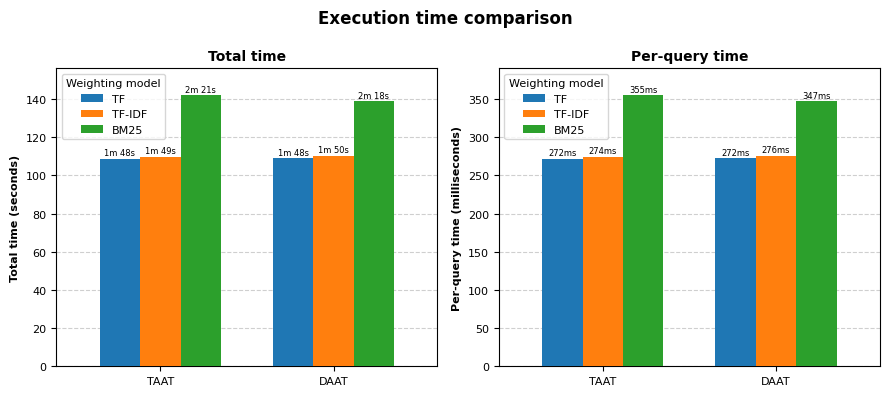

In [ ]:
plot_execution_time_comparison(version="opt", wand=False)

We can see how the *execution time* for both TAAT and DAAT *matching strategy* has fallen down: now, on average, a **single query can be processed in $\approx 200ms$** with all combinations of *matching strategies* and *weighting models*, which is largely under the fine threshold of $1s$ per query.

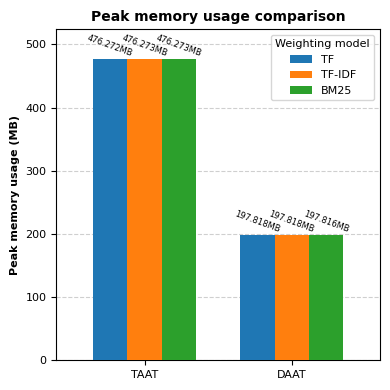

In [ ]:
plot_peak_memory(version="opt", wand=False)

We can see how the optimizations we introduced have **not taken away the major advantage of DAAT** respect to TAAT, that is a lower impact on memory usage.

We define now a new function that generates two images (one for execution times comparison and one for peak memory usage comparison) which contain the following three graphs:
1.  The *first graph* shows comparison between TAAT and DAAT **total execution time** of the *standard* against the *optimized retrieving system*.
1.  The *first graph* shows comparison between TAAT and DAAT **per-query execution time** of the *standard* against the *optimized retrieving system*.
1.  The *first graph* shows comparison between TAAT and DAAT **peak memory usage** of the *standard* against the *optimized retrieving system*.

In [ ]:
def plot_std_vs_opt_comparison(wand=False):
    if not wand:
        times_std_df = pd.read_csv(execution_time_comparison_taat_daat_path)
        times_opt_df = pd.read_csv(execution_time_comparison_taat_daat_opt_path)

        times_std_query_df = pd.read_csv(execution_time_query_comparison_taat_daat_path)
        times_opt_query_df = pd.read_csv(execution_time_query_comparison_taat_daat_opt_path)

        memory_std_df = pd.read_csv(peak_memory_comparison_taat_daat_path)
        memory_opt_df = pd.read_csv(peak_memory_comparison_taat_daat_opt_path)

        save_path_execution_time = graph_std_vs_opt_execution_time_taat_daat_svg_path
        save_path_peak_memory = graph_std_vs_opt_peak_memory_taat_daat_svg_path

        new_labels = ["TAAT - STD", "DAAT - STD", "TAAT - OPT", "DAAT - OPT"]
    else:
        times_opt_df = pd.read_csv(execution_time_comparison_taat_daat_wand_opt_path)

        times_opt_query_df = pd.read_csv(execution_time_query_comparison_taat_daat_wand_opt_path)

        memory_std_df = pd.read_csv(peak_memory_comparison_taat_daat_wand_path)
        memory_opt_df = pd.read_csv(peak_memory_comparison_taat_daat_wand_opt_path)

        new_labels = ["TAAT - STD", "DAAT - STD", "WAND - STD", "TAAT - OPT", "DAAT - OPT", "WAND - OPT"]

    times_df = pd.concat([
        times_std_df.set_index('Unnamed: 0'),
        times_opt_df.set_index('Unnamed: 0')
        ])
    times_df.index = new_labels
    times_df.index.name = None

    times_query_df = pd.concat([
        times_std_query_df.set_index('Unnamed: 0'),
        times_opt_query_df.set_index('Unnamed: 0')
        ])
    times_query_df.index = new_labels
    times_query_df.index.name = None

    memory_df = pd.concat([
        memory_std_df.set_index('Unnamed: 0'),
        memory_opt_df.set_index('Unnamed: 0')
        ])
    memory_df.index = new_labels
    memory_df.index.name = None


    ###### EXECUTION TIMES GRAPH ######
    _, axes = plt.subplots(nrows=2, ncols=1, figsize=(7, 8))

    ### Total times graph ###
    times_df_seconds = times_df / 1000.0

    times_df_seconds.plot(
        kind='bar',
        ax=axes[0],
        rot=0,
        width=0.6,
        zorder=3
    )

    axes[0].set_title("Execution time comparison", fontsize=10, fontweight='bold')
    axes[0].legend(title="Weighting model", title_fontsize=8, fontsize=8, loc='upper right')
    axes[0].set_ylabel("Execution time (seconds)", fontsize=8, fontweight='bold')
    axes[0].set_ylim(0, times_df_seconds.max().max() * 1.1)
    axes[0].tick_params(axis='both', labelsize=8)
    axes[0].grid(axis='y', linestyle='--', alpha=0.6, zorder=0)

    for p in axes[0].patches:
        value = p.get_height()
        if value > 0:
            minutes = int(value // 60)
            seconds = int(value % 60)
            label = f"{minutes}m {seconds}s"
            axes[0].annotate(label,
                            (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='bottom', xytext=(0, 1),
                            rotation=-20,
                            fontsize=6, color='black',
                            textcoords='offset points')

    ### Per-Query graph ###
    times_query_df.plot(
        kind='bar',
        ax=axes[1],
        rot=0,
        width=0.6,
        zorder=3
    )

    axes[1].set_title("Execution time per-query comparison", fontsize=10, fontweight='bold')
    axes[1].legend(title="Weighting model", title_fontsize=8, fontsize=8, loc='upper right')
    axes[1].set_ylabel("Execution time per-query (milliseconds)", fontsize=8, fontweight='bold')
    axes[1].set_ylim(0, times_query_df.max().max() * 1.1)
    axes[1].tick_params(axis='both', labelsize=8)
    axes[1].grid(axis='y', linestyle='--', alpha=0.6, zorder=0)

    for p in axes[1].patches:
        value = p.get_height()
        if value > 0:
            label = f"{value:.0f}ms"
            axes[1].annotate(label,
                            (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='bottom', xytext=(0, 1),
                            rotation=-20,
                            fontsize=6, color='black',
                            textcoords='offset points')

    ### Generic ###
    plt.tight_layout()

    plt.savefig(save_path_execution_time)
    plt.show()
    ###############################


    ###### PEAK MEMORY GRAPH ######
    _, ax = plt.subplots(figsize=(6, 4))

    memory_df.plot(
        kind='bar',
        ax=ax,
        rot=0,
        width=0.7,
        zorder=3
    )

    ax.set_title("Peak Memory Usage Comparison", fontsize=10, fontweight='bold')
    ax.legend(title="Weighting model", title_fontsize=8, fontsize=8, loc='upper right')
    ax.set_ylabel("Peak Memory (MB)", fontsize=8, fontweight='bold')
    ax.set_ylim(0, memory_df.max().max() * 1.1)
    ax.tick_params(axis='both', labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.6, zorder=0)

    for p in ax.patches:
        value = p.get_height() # type: ignore
        if value > 0:
            label = f"{value:.3f}MB"
            ax.annotate(label,
                        (p.get_x() + p.get_width() / 2., p.get_height()), # type: ignore
                        ha='center', va='bottom', xytext=(0, 1),
                        fontsize=6, color='black',
                        rotation=-20,
                        textcoords='offset points')

    plt.tight_layout()

    plt.savefig(save_path_peak_memory)
    plt.show()
    ###############################

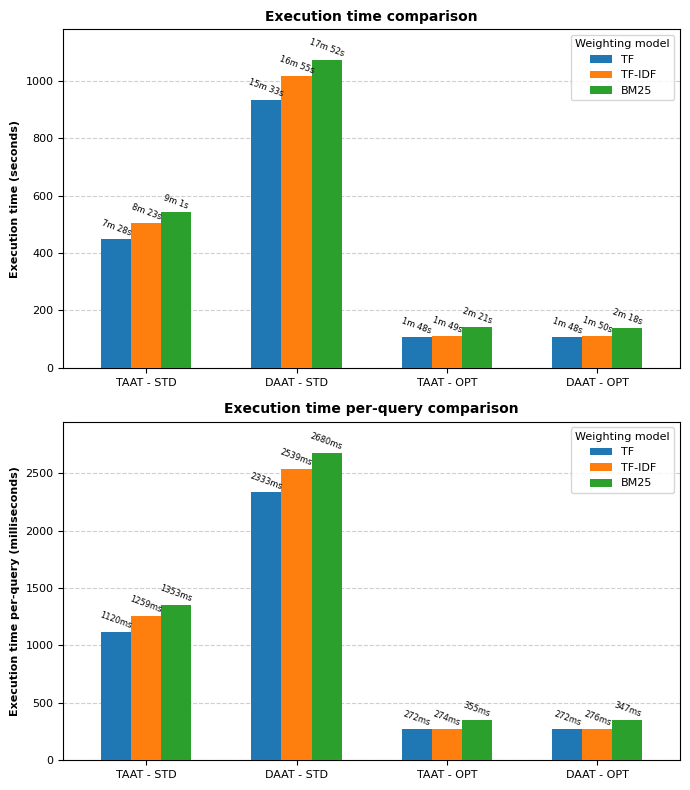

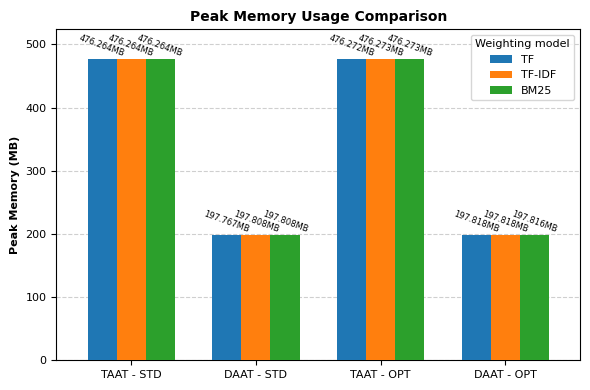

In [ ]:
plot_std_vs_opt_comparison(wand=False)

### **Execution time**

The *optimized retrieving system* is **far faster** than the standard version.

*   The TAAT TF version improved $\approx 75\%$.
*   The TAAT TF-IDF version improved $\approx 78\%$.
*   The TAAT BM25 version improved $\approx 74\%$.
*   The DAAT TF version improved $\approx 88\%$.
*   The DAAT TF-IDF version improved $\approx 89\%$.
*   The DAAT BM25 version improved $\approx 87\%$.

On average:
*   TAAT improved $\approx 76\%$.
*   DAAT improved $\approx 88\%$.

At the end, **DAAT** went from being twice as slow as TAAT to **matching its performance** with all *weighting models*.

### **Memory usage**

The *optimized retrieving system* use the **same peak memory** as the standard version: the improvement in execution time is not linked with heavier/lighter memory footprint.

### **Conclusion**
Overall, looking at both *execution time* and *memory usage*, we can conclude that there is **no more reason in choosing TAAT over DAAT**, since they have the same performance when it comes to speed with the second one making far less usage of memory.

# **12. Efficient Query Processing via WAND (Weak AND)**
In the previous sections, we implemented a *standard* and an *optimized retrieving system*. Both versions included Term-at-a-Time (TAAT) and Document-at-a-Time (DAAT) *matching strategies*.

While correct, both standard and optimized versions of TAAT and DAAT have a **major drawback** that reflects in execution time: both versions of both algorithms scroll through each posting list from the beginning to the end with **no document ever jumped** from being analyzed and scored. This approach is obviously correct, but leads us to a potentially huge number of score computations even for all those documents that will not be included in the *top-k* matches. Given that $k$ is very often orders of magnitude smaller than the length of a posting list, we can infer that both algorithms perform a large number of superfluous document evaluations.

To address this, in this section we implement the **WAND (Weak AND)** algorithm [[*Broder et al., 2003*](https://dl.acm.org/doi/epdf/10.1145/956863.956944)]. WAND is a modified DAAT algorithm that applies a **dynamic pruning** strategy that significantly reduces the number of full evaluations without losing retrieval effectiveness (it returns the exact same top-$k$ results as a full evaluation), since it skips computations for those documents that have no chance to be included in the final top-$k$ results.

## **12.1. WAND Algorithm**
Here we briefly describe how WAND algorithm logically works. The algorithm relies on three key logical phases.

1.  **Term *Upper Bounds* Computation:** For every term $t$, we pre-compute the *maximum possible contribution* $UB_t$ it can give to the score of a document (explained better later on).
2.  **Score Estimation:** During traversal, WAND maintains a running *threshold* $\theta$ (the score of the $k$-th best document found so far, i.e. the currently worst match). At each iteration, it estimates the score of the next *pivot document*[$_1$][$_2$] summing up the upper bounds $UB_t$ of all terms in the query.
3.  ***Pivot* Selection & Thresholding:** We have an *optimistic estimate*.
    -   If such estimate is $< \theta$, no other document will ever be able to get inside the top-$k$ matches. Therefore, we can exit the loop and return the top-$k$ results obtained.
    -   If such estimate is $>= \theta$ and the *pivot docid* is NOT the currently *minumum docid*, no document between the minimum and the pivot will ever be able to get inside the top-$k$ matches. Therefore, we can **skip the entire bunch of documents in between** and perform the score evaluation for the pivot document.
    -   If such estimate is $>= \theta$ and the *pivot docid* is currently the *minumum docid*, all documents are candidates to get inside the top-$k$ matches. Therefore, we must perform the score svaluation for the minimum (also pivot in this case) document.

---
[$_1$] With *pivot* we refer to a term $t$ without which the document $d$ will never be able to get inside the top-$k$ matches.

[$_2$] With *pivot document* we refer to the document currently pointed in the posting list of the *pivot*.

**Term *Upper Bound* Computation**

The function `compute_all_max_scores_wand()` is designed to pre-compute the ***upper bound*** $UB_t$ of a specific term $t$. Such value represents the **maximum possible contribution** of $t$ to the score of any document.

This step is crucial for the WAND algorithm because these bounds are used to estimate the **best possible score of a document**: if the sum of upper bounds of *matching terms*[$_1$] does not exceed the current threshold, the document can be safely skipped without full evaluation.

We execute such computations **at indexing time**, in order to speed up WAND even further at query time. The function iterates through the entire lexicon and computes $UB_t$ for each term $t$. Obviously, $UB_t$ depends on the specific *weighting model* that will be choosen at query time, so we pre-compute upper bounds for TF, TF-IDF and BM25.

- For *TF*, $UB_t$ is simply the **maximum frequency ($TF_t$)** found inside the posting list of the term $t$.
- For *TF-IDF*, $UB_t$ is the value of $IDF_t$ obtained with **maximum $TF_t$** .
- For *BM25*, $UB_t$ can be found only iterating over the posting list of the term $t$ to find the **maximum BM25 score**.


The *upper bounds* are then saved to disk inside the lexicon itself.

---
[$_1$] With *matching terms* we mean all the terms (of a specific query) that include the currently analyzed document inside their own posting list.

In [ ]:
def compute_all_max_scores_wand(lex, inv, doc_idx, stats, k1=0.82, b=0.68):
    N = stats['num_docs']
    avg_dl = stats['num_tokens'] / N
    for term_id, term_data in tqdm(lex.items(), desc="Computing Max Scores"):
        df = term_data[1]
        term_idx = term_data[0]
        posting_docids = inv['docids'][term_idx]
        posting_freqs = inv['freqs'][term_idx]

        max_score_tf = 1 + math.log(max(posting_freqs))

        idf = math.log(N / df)
        max_score_tfidf = max_score_tf * idf

        max_score_bm25 = 0.0
        for i, doc_id in enumerate(posting_docids):
            freq = posting_freqs[i]
            doc_len = doc_idx[doc_id][1]

            denominator = k1 * (1 - b + b * (doc_len / avg_dl)) + freq
            current_score = (freq / denominator) * idf

            if current_score > max_score_bm25:
                max_score_bm25 = current_score

        lex[term_id] = [term_data[0], term_data[1], term_data[2], max_score_tf, max_score_tfidf, max_score_bm25]
    return lex

In order to save to disk the new lexicon with the pre-computed *upper bounds*, we start as baseline from the function `save_index_to_disk()` introduced in section ***5.1. Standard Version*** and we slightly modify it into the new function `save_index_to_disk_wand()`.

In [ ]:
def save_index_to_disk_wand(lex, inv, doc_idx, stats, index_docids_path, index_freqs_path, index_metadata_path):
    if lex:
        files_to_check = [index_docids_path, index_freqs_path, index_metadata_path]
        for file_path in files_to_check:
            if os.path.exists(file_path):
                try:
                    os.remove(file_path)
                except OSError as e:
                    print(f"Error deleting {file_path}: {e}")

        lexicon_with_pointers = {}
        try:
            with open(index_docids_path, 'wb') as file_docids, open(index_freqs_path, 'wb') as file_freqs:
                for term, old_lex_info in tqdm(lex.items(), desc="Saving inverted index"):
                    term_id = old_lex_info[0]

                    docids_list = inv['docids'][term_id]
                    docids_gaps = dgaps(docids_list)
                    docids_compressed_bytes = VBEncodeList(docids_gaps)

                    pointer_docid = file_docids.tell()
                    file_docids.write(docids_compressed_bytes)
                    len_docids_bytes = len(docids_compressed_bytes)

                    freqs_list = inv['freqs'][term_id]
                    freqs_compressed_bytes = VBEncodeList(freqs_list)

                    pointer_freqs = file_freqs.tell()
                    file_freqs.write(freqs_compressed_bytes)
                    len_freqs_bytes = len(freqs_compressed_bytes)

                    # --- NEW LINES --- #
                    m_tf    = old_lex_info[3] if len(old_lex_info) > 3 else 0.0
                    m_tfidf = old_lex_info[4] if len(old_lex_info) > 4 else 0.0
                    m_bm25  = old_lex_info[5] if len(old_lex_info) > 5 else 0.0

                    lexicon_with_pointers[term] = {
                        'termid': term_id,
                        'doc_freq': old_lex_info[1],
                        'coll_freq': old_lex_info[2],
                        'ptr_docid': pointer_docid,
                        'len_docid': len_docids_bytes,
                        'ptr_freq': pointer_freqs,
                        'len_freq': len_freqs_bytes,
                        'max_score_tf': m_tf,
                        'max_score_tfidf': m_tfidf,
                        'max_score_bm25': m_bm25
                    }
                    # ----------------- #

        except Exception as e:
            print(f"Error during file writing: {e}")

        del inv
        del lex

        with tqdm(total=1, desc="Saving index matadata") as pbar:
            with open(index_metadata_path, 'wb') as f:
                pickle.dump((lexicon_with_pointers, doc_idx, stats), f)
            pbar.update(1)
    else:
        print("Index building failed: no lexicon available.")


After having defined the previous two functions, we can go on with a complete re-indexing of the collection, adding a new line where we call the `compute_all_max_scores_wand()` function. The new index will be saved to disk in path `/index/wand/`, divided into the same three pieces as before (even with the same file names).

In [ ]:
lex, inv, doc_idx, stats = build_index_optimized(collection_path)
lex = compute_all_max_scores_wand(lex, inv, doc_idx, stats)
save_index_to_disk_wand(lex, inv, doc_idx, stats, index_docids_wand_path, index_freqs_wand_path, index_metadata_wand_path)

print(f"Total docs indexed: {stats['num_docs']}")       # type: ignore
print(f"Total terms indexed: {stats['num_terms']}")     # type: ignore
print(f"Total tokens indexed: {stats['num_tokens']}")   # type: ignore

Optimized indexing: 24 CPU, 96 chunks.


Indexing chunks:   0%|          | 0/96 [00:00<?, ?it/s]

Merging indexes:   0%|          | 0/96 [00:00<?, ?it/s]

Computing Max Scores:   0%|          | 0/1791090 [00:00<?, ?it/s]

Saving inverted index:   0%|          | 0/1791090 [00:00<?, ?it/s]

Saving index matadata:   0%|          | 0/1 [00:00<?, ?it/s]

Total docs indexed: 8841823
Total terms indexed: 1791090
Total tokens indexed: 306531228


## **12.2. Class definition**
In these cells we re-define the class `InvertedIndexOptimized`, calling it `InvertedIndexOptimizedWand`, and the class `OurRetrieverOptimized`, calling it `OurRetrieverOptimizedWand`.

### InvertedIndexOptimizedWand
Since we have modified the structure of the lexicon, we also need to apply little changes to the class `InvertedIndexOptimized`: the new class `InvertedIndexOptimizedWand` uses the previous one as baseline and adds to it a new member function `get_term_upper_bound()`, which returns to the caller the *upper bound $UB_t$* for a certain term $t$ considering a specific *weighting model*.

In [ ]:
print("Defining InvertedIndexOptimizedWand class...")
class InvertedIndexOptimizedWand:
    ## Constructor and Destructor ##
    def __init__(self, metadata_path, docids_path, freqs_path):
        self.metadata_path = metadata_path
        self.docids_path = docids_path
        self.freqs_path = freqs_path

        self.load_index(self.metadata_path, self.docids_path, self.freqs_path)

        print(f"\nTotal documents: {self.stats['num_docs']}\nTotal terms: {self.stats['num_terms']}\nTotal tokens: {self.stats['num_tokens']}\n")

    def __del__(self):
        self._file_docids.close()
        self._file_freqs.close()

    ## Methods to load index components ##
    def load_index_metadata(self, metadata_path):
        print(f"Loading metadata from '{metadata_path}'...")
        try:
            with open(metadata_path, 'rb') as f:
                self.lexicon, self.doc_idx, self.stats = pickle.load(f)
            print("Metadata loaded successfully.")
        except FileNotFoundError:
            print(f"Error: Metadata file not found at {metadata_path}")
        except Exception as e:
            print(f"Error loading metadata: {e}")

    def load_index_docids(self, docids_path):
        print(f"Loading docids from '{docids_path}'...")
        try:
            self._file_docids = open(docids_path, 'rb')
            self.mm_docids = mmap.mmap(self._file_docids.fileno(), 0, access=mmap.ACCESS_READ)
            print("Docids loaded successfully.")
        except FileNotFoundError:
            print(f"Error: Docids file not found at {docids_path}")
        except Exception as e:
            print(f"Error loading docids: {e}")

    def load_index_freqs(self, freqs_path):
        print(f"Loading freqs from '{freqs_path}'...")
        try:
            self._file_freqs = open(freqs_path, 'rb')
            self.mm_freqs = mmap.mmap(self._file_freqs.fileno(), 0, access=mmap.ACCESS_READ)
            print("Freqs loaded successfully.")
        except FileNotFoundError:
            print(f"Error: Freqs file not found at {freqs_path}")
        except Exception as e:
            print(f"Error loading freqs: {e}")

    def load_index(self, metadata_path, docids_path, freqs_path):
        self.load_index_metadata(metadata_path)
        self.load_index_docids(docids_path)
        self.load_index_freqs(freqs_path)

    ## Methods to decode postings ##
    def VBDecode(self, byte_list_bytes):
        byte_list = list(byte_list_bytes)
        n_list = []
        n = 0
        for b in byte_list:
            if b < 128:
                n = 128 * n + b
            else:
                n = 128 * n + (b - 128)
                n_list.append(n)
                n = 0
        return n_list

    def undgaps(self, gaps_list):
        if not gaps_list: return []
        return list(np.cumsum(np.array(gaps_list, dtype=np.int64)))

    ## Methods to access index statistics ##
    def num_docs(self):
        return self.stats['num_docs']

    def num_terms(self):
        return self.stats['num_terms']

    def num_tokens(self):
        return self.stats['num_tokens']

    def get_token_info(self, token):
        return self.lexicon.get(token)

    ## Methods to access posting lists ##
    def _get_posting_list_from_file(self, token_info):
        self.mm_docids.seek(token_info['ptr_docid'])
        compressed_bytes_doc = self.mm_docids.read(token_info['len_docid'])
        docids_gaps = self.VBDecode(compressed_bytes_doc)
        docids_list = self.undgaps(docids_gaps)

        self.mm_freqs.seek(token_info['ptr_freq'])
        compressed_bytes_freq = self.mm_freqs.read(token_info['len_freq'])
        freqs_list = self.VBDecode(compressed_bytes_freq)

        return docids_list, freqs_list

    def get_posting(self, token):
        token_info = self.get_token_info(token)
        if not token_info:
            return token, ([], [])
        else:
            return token, self._get_posting_list_from_file(token_info)

    def get_postings(self, tokens):
        return [self.get_posting(token) for token in tokens]

    # --- NEW FUNCTION --- #
    def get_term_upper_bound(self, term, weighting_model):
        info = self.lexicon.get(term)
        if info is None: return 0.0

        if weighting_model == "BM25":
            return info.get('max_score_bm25', 0.0)
        elif weighting_model == "TF-IDF":
            return info.get('max_score_tfidf', 0.0)
        elif weighting_model == "TF":
            return info.get('max_score_tf', 0.0)

        return 0.0
    # -------------------- #

print("Class defined successfully.")

Defining InvertedIndexOptimizedWand class...
Class defined successfully.


In [ ]:
print("Creating inverted index...")
inv_index_optimized_wand = InvertedIndexOptimizedWand(
    index_metadata_wand_path,
    index_docids_wand_path,
    index_freqs_wand_path
)
print("Inverted index created successfully.")

Creating inverted index...
Loading metadata from './index/wand/index_metadata.pickle'...
Metadata loaded successfully.
Loading docids from './index/wand/inv_index_docids.dat'...
Docids loaded successfully.
Loading freqs from './index/wand/inv_index_freqs.dat'...
Freqs loaded successfully.

Total documents: 8841823
Total terms: 1791090
Total tokens: 306531228

Inverted index created successfully.


### OurRetrieverOptimizedWand
The WAND *matching strategy* is implemented inside a new function `wand()` inserted into the class `OurRetrieverOptimizedWand`, which take as baseline the class `OurRetrieverOptimized`. Only this function is added to the previously defined class (together with an auxiliary function `initialize_wand_structures()`).

The function `wand()` works as follows.

1.  **Initialization**: It initializes:
    -  The data structure needed to traverse posting lists in a DAAT fashion calling the function `initialize_wand_structures()` (recall that WAND is basically an optimization of DAAT).
    -  Some `self.` structures needed for WAND as local variables, speeding up access to those variables.
    -  Some other variables and structures initially empty (`top_k_heap` and `threshold`).

2.  **Pivot Selection**: It computes a `limit` score by summing the *upper bounds $UB_t$* of all the terms $t$ of the current query. Such `limit` is equal to the score that a document $d$ would reach if all matching query terms $t$ had highest possible score in $d$, depending on the current weighting model. It then identifies $d$ as **pivot** if the partial sum of $UB_t$ of the terms $t$ scrolled until a certain iteration exceeds the current `threshold` ($\theta$): a *pivot document* has chances to be included in the final top-$k$ results. If $d$ is not *pivot*, `pivot_index` remains invariate from its inizialization(`= -1`), otherwise it gets changed to `i` (the position of the *pivot term* inside the query).

3.  **Pivot Check**: It checks `if pivot_docid == -1`:
    -   If **yes**, no other document will ever be able to get over `threshold`, so we exit the loop and return the top-$k$ matches.
    -   If **no**, enough terms *might* align to beat the threshold, so we go on with the algorithm.

4.  **Alignment Check**: It check `if cursors[0][0] != pivot_docid`:
    -   If **yes**, the algorithm encounters a *miss* (the documents having docid in between the minimum docid and the pivot docid will never get inside the top-$k$ results), so it skips an entire bunch of documents in the posting lists before the pivot term.
    -   If **no**, the algorithm encounters a *hit* (the pivot document has the minimum docid), so it performs a full score evaluation for the pivot document. Then, it checks if the computed score beats `threshold`: if so, the document is added to `top_k_heap` and `threshold` is updated.

This mechanism ensures that we only perform score evaluations for documents that have a high probability of entering the final top-$k$ matches.

Obviously, all optimizations previously applied to DAAT in the *optimized retrieving system* are still present also in WAND, whenever possible.

In [ ]:
def time_profile(f):
    @wraps(f)
    def profiler(*args, **kwargs):
        start = time.time()
        result = f(*args, **kwargs)
        end = time.time()
        ms = (end - start) * 1000
        return result, ms
    return profiler

def memory_profile(f):
    @wraps(f)
    def profiler(*args, **kwargs):
        gc.collect()
        tracemalloc.start()
        peak = 0
        try:
            result = f(*args, **kwargs)
            _, peak = tracemalloc.get_traced_memory()
        finally:
            tracemalloc.stop()
        peak_MB = peak / 10**6
        return result, peak_MB
    return profiler

def results_to_dataframe(results_dict):
    data = []
    for query_key, doc_list in results_dict.items():
        try:
            query_id = query_key.split('\t')[0]
        except:
            query_id = query_key
        for rank, (doc_id, score) in enumerate(doc_list):
            data.append({
                'query_id': query_id,
                'doc_id': doc_id,
                'rank': rank + 1,
                'score': score
            })
    return pd.DataFrame(data)


print("Defining OurRetrieverOptimizedWand class...")
class OurRetrieverOptimizedWand:
    def __init__(self, inv_index):
        self.inv_index = inv_index

        self.N = inv_index.num_docs()
        self.avg_dl = inv_index.num_tokens() / self.N if self.N > 0 else 0


    # --- INITIALIZATION FUNCTION FOR DAAT ---
    def initialize_daat_structures(self, postings, weighting_model):
        lexicon = self.inv_index.lexicon
        N = self.N

        min_heap = []
        cursors = []

        for i, (term, (docids, freqs)) in enumerate(postings):
            if not docids: continue
            if term not in lexicon: continue

            idf = 0.0
            if weighting_model != "TF":
                df = lexicon[term]['doc_freq']
                idf = math.log(N / df)
                if idf <= 0.0: continue

            docids_iter = iter(docids)
            freqs_iter = iter(freqs)
            try:
                docid = next(docids_iter)
                freq = next(freqs_iter)

                heapq.heappush(min_heap, (docid, i))

                if len(cursors) <= i:
                    cursors.extend([None] * (i - len(cursors) + 1))
                cursors[i] = [docids_iter, freqs_iter, idf, freq]

            except StopIteration:
                continue

        return min_heap, cursors


    # --- NEW FUNCTION --- #
    # --- INITIALIZATION FUNCTION FOR WAND ---
    def initialize_wand_structures(self, postings, weighting_model):
        inv_index = self.inv_index
        N = self.N

        cursors = []
        for i, (term, (docids, freqs)) in enumerate(postings):
            if not docids: continue
            if term not in inv_index.lexicon: continue

            idf = 0.0
            if weighting_model != "TF":
                df = inv_index.lexicon[term]['doc_freq']
                idf = math.log(N / df)
                if idf <= 0.0: continue

            ub = inv_index.get_term_upper_bound(term, weighting_model)
            if ub <= 0.0: ub = 0.0001 # ub minimo

            docids_iter = iter(docids)
            freqs_iter = iter(freqs)
            try:
                first_docid = next(docids_iter)
                first_freq = next(freqs_iter)

                cursor_data = [first_docid, first_freq, i, ub, idf, docids_iter, freqs_iter]    # WHY i --> comment below
            except StopIteration:
                continue

            cursors.append(cursor_data)

        return cursors
    # -------------------- #


################################################################################
# --------------------------------- WHY i? ----------------------------------- #
# The 'i' represents the position of the term in the list of postings.
# We will need to sort the cursors. We will use the function sort() (very fast).
# Such function sorts the lists based on the first element of each list.
# In case of ties, it uses the second element, then the third and so on.
# In our case, if the first and the second elements are equal, it's very likely
# that we have repeated terms inside our query (e.g., "the cat cat").
# This means that all the elements of the two lists will be equal: this will
# cause an issue when reaching the iterators, since Python built-in iterators
# do not support < operator, which .sort() use to sort the lists.
# Therefore, to avoid this issue, we add the 'i' as third element, which is
# guaranteed to be different for each term, even in case of repeated terms.
################################################################################


    # --- TAAT ---
    def taat(self, postings, k, weighting_model, k1=0.82, b=0.68):
        A = defaultdict(float)

        lexicon = self.inv_index.lexicon
        doc_idx = self.inv_index.doc_idx
        avg_dl = self.avg_dl
        N = self.N

        for term, (docids, freqs) in postings:
            if term not in lexicon: continue

            idf = 0.0
            if weighting_model != "TF":
                df = lexicon[term]['doc_freq']
                idf = math.log(N / df)
                if idf <= 0.0: continue

            if weighting_model == "TF":
                for docid, freq in zip(docids, freqs):
                    A[docid] += (1 + math.log(freq))

            elif weighting_model == "TF-IDF":
                for docid, freq in zip(docids, freqs):
                    A[docid] += (1 + math.log(freq)) * idf

            else: # BM25
                b_const = k1 * (1 - b)
                b_normalized = k1 * b / avg_dl

                for docid, freq in zip(docids, freqs):
                    doc_len = doc_idx[docid][1]
                    denominator = freq + b_const + (b_normalized * doc_len)
                    A[docid] += idf * (freq / denominator)

        return heapq.nlargest(k, A.items(), key=lambda x: x[1])


    # --- DAAT ---
    def daat(self, postings, k, weighting_model, k1=0.82, b=0.68):
        doc_idx = self.inv_index.doc_idx
        avg_dl = self.avg_dl

        min_heap, cursors = self.initialize_daat_structures(postings, weighting_model)
        if not min_heap:
            return []

        top_k_heap = []

        if weighting_model == "TF":
            while min_heap:
                current_docid = min_heap[0][0]
                score = 0.0

                while min_heap and min_heap[0][0] == current_docid:
                    _, i = min_heap[0]
                    docid_iter, freq_iter, idf, freq = cursors[i]

                    score += (1 + math.log(freq))

                    try:
                        next_docid = next(docid_iter)
                        next_freq = next(freq_iter)
                        heapq.heapreplace(min_heap, (next_docid, i))
                        cursors[i] = (docid_iter, freq_iter, idf, next_freq)
                    except StopIteration:
                        heapq.heappop(min_heap)

                if len(top_k_heap) < k:
                    heapq.heappush(top_k_heap, (score, current_docid))
                else:
                    if score > top_k_heap[0][0]:
                        heapq.heapreplace(top_k_heap, (score, current_docid))

        elif weighting_model == "TF-IDF":
            while min_heap:
                current_docid = min_heap[0][0]
                score = 0.0

                while min_heap and min_heap[0][0] == current_docid:
                    _, i = min_heap[0]
                    docid_iter, freq_iter, idf, freq = cursors[i]

                    score += (1 + math.log(freq)) * idf

                    try:
                        next_docid = next(docid_iter)
                        next_freq = next(freq_iter)
                        heapq.heapreplace(min_heap, (next_docid, i))
                        cursors[i] = (docid_iter, freq_iter, idf, next_freq)
                    except StopIteration:
                        heapq.heappop(min_heap)

                if len(top_k_heap) < k:
                    heapq.heappush(top_k_heap, (score, current_docid))
                else:
                    if score > top_k_heap[0][0]:
                        heapq.heapreplace(top_k_heap, (score, current_docid))

        else: # BM25
            b_const = k1 * (1 - b)
            b_normalized = k1 * b / avg_dl

            while min_heap:
                current_docid = min_heap[0][0]
                score = 0.0

                doc_len = doc_idx[current_docid][1]

                while min_heap and min_heap[0][0] == current_docid:
                    _, i = min_heap[0]
                    docid_iter, freq_iter, idf, freq = cursors[i]

                    denominator = freq + b_const + (b_normalized * doc_len)
                    score += idf * (freq / denominator)

                    try:
                        next_docid = next(docid_iter)
                        next_freq = next(freq_iter)
                        heapq.heapreplace(min_heap, (next_docid, i))
                        cursors[i] = (docid_iter, freq_iter, idf, next_freq)
                    except StopIteration:
                        heapq.heappop(min_heap)

                if len(top_k_heap) < k:
                    heapq.heappush(top_k_heap, (score, current_docid))
                else:
                    if score > top_k_heap[0][0]:
                        heapq.heapreplace(top_k_heap, (score, current_docid))

        return [(d, s) for s, d in heapq.nlargest(k, top_k_heap)]


    # --- NEW FUNCTION --- #
    # --- WAND ---
    def wand(self, postings, k, weighting_model, k1=0.82, b=0.68):
        doc_idx = self.inv_index.doc_idx
        avg_dl = self.avg_dl

        cursors = self.initialize_wand_structures(postings, weighting_model)
        if not cursors:
            return []

        top_k_heap = []
        threshold = 0.0

        if weighting_model == "TF":
            while cursors:
                cursors.sort()
                if cursors[0][0] == float('inf'):
                    break

                limit = 0.0
                pivot_index = -1
                for i, cursor in enumerate(cursors):
                    limit += cursor[3]
                    if limit > threshold:
                        pivot_index = i
                        break
                if pivot_index == -1:
                    break
                pivot_docid = cursors[pivot_index][0]

                if cursors[0][0] != pivot_docid:
                    for cursor in cursors:
                        if cursor[0] >= pivot_docid:
                            break

                        docids_iter = cursor[5]
                        freqs_iter = cursor[6]

                        try:
                            next_docid = next(docids_iter)
                            next_freq = next(freqs_iter)
                            while next_docid < pivot_docid:
                                next_docid = next(docids_iter)
                                next_freq = next(freqs_iter)

                            cursor[0] = next_docid
                            cursor[1] = next_freq
                            cursor[5] = docids_iter
                            cursor[6] = freqs_iter
                        except StopIteration:
                            cursor[0] = float('inf')
                else:
                    score = 0.0
                    for cursor in cursors:
                        if cursor[0] != pivot_docid:
                            break

                        score += (1 + math.log(cursor[1]))

                        try:
                            next_docid = next(cursor[5])
                            next_freq = next(cursor[6])

                            cursor[0] = next_docid
                            cursor[1] = next_freq
                        except StopIteration:
                            cursor[0] = float('inf')

                    if len(top_k_heap) < k:
                        heapq.heappush(top_k_heap, (score, pivot_docid))
                        if len(top_k_heap) == k:
                            threshold = top_k_heap[0][0]
                    else:
                        if score > threshold:
                            heapq.heapreplace(top_k_heap, (score, pivot_docid))
                            threshold = top_k_heap[0][0]

        elif weighting_model == "TF-IDF":
            while cursors:
                cursors.sort()
                if cursors[0][0] == float('inf'):
                    break

                limit = 0.0
                pivot_index = -1
                for i, cursor in enumerate(cursors):
                    limit += cursor[3]
                    if limit > threshold:
                        pivot_index = i
                        break
                if pivot_index == -1:
                    break
                pivot_docid = cursors[pivot_index][0]

                if cursors[0][0] != pivot_docid:
                    for cursor in cursors:
                        if cursor[0] >= pivot_docid:
                            break

                        docids_iter = cursor[5]
                        freqs_iter = cursor[6]

                        try:
                            next_docid = next(docids_iter)
                            next_freq = next(freqs_iter)
                            while next_docid < pivot_docid:
                                next_docid = next(docids_iter)
                                next_freq = next(freqs_iter)

                            cursor[0] = next_docid
                            cursor[1] = next_freq
                            cursor[5] = docids_iter
                            cursor[6] = freqs_iter
                        except StopIteration:
                            cursor[0] = float('inf')
                else:
                    score = 0.0
                    for cursor in cursors:
                        if cursor[0] != pivot_docid:
                            break

                        score += (1 + math.log(cursor[1])) * cursor[4]

                        try:
                            next_docid = next(cursor[5])
                            next_freq = next(cursor[6])

                            cursor[0] = next_docid
                            cursor[1] = next_freq
                        except StopIteration:
                            cursor[0] = float('inf')

                    if len(top_k_heap) < k:
                        heapq.heappush(top_k_heap, (score, pivot_docid))
                        if len(top_k_heap) == k:
                            threshold = top_k_heap[0][0]
                    else:
                        if score > threshold:
                            heapq.heapreplace(top_k_heap, (score, pivot_docid))
                            threshold = top_k_heap[0][0]

        else: # BM25
            b_const = k1 * (1 - b)
            b_normalized = k1 * b / avg_dl

            while cursors:
                cursors.sort()
                if cursors[0][0] == float('inf'):
                    break

                limit = 0.0
                pivot_index = -1
                for i, cursor in enumerate(cursors):
                    limit += cursor[3]
                    if limit > threshold:
                        pivot_index = i
                        break
                if pivot_index == -1:
                    break
                pivot_docid = cursors[pivot_index][0]

                if cursors[0][0] != pivot_docid:
                    for cursor in cursors:
                        if cursor[0] >= pivot_docid:
                            break

                        docids_iter = cursor[5]
                        freqs_iter = cursor[6]

                        try:
                            next_docid = next(docids_iter)
                            next_freq = next(freqs_iter)
                            while next_docid < pivot_docid:
                                next_docid = next(docids_iter)
                                next_freq = next(freqs_iter)

                            cursor[0] = next_docid
                            cursor[1] = next_freq
                            cursor[5] = docids_iter
                            cursor[6] = freqs_iter
                        except StopIteration:
                            cursor[0] = float('inf')
                else:
                    score = 0.0
                    doc_len = doc_idx[pivot_docid][1]
                    for cursor in cursors:
                        if cursor[0] != pivot_docid:
                            break

                        score += (cursor[1] / (cursor[1] + b_const + (b_normalized * doc_len))) * cursor[4]

                        try:
                            next_docid = next(cursor[5])
                            next_freq = next(cursor[6])

                            cursor[0] = next_docid
                            cursor[1] = next_freq
                        except StopIteration:
                            cursor[0] = float('inf')

                    if len(top_k_heap) < k:
                        heapq.heappush(top_k_heap, (score, pivot_docid))
                        if len(top_k_heap) == k:
                            threshold = top_k_heap[0][0]
                    else:
                        if score > threshold:
                            heapq.heapreplace(top_k_heap, (score, pivot_docid))
                            threshold = top_k_heap[0][0]

        return [(d, s) for s, d in heapq.nlargest(k, top_k_heap)]
    # -------------------- #


    # --- QUERY PROCESSING METHOD ---
    @time_profile
    def query_processing_time(self, queries, matching_strategy="TAAT", weighting_model="TF", k1=1.5, b=0.75):
        k = 10
        results = {}
        preprocessor = PreProcessor()

        if not isinstance(queries, list):
            queries = list(queries)

        print(f"Processing queries with {matching_strategy} and {weighting_model}...")
        for q in queries:
            tokens = preprocessor.preprocess_optimized(q)[1:]
            if not tokens: continue

            postings = self.inv_index.get_postings(tokens)

            if matching_strategy == "TAAT":
                results[q] = self.taat(postings, k, weighting_model, k1, b)
            elif matching_strategy == "DAAT":
                results[q] = self.daat(postings, k, weighting_model, k1, b)
            # --- NEW LINES --- #
            else: # WAND
                results[q] = self.wand(postings, k, weighting_model, k1, b)
            # ----------------- #

        return results

    @memory_profile
    def query_processing_mem(self, queries, matching_strategy="TAAT", weighting_model="TF", k1=1.5, b=0.75):
        k = 10
        results = {}
        preprocessor = PreProcessor()

        if not isinstance(queries, list):
            queries = list(queries)

        print(f"Processing queries with {matching_strategy} and {weighting_model}...")
        for q in queries:
            tokens = preprocessor.preprocess_optimized(q)[1:]
            if not tokens: continue

            postings = self.inv_index.get_postings(tokens)

            if matching_strategy == "TAAT":
                results[q] = self.taat(postings, k, weighting_model, k1, b)
            elif matching_strategy == "DAAT":
                results[q] = self.daat(postings, k, weighting_model, k1, b)
           # --- NEW LINES --- #
            else: # WAND
                results[q] = self.wand(postings, k, weighting_model, k1, b)
            # ----------------- #

        return results

print("Class defined successfully.")

Defining OurRetrieverOptimizedWand class...
Class defined successfully.


In [ ]:
print("Creating optimized retriever with WAND algorithm...")
our_retriever_optimized_wand = OurRetrieverOptimizedWand(inv_index_optimized_wand)
print("Optimized retriever with WAND algorithm created successfully.")

Creating optimized retriever with WAND algorithm...
Optimized retriever with WAND algorithm created successfully.


In [ ]:
print("Processing queries with time tracking...")
results_taat_tf_opt, time_taat_tf_opt = our_retriever_optimized_wand.query_processing_time(all_queries, matching_strategy="TAAT", weighting_model="TF")
results_daat_tf_opt, time_daat_tf_opt = our_retriever_optimized_wand.query_processing_time(all_queries, matching_strategy="DAAT", weighting_model="TF")
results_wand_tf_opt, time_wand_tf_opt = our_retriever_optimized_wand.query_processing_time(all_queries, matching_strategy="WAND", weighting_model="TF")
results_taat_tfidf_opt, time_taat_tfidf_opt = our_retriever_optimized_wand.query_processing_time(all_queries, matching_strategy="TAAT", weighting_model="TF-IDF")
results_daat_tfidf_opt, time_daat_tfidf_opt = our_retriever_optimized_wand.query_processing_time(all_queries, matching_strategy="DAAT", weighting_model="TF-IDF")
results_wand_tfidf_opt, time_wand_tfidf_opt = our_retriever_optimized_wand.query_processing_time(all_queries, matching_strategy="WAND", weighting_model="TF-IDF")
results_taat_bm25_opt, time_taat_bm25_opt = our_retriever_optimized_wand.query_processing_time(all_queries, matching_strategy="TAAT", weighting_model="BM25")
results_daat_bm25_opt, time_daat_bm25_opt = our_retriever_optimized_wand.query_processing_time(all_queries, matching_strategy="DAAT", weighting_model="BM25")
results_wand_bm25_opt, time_wand_bm25_opt = our_retriever_optimized_wand.query_processing_time(all_queries, matching_strategy="WAND", weighting_model="BM25")

print("Saving results to disk...")
results_to_dataframe(results_taat_tf_opt).to_csv(results_taat_tf_opt_test_path, index=False)
results_to_dataframe(results_daat_tf_opt).to_csv(results_daat_tf_opt_test_path, index=False)
results_to_dataframe(results_wand_tf_opt).to_csv(results_wand_tf_opt_test_path, index=False)
results_to_dataframe(results_taat_tfidf_opt).to_csv(results_taat_tfidf_opt_test_path, index=False)
results_to_dataframe(results_daat_tfidf_opt).to_csv(results_daat_tfidf_opt_test_path, index=False)
results_to_dataframe(results_wand_tfidf_opt).to_csv(results_wand_tfidf_opt_test_path, index=False)
results_to_dataframe(results_taat_bm25_opt).to_csv(results_taat_bm25_opt_test_path, index=False)
results_to_dataframe(results_daat_bm25_opt).to_csv(results_daat_bm25_opt_test_path, index=False)
results_to_dataframe(results_wand_bm25_opt).to_csv(results_wand_bm25_opt_test_path, index=False)

print(f"Total time processing all-queries set by TAAT TF: {time_taat_tf_opt:.3f} ms")
print(f"Total time processing all-queries set by DAAT TF: {time_daat_tf_opt:.3f} ms")
print(f"Total time processing all-queries set by WAND TF: {time_wand_tf_opt:.3f} ms")
print(f"Total time processing all-queries set by TAAT TF-IDF: {time_taat_tfidf_opt:.3f} ms")
print(f"Total time processing all-queries set by DAAT TF-IDF: {time_daat_tfidf_opt:.3f} ms")
print(f"Total time processing all-queries set by WAND TF-IDF: {time_wand_tfidf_opt:.3f} ms")
print(f"Total time processing all-queries set by TAAT BM25: {time_taat_bm25_opt:.3f} ms")
print(f"Total time processing all-queries set by DAAT BM25: {time_daat_bm25_opt:.3f} ms")
print(f"Total time processing all-queries set by WAND BM25: {time_wand_bm25_opt:.3f} ms")

Processing queries with time tracking...
Processing queries with TAAT and TF...
Processing queries with DAAT and TF...
Processing queries with WAND and TF...
Processing queries with TAAT and TF-IDF...
Processing queries with DAAT and TF-IDF...
Processing queries with WAND and TF-IDF...
Processing queries with TAAT and BM25...
Processing queries with DAAT and BM25...
Processing queries with WAND and BM25...
Saving results to disk...
Total time processing all-queries set by TAAT TF: 102786.190 ms
Total time processing all-queries set by DAAT TF: 105516.189 ms
Total time processing all-queries set by WAND TF: 191397.234 ms
Total time processing all-queries set by TAAT TF-IDF: 107651.301 ms
Total time processing all-queries set by DAAT TF-IDF: 107415.933 ms
Total time processing all-queries set by WAND TF-IDF: 130364.588 ms
Total time processing all-queries set by TAAT BM25: 140854.986 ms
Total time processing all-queries set by DAAT BM25: 135162.958 ms
Total time processing all-queries se

In [ ]:
print("Processing queries with memory tracking...")
_, mem_taat_tf_opt = our_retriever_optimized_wand.query_processing_mem(all_queries, matching_strategy="TAAT", weighting_model="TF")
_, mem_daat_tf_opt = our_retriever_optimized_wand.query_processing_mem(all_queries, matching_strategy="DAAT", weighting_model="TF")
_, mem_wand_tf_opt = our_retriever_optimized_wand.query_processing_mem(all_queries, matching_strategy="WAND", weighting_model="TF")
_, mem_taat_tfidf_opt = our_retriever_optimized_wand.query_processing_mem(all_queries, matching_strategy="TAAT", weighting_model="TF-IDF")
_, mem_daat_tfidf_opt = our_retriever_optimized_wand.query_processing_mem(all_queries, matching_strategy="DAAT", weighting_model="TF-IDF")
_, mem_wand_tfidf_opt = our_retriever_optimized_wand.query_processing_mem(all_queries, matching_strategy="WAND", weighting_model="TF-IDF")
_, mem_taat_bm25_opt = our_retriever_optimized_wand.query_processing_mem(all_queries, matching_strategy="TAAT", weighting_model="BM25")
_, mem_daat_bm25_opt = our_retriever_optimized_wand.query_processing_mem(all_queries, matching_strategy="DAAT", weighting_model="BM25")
_, mem_wand_bm25_opt = our_retriever_optimized_wand.query_processing_mem(all_queries, matching_strategy="WAND", weighting_model="BM25")

print(f"Peak memory usage by TAAT TF: {mem_taat_tf_opt:.3f} MB")
print(f"Peak memory usage by DAAT TF: {mem_daat_tf_opt:.3f} MB")
print(f"Peak memory usage by WAND TF: {mem_wand_tf_opt:.3f} MB")
print(f"Peak memory usage by TAAT TF-IDF: {mem_taat_tfidf_opt:.3f} MB")
print(f"Peak memory usage by DAAT TF-IDF: {mem_daat_tfidf_opt:.3f} MB")
print(f"Peak memory usage by WAND TF-IDF: {mem_wand_tfidf_opt:.3f} MB")
print(f"Peak memory usage by TAAT BM25: {mem_taat_bm25_opt:.3f} MB")
print(f"Peak memory usage by DAAT BM25: {mem_daat_bm25_opt:.3f} MB")
print(f"Peak memory usage by WAND BM25: {mem_wand_bm25_opt:.3f} MB")

Processing queries with memory tracking...
Processing queries with TAAT and TF...
Processing queries with DAAT and TF...
Processing queries with WAND and TF...
Processing queries with TAAT and TF-IDF...
Processing queries with DAAT and TF-IDF...
Processing queries with WAND and TF-IDF...
Processing queries with TAAT and BM25...
Processing queries with DAAT and BM25...
Processing queries with WAND and BM25...
Peak memory usage by TAAT TF: 476.271 MB
Peak memory usage by DAAT TF: 198.321 MB
Peak memory usage by WAND TF: 198.320 MB
Peak memory usage by TAAT TF-IDF: 476.273 MB
Peak memory usage by DAAT TF-IDF: 198.321 MB
Peak memory usage by WAND TF-IDF: 198.319 MB
Peak memory usage by TAAT BM25: 476.273 MB
Peak memory usage by DAAT BM25: 198.321 MB
Peak memory usage by WAND BM25: 198.319 MB


## **12.3 Performance Comparison: *TAAT* vs *DAAT* vs *WAND***
In this final cells, we visualize the efficiency gain achieved by using **WAND** as *matching strategy*. Again, as in paragraph ***10.6. Performance Comparison: TAAT vs DAAT*** and in paragraph ***11.2. Performance Comparison: Standard Retriever VS Optimized Retriever***, the main subjects of the comparison are **matching strategies**.

The code below leverages three functions defined in paragraph ***10.6. Performance Comparison: TAAT vs DAAT*** to create dataframes and plot graphs which clearly show the comparison among TAAT, DAAT and WAND: `build_results_df()`, `plot_execution_time_comparison()`, and `plot_peak_memory()`.

In [ ]:
times_df_wand, times_query_df_wand, peak_memory_df_wand = build_results_df(version="opt", wand=True)
display(times_df_wand, times_query_df_wand, peak_memory_df_wand)

Results file with total times not found. Proceeding with dataframe creation...
Results file with per-query times not found. Proceeding with dataframe creation...
Results file with peak memory usage not found. Proceeding with dataframe creation...


,TF,TF-IDF,BM25
TAAT,108783.700,109724.917,141867.823
DAAT,108925.360,110232.914,138842.231
WAND,191397.235,130364.588,95581.347


,TF,TF-IDF,BM25
TAAT,271.959,274.312,354.670
DAAT,272.313,275.582,347.106
WAND,478.493,325.911,238.953


,TF,TF-IDF,BM25
TAAT,476.271,476.273,476.273
DAAT,198.321,198.321,198.321
WAND,198.320,198.319,198.319


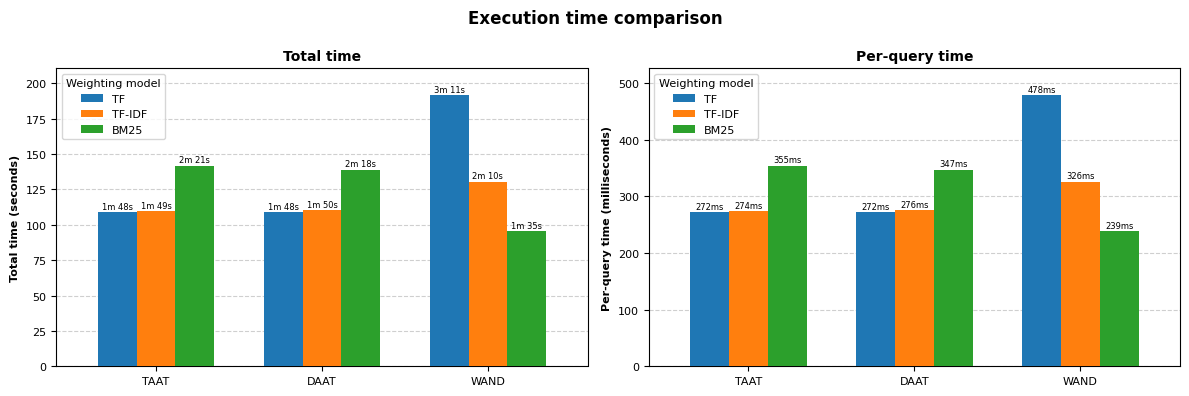

In [ ]:
plot_execution_time_comparison(version="opt", wand=True)

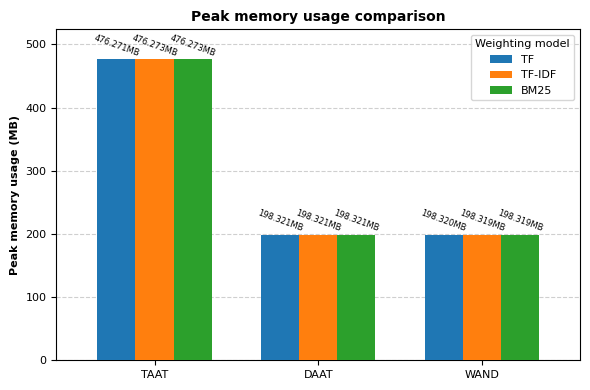

In [ ]:
plot_peak_memory(version="opt", wand=True)

### **Execution time**
The WAND algorithm turns out to have **largely different performances** based on the used *weighting model*.

*   The WAND/TF version is $\approx 175\%$ **slower** than both TAAT/TF and DAAT/TF.
*   The WAND/TF-IDF version improved $\approx 118\%$ **slower** than both TAAT/TF and DAAT/TF.
*   The WAND/BM25 version is $\approx 32\%$ **faster** than both TAAT/BM25 and DAAT/BM25.

Such large fluctuations are deeply analyzed in paragraph ***12.4. Weighting Model Impact on Execution Time***.

### **Memory usage**
The WAND algorithm use the **same peak memory as the DAAT** algorithm: the fluctuations in execution time are not linked with heavier/lighter memory footprint.

### **Conclusion**
Depending on the *weighting model* we would like to use to retrieve data on the *MSMARCO Passage Ranking* collection, our final *ranked retrieving system* should use a different *matching strategy* to achieve top performances in term of *execution time* and *(peak) memory usage*.
-   When using *TF* as *weighting model*, our system should use **DAAT** *matching strategy* (better memory usage).
-   When using *TF-IDF* as *weighting model*, our system should use **DAAT** *matching strategy* (better memory usage).
-   When using *BM25* as *weighting model*, our system should use **WAND** *matching strategy* (less execution time and better memory usage).

Moreover, on the *MSMARCO Passage Ranking* collection, our final *ranked retrieving system* turns out to be at his best in terms of *execution time* and *(peak) memory usage* when combining **WAND** and **BM25**.

## **12.4 Weighting Model Impact on Execution Time**
In paragraph ***12.3 Performance Comparison: TAAT vs DAAT vs WAND - Conclusion*** large differences in the impact of WAND algorithm on the *execution time* of our retrieving system are highlighted. In particular, using different *weighting models* translates into a completely different effect caused by the introduction of WAND.

The TF *weighting model* has encountered a huge worsening in speed (almost twice as slow as both TAAT and DAAT), whilst the BM25 *weighting model* has improved significantly, with TF-IDF in middle (just a light worsening).

The performance discrepancies observed between TF, TF-IDF, and BM25 under the WAND algorithm are dictated by the **tightness of the *upper bounds $UB_t$*** relative to the actual scores. Indeed, WAND relies on the following check to skip documents.

$$\sum_{t \in \text{pivot terms}} UB_t < \theta$$

If the sum of Upper Bounds is lower than the current threshold $\theta$, the algorithm skips.

### Why TF experiences a big slowdown
* **Outliers:** TF is unbounded (even if using the logarithmically normalized version, as we do). In the collection, we very likely have documents where specific terms might appear tenths of times (e.g., a document repeating "university" 50 times) while appearing far less times in all other documents (real stats about documents length are reported in the official [MSMARCO Passage Ranking GitHub Repository](https://github.com/microsoft/MSMARCO-Passage-Ranking/blob/master/stats.txt) by Microsoft).
* **Loose Bounds:** The *upper bound $UB_t$* for the term "university" becomes based on that single outlier document, even if for 99.9% of documents its TF is much smaller. This situation creates a **loose bound**.
* **Pruning Failure:** Since the *upper bound $UB_t$* is inflated by outliers, the condition $\sum UB_t < \theta$ is rarely met: the pivot threshold remains high, preventing the algorithm from skipping documents.
* **Overhead:** WAND incurs significant overhead (sorting cursors, checking pivoting, ...) compared to naive DAAT: if no pruning occurs, **WAND = DAAT + overhead**.

### Why TF-IDF is in the middle
* **Dampening Effect:** IDF introduces the impact of the *document frequency* (i.e., the impact of the distribution of the term in the whole collection), reducing the score of common terms. For those terms, the *upper bound $UB_t$* gets inevitably cut down.
* **Partial Mitigation:** Since terms which are common in a general scope collection as *MSMARCO Passage Ranking* are also likely common in queries ("game", "weather", "people", "computer", ...), there is high probability that such common terms are encountered during query processing. For these terms, the **negative effect of outliers is contained better** respect to TF. On the other hand, this is not a perfect solution and we can anyway encounter terms for which the upper bound is still susceptible to documents with extremely high term frequencies, keeping the bounds loose.

### Why BM25 becomes the fastest
* **Score Saturation:** BM25 uses a saturation function:
    $$\frac{tf}{tf + k_1(\dots)}$$
    As $TF grows$, the score converges to a maximum value (IDF).
* **Tight Bounds:** Even if a document has $TF_t=100$, the score is marginally higher than if $TF_t=10$.
* **Aggressive Pruning:** Having removed outliers, the sum of bounds is "tight", meaning the algorithm correctly realizes when a candidate document cannot beat the current threshold $\theta$.

### Does the original paper mention this behaviour?
In *Broder et al. (2003)*, at paragraph *3. COMPUTING TERM UPPER BOUNDS*, the author of the paper say: *"The problem [...] is that a term upper bound might be set to an extremely high value when the term is extremely frequent in one particular document but infrequent in all other documents. [...], the approximate score of most documents containing this term will be much higher than the true score of the document. These documents will pass the approximate evaluation threshold and will thus be passed to the full evaluation step where they will be rejected."*.

Therefore, it emphasizes that the efficiency of WAND is strictly dependent on the **quality of the upper bounds**. While the authors of the paper don't explicitly benchmark TF vs. TF-IDF vs. BM25, we can assume a sort of corollary from the case study: **unbounded scoring functions (like TF) produce loose bounds in WAND, degrading it to worst-case complexity**.

# **13. Relevance Evaluation**
In the current section, we carry out **performance evaluation** of our system in terms of *relevance* of retrieved documents.

## **13.1. Load Ground Truth (QRELs)**
In this paragraph is reported the definition of the `load_qrels()` function, whose main task is to parse the relevance judgments (*ground truth*) files, which are essential for evaluation.

The function does the following:
1.  Reads a file line-by-line following the standard *TREC format* (`query_id`, `0`, `docno`, `relevance`).
2.  Filters data to keep only **relevant documents** (where `relevance > 0`).
3.  Returns the *qrels* as a nested dictionary structure: `{query_id: {doc_id: relevance_score}}`.

At the end of the cell, the functon itslef is called to load the specific QRELs files for both the *2019 test set* and the *2020 test set*. After that, the QRELs are merged into a single structure called `all_qrels`[$_1$]. From now on we will use the latter to gather information about relevance of retrieved documents.

---
[$_1$] We have previously checked that no `query_id` is in both files.

In [ ]:
def load_qrels(filepath):
    print(f"Loading qrels from {filepath}...")
    qrels = defaultdict(dict)
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 4:
                qid = parts[0]
                docid = parts[2]
                rel = int(parts[3])
                if rel > 0:
                    qrels[qid][docid] = rel
    print(f"Caricati qrels per {len(qrels)} query.")
    return qrels

qrels_2019 = load_qrels(qrels_2019_path)
qrels_2020 = load_qrels(qrels_2020_path)

print("Merging queries into a single structure...")
all_qrels = defaultdict(dict)
for qid, doc_rels in qrels_2019.items():
    all_qrels[qid].update(doc_rels)
for qid, doc_rels in qrels_2020.items():
    all_qrels[qid].update(doc_rels)
print(f"Total unique queries with qrels: {len(all_qrels)}")

Loading qrels from ./dataset/queries/2019qrels-pass.txt...
Caricati qrels per 43 query.
Loading qrels from ./dataset/queries/2020qrels-pass.txt...
Caricati qrels per 54 query.
Merging queries into a single structure...
Total unique queries with qrels: 97


## **13.2. Evaluation Metrics Implementation**
In this paragraph is reported the definition of the functions that implement the computational logic of the metrics used later on: *Precision@k*, *Recall@k*, *AP*, *nDCG@k*, and *RR*.

The implemented metrics are the following.

* **`precision_at_k(retrieved, relevant, k)`**:
    Calculates the fraction of relevant documents within the top `k` retrieved results over the number of retrieved documents. This measures the system's ability to minimize false positives in the top ranks.

* **`recall_at_k(retrieved, relevant, k)`**:
    Calculates the fraction of relevant documents within the top `k` retrieved results over the total number of relevant documents. It effectively measures the "completeness" of the search results.

* **`average_precision(retrieved, relevant)`**:
    Computes the *Average Precision (AP)* for a single query. It averages the precision scores obtained at the rank of each relevant document. This metric rewards systems that retrieve relevant documents earlier in the list and is the basis for *Mean Average Precision (MAP)*.

* **`ndcg_at_k(retrieved, relevant_scores, k)`**:
    Computes the *normalized Discounted Cumulative Gain at rank k (nDCG@k)*.

    * It first calculates *Discounted Cumulative Gain at rank k (DCG@k)* (via the helper function `dcg_at_k()`), which accumulates relevance scores while penalizing documents found lower in the ranking using a logarithmic decay.
    * It then normalizes the *DCG@k* by the *ideal Discounted Cumulative Gain at rank k (iDCG@k)*, which is the *DCG@k* of a perfect ordering of results.

    This metric is crucial as it accounts for both the position and the degree of relevance.

* **`reciprocal_rank(retrieved, relevant)`**:
    Calculates the inverse of the rank of the first relevant document found. This is used to compute the *Mean Reciprocal Rank (MRR)*, evaluating how quickly the system satisfies the user's information need.

In [ ]:
### HELPER FUNCTION for nDCG computation ###
def dcg_at_k(retrieved_docids, relevant_scores, k):
    dcg = 0.0
    for i, docid in enumerate(retrieved_docids[:k]):
        if docid in relevant_scores:
            rel = relevant_scores[docid]
            dcg += rel / math.log2(i + 2)
    return dcg

In [ ]:
print("Defining evaluation metric functions...")
def precision_at_k(retrieved_docids, relevant_docids, k):
    retrieved_k = retrieved_docids[:k]
    if not retrieved_k: return 0.0
    relevant_retrieved = sum(1 for docid in retrieved_k if docid in relevant_docids)
    return relevant_retrieved / k

def recall_at_k(retrieved_docids, relevant_docids, k):
    retrieved_k = retrieved_docids[:k]
    total_relevant = len(relevant_docids)
    if total_relevant == 0: return 0.0
    relevant_retrieved = sum(1 for d in retrieved_k if d in relevant_docids)
    return relevant_retrieved / total_relevant

def average_precision(retrieved_docids, relevant_docids):
    if not relevant_docids: return 0.0
    hits = 0
    sum_precisions = 0.0
    for i, docid in enumerate(retrieved_docids):
        if docid in relevant_docids:
            hits += 1
            sum_precisions += hits / (i + 1.0)
    return sum_precisions / len(relevant_docids)

def ndcg_at_k(retrieved_docids, relevant_scores, k):
    if not relevant_scores: return 0.0
    dcg = dcg_at_k(retrieved_docids, relevant_scores, k)
    ideal_rels = sorted(relevant_scores.values(), reverse=True)
    idcg = 0.0
    for i, rel in enumerate(ideal_rels[:k]):
        idcg += rel / math.log2(i + 2)
    if idcg == 0: return 0.0
    return dcg / idcg

def reciprocal_rank(retrieved_docids, relevant_docids):
    for i, docid in enumerate(retrieved_docids):
        if docid in relevant_docids:
            return 1.0 / (i + 1.0)
    return 0.0
print("Evaluation metric functions defined successfully.")

Defining evaluation metric functions...
Evaluation metric functions defined successfully.


## **13.3. Evaluation Metrics Computation**
After having defined all auxiliary functions needed at this step, we define the `evaluate_system()` function, which acts as the main driver for assessing the retrieving system performance.

It performs the following operations for each query for which there are the relevance assessment (QRELs).

1.  **Retrieval**: Load the files with the results of the query processing obtained by the execution cells in section ***12. Efficient Query Processing via WAND (Weak AND)***[$_1$] and filter them mantaining only those queries (identified by their own `query_id`) for which we have also the *relevance assessment (QREL)*.
2.  **Metrics Calculation**: Computes *Precision@k*, *Recall@k*, *RR*, *AP*, and *nDCG@k* for the single query by comparing the retrieved results against the ground truth (QRELs).
3.  **Metrics Displaying**: After the computation, prints the *mean score* for each metric across all processed queries to summarize the system overall effectiveness.
4.  **Metrics Saving**: After that, saves to disk the metrics obtained from the single query results (in order to use them in a *t-test* later on).

**N.B.**: Note that the documents in *MSMARCO Passage Ranking* collection have string *docnos* starting from $0$. At the same way, our inverted index uses *docids* starting from $0$ to uniquely identify documents. Looking back at the way we have built our inverted index, there is a perfect matching between *docnos* and *docids* (i.e. a document having $docno=k$ will also have $docid=k$). For this reason, the function `evaluate_system()` has no need to map *docids* back to *docnos*.

---
[$_1$] We have performed tests using `k=10`, i.e. for each query we have retrieved and saved to disk the 10 best matching documents. We have chosen such value since most of the online experiments on *MSMARCO Passage Ranking* collection use the *MRR@10* as main metric [MSMARCO Passage Ranking ir_dataset](https://ir-datasets.com/msmarco-passage.html#msmarco-passage/trec-dl-hard:~:text=Evaluation%20typically%20conducted%20using%20MRR%4010).

In [ ]:
print("Defining system evaluation function...")
def evaluate_system(all_qrels, k=10):
    results_taat_tf_opt = pd.read_csv(results_taat_tf_opt_test_path, index_col=False, dtype={'query_id': str, 'doc_id': str, 'rank': int, 'score': float})
    results_daat_tf_opt = pd.read_csv(results_daat_tf_opt_test_path, index_col=False, dtype={'query_id': str, 'doc_id': str, 'rank': int, 'score': float})
    results_wand_tf_opt = pd.read_csv(results_wand_tf_opt_test_path, index_col=False, dtype={'query_id': str, 'doc_id': str, 'rank': int, 'score': float})
    results_taat_tfidf_opt = pd.read_csv(results_taat_tfidf_opt_test_path, index_col=False, dtype={'query_id': str, 'doc_id': str, 'rank': int, 'score': float})
    results_daat_tfidf_opt = pd.read_csv(results_daat_tfidf_opt_test_path, index_col=False, dtype={'query_id': str, 'doc_id': str, 'rank': int, 'score': float})
    results_wand_tfidf_opt = pd.read_csv(results_wand_tfidf_opt_test_path, index_col=False, dtype={'query_id': str, 'doc_id': str, 'rank': int, 'score': float})
    results_taat_bm25_opt = pd.read_csv(results_taat_bm25_opt_test_path, index_col=False, dtype={'query_id': str, 'doc_id': str, 'rank': int, 'score': float})
    results_daat_bm25_opt = pd.read_csv(results_daat_bm25_opt_test_path, index_col=False, dtype={'query_id': str, 'doc_id': str, 'rank': int, 'score': float})
    results_wand_bm25_opt = pd.read_csv(results_wand_bm25_opt_test_path, index_col=False, dtype={'query_id': str, 'doc_id': str, 'rank': int, 'score': float})

    all_results = {
        "taat_tf": results_taat_tf_opt,
        "daat_tf": results_daat_tf_opt,
        "wand_tf": results_wand_tf_opt,
        "taat_tfidf": results_taat_tfidf_opt,
        "daat_tfidf": results_daat_tfidf_opt,
        "wand_tfidf": results_wand_tfidf_opt,
        "taat_bm25": results_taat_bm25_opt,
        "daat_bm25": results_daat_bm25_opt,
        "wand_bm25": results_wand_bm25_opt
    }

    all_metrics = defaultdict(dict)

    for results_name, results in all_results.items():
        grouped_results = results.groupby('query_id')
        for query_id, group in grouped_results:
            if query_id not in all_qrels:
                continue

            qrels = all_qrels[query_id]
            retrieved_docids = group['doc_id'].tolist()
            relevant_docids = [d for (d, r) in qrels.items() if r >= 2]
            if len(relevant_docids) == 0:
                continue

            p_at_k = precision_at_k(retrieved_docids, relevant_docids, k)
            r_at_k = recall_at_k(retrieved_docids, relevant_docids, k)
            rr = reciprocal_rank(retrieved_docids, relevant_docids)
            ap = average_precision(retrieved_docids, relevant_docids)
            nDCG_at_k = ndcg_at_k(retrieved_docids, qrels, k)

            all_metrics[results_name][query_id] = {
                f"P@{k}": p_at_k,
                f"R@{k}": r_at_k,
                "RR": rr,
                "AP": ap,
                f"nDCG@{k}": nDCG_at_k
            }

    mean_metrics = {}
    for results_name, metrics in all_metrics.items():
        mean_metrics[results_name] = {
            "RR": np.mean([m["RR"] for m in metrics.values()]),
            f"nDCG@{k}": np.mean([m[f"nDCG@{k}"] for m in metrics.values()]),
            f"P@{k}": np.mean([m[f"P@{k}"] for m in metrics.values()]),
            f"R@{k}": np.mean([m[f"R@{k}"] for m in metrics.values()]),
            "AP": np.mean([m["AP"] for m in metrics.values()])
        }
    print(f"--- MEAN METRICS ---")
    for results_name, metrics in mean_metrics.items():
        print(f"{results_name.upper()}:")
        for metric_name, metric_value in metrics.items():
            print(f"  {metric_name}: {metric_value:.4f}")
        print("")

    for results_name, metrics in all_metrics.items():
        metrics_df = pd.DataFrame.from_dict(metrics, orient='index')
        metrics_df.index.name = 'query_id'
        metrics_df.to_csv(f"metrics/opt/metrics_{results_name}.csv")

    return mean_metrics
print("System evaluation function defined successfully.")

Defining system evaluation function...
System evaluation function defined successfully.


In [ ]:
mean_metrics = evaluate_system(all_qrels, k=10)

--- MEAN METRICS ---
TAAT_TF:
  RR: 0.4111
  nDCG@10: 0.2796
  P@10: 0.2206
  R@10: 0.1110
  AP: 0.0671

DAAT_TF:
  RR: 0.4063
  nDCG@10: 0.2803
  P@10: 0.2247
  R@10: 0.1116
  AP: 0.0666

WAND_TF:
  RR: 0.4063
  nDCG@10: 0.2803
  P@10: 0.2247
  R@10: 0.1116
  AP: 0.0666

TAAT_TFIDF:
  RR: 0.5475
  nDCG@10: 0.3963
  P@10: 0.3082
  R@10: 0.1665
  AP: 0.1192

DAAT_TFIDF:
  RR: 0.5280
  nDCG@10: 0.3944
  P@10: 0.3093
  R@10: 0.1698
  AP: 0.1183

WAND_TFIDF:
  RR: 0.5280
  nDCG@10: 0.3944
  P@10: 0.3093
  R@10: 0.1698
  AP: 0.1183

TAAT_BM25:
  RR: 0.6296
  nDCG@10: 0.4847
  P@10: 0.3629
  R@10: 0.2136
  AP: 0.1512

DAAT_BM25:
  RR: 0.6345
  nDCG@10: 0.4857
  P@10: 0.3629
  R@10: 0.2136
  AP: 0.1513

WAND_BM25:
  RR: 0.6345
  nDCG@10: 0.4857
  P@10: 0.3629
  R@10: 0.2136
  AP: 0.1513



### Visualization of Metrics
We define and execute a function `plot_mean_metrics()` to visualize the *mean metrics* in histograms. We plot a separated graph for each metric, in order to clearly identify the best performing system for each of them.

Recall that we give particular attention to *MRR* and *nDCG@10*, which are respectively the primary and the secondary metric on which tests are commonly performed on *MSMARCO Passage Ranking* collection.

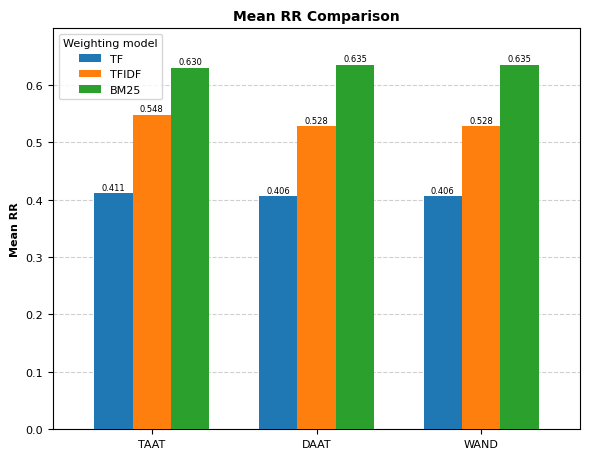

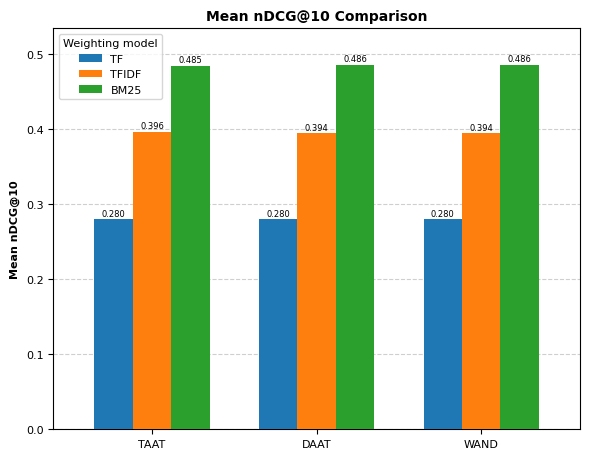

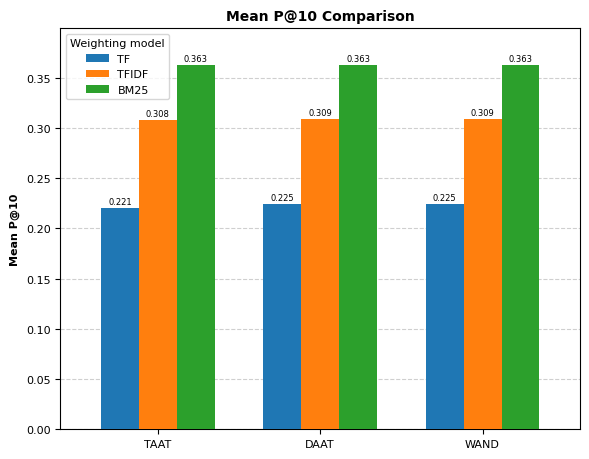

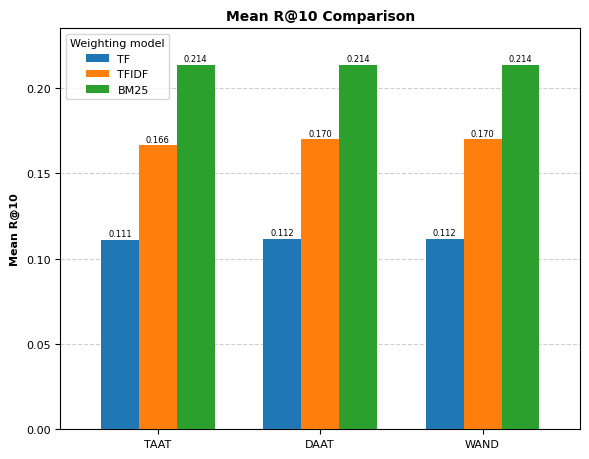

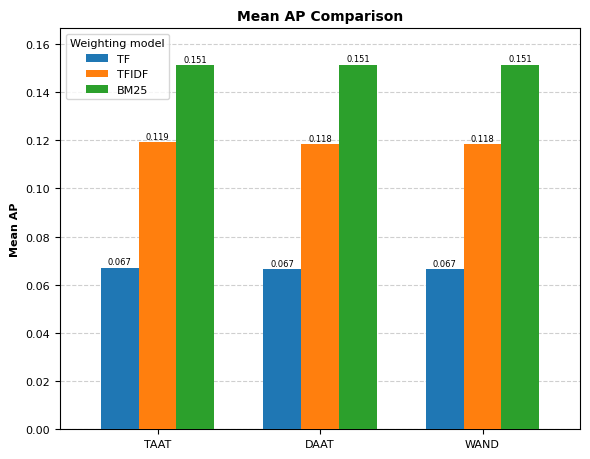

In [ ]:
def plot_mean_metrics(mean_metrics, metric_name):
    strategies = ['TAAT', 'DAAT', 'WAND']
    weighting_models = ['TF', 'TFIDF', 'BM25']

    data = {model: [] for model in weighting_models}

    for strat in strategies:
        for weight in weighting_models:
            key = f"{strat.lower()}_{weight.lower()}"
            val = mean_metrics.get(key, {}).get(metric_name, 0.0)
            data[weight].append(val)

    metric_df = pd.DataFrame(data, index=strategies)

    _, ax = plt.subplots(figsize=(6, 4.7))
    metric_df.plot(
        kind='bar',
        ax=ax,
        rot=0,
        width=0.7,
        zorder=3
    )

    ax.set_title(f"Mean {metric_name} Comparison", fontsize=10, fontweight='bold')
    ax.legend(title="Weighting model", title_fontsize=8, fontsize=8, loc='upper left')
    ax.set_ylabel(f"Mean {metric_name}", fontsize=8, fontweight='bold')
    ax.set_ylim(0, metric_df.max().max() * 1.1)
    ax.tick_params(axis='both', labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.6, zorder=0)

    for p in ax.patches:
        value = p.get_height() # type: ignore
        if value > 0:
            label = f"{value:.3f}"
            ax.annotate(label,
                        (p.get_x() + p.get_width() / 2., p.get_height()), # type: ignore
                        ha='center', va='bottom', xytext=(0, 1),
                        fontsize=6, color='black',
                        textcoords='offset points')

    plt.tight_layout()

    plt.savefig(f"graphs/opt/metrics_comparison_{metric_name}.svg")
    plt.show()

sample_key = list(mean_metrics.keys())[0]
metrics_to_plot = list(mean_metrics[sample_key].keys())

for m in metrics_to_plot:
    plot_mean_metrics(mean_metrics, m)

## **13.4. Analysis of Evaluation Metrics Results**
The table above summarizes the performance of our search engine across the 9 combinations of *matching strategies* and *weighting models*. By analyzing these metrics, we can draw several key conclusions regarding the effectiveness of the implemented components.

### Comparison of Weighting Models
There is a distinct and consistent hierarchy in performance determined by the *weighting model*, regardless of the matching strategy used:

* **TF:** Consistently yields the **lowest performance** across all metrics and *matching strategies*. This is expected, as TF does not account for term specificity or document length normalization.
* **TF-IDF:** Provides a **significant improvement** over TF across all metrics and *matching strategies* (we have the major upgrade in *Mean AP*, where TF-IDF doubles the TF value).
* **BM25:** Is the clear **top performer** across all metrics and *matching strategies*. This confirms the theoretical superiority of probabilistic models for *MSMARCO Passage Ranking* collection.

### Comparison of Matching Strategies
An interesting pattern emerges when comparing the *matching strategies*.
-   **DAAT = WAND**:
    -   All metrics for DAAT and WAND are **identical for every *weighting model*** (e.g., DAAT/BM25 and WAND/BM25 both have $RR = 0.6345$ and $nDCG@10 = 0.4857$).
    -   This confirms that our WAND implementation is perfectly safe while more efficient in terms of *execution time* (the competitive documents are not skipped by the algorithm).
-   **TAAT deviations**:
    -   In **TF-IDF**, TAAT actually scores slightly higher than DAAT/WAND for some metrics (e.g. $RR = 0.5475$ vs. $0.5280$).
    -   In **BM25**, TAAT scores slightly lower to DAAT/WAND for some metrics (e.g. $RR = 0.6296$ vs. $0.6345$).
    -   TAAT produces results that are slightly different from DAAT/WAND. Since TAAT traverses posting lists (i.e. processes documents) in a different fashion respect DAAT/WAND, the *order of floating-point additions* differs, likely leading to microscopic differences in final scores. Such differences can affect the final ranking for some queries, resulting in position swaps for some documents.
    -   For some metrics, the differences between TAAT and DAAT/WAND are a bit larger. They can be likely accounted to different ordering of documents that have the exact same score: DAAT ensure us to order those documents by increasing docid, whilst TAAT does not.

Despite the TAAT slight deviations and considering that the likely random TAAT advantage in some metrics completely disappear using BM25 as *weighting model*, all ***matching strategies* can be considered comparable in performances** for all metrics.

### The "Best" System Configuration
Based on the mean metrics, the best performing combination of *matching strategy* and *weighting model* in every single metric are **WAND/BM25** and **DAAT/BM25**.

* **RR**: 0.6345
* **nDCG@10**: 0.4857
* **P@10**: 0.3629
* **R@10**: 0.2136
* **AP**: 0.1513

### Final System Choice
Since **WAND/BM25** achieves the same top-tier quality as DAAT/BM25 but is *computationally more efficient* (as shown in previous performance benchmarks at paragraph ***12.3 Performance Comparison: TAAT vs DAAT vs WAND***), it is the final **optimal choice** for our ranked retrieving system.

Since this is the best performing configuration of our system, we will use it later on (in section ***15. Our Retrieving System VS PyTerrier***) to compare our retrieving system to *PyTerrier*.

## **13.5. Statistical Tests**
After having computed the metrics and the  for each combination of *matching strategy* and *weighting model*, the results obtained in paragraph ***13.3. Evaluation Metrics Computation*** and discussed in paragraph ***13.4. Analysis of Evaluation Metrics Results*** need to be validated using a statistical test.

### Paired t-test
For our purposes, the simplest statistical test we can perform is the **paired t-test**. Such test compares the observed values of two variables, stating if the difference between the mean of the two distibutions is statistically significant.
-   $H_0$: $\mu_d = 0$, i.e. there is *no difference* between paired observations.
-   $H_1$: $\mu_d \neq 0$, i.e. there is a *significant difference* between paired observations.

In our case study, a *variable* in the test is represented by a single combination of *matching strategy* and *weighting model* (e.g., TAAT/TF, DAAT/TF, ...). Since each metric needs his own statistical test, the *values* of a single variable are the values of a single metric for a single combination (each value computed on the ranking obtained from a single query).

The *paired t-test* provides two values:
-   The **p-value** $p$ states if the mean difference seen in the distributions of two combinations of *matching strategy* and *weighting model* (for a single metric) is statistically significant ($p < \alpha$, with $\alpha = 0.05$).
-   The **t-statistic** $t$ states (whenever $p < \alpha$) which of the two combinations of *matching strategy* and *weighting model* is better than the other one:
    -   if $t < 0$, the $1^{st}$ combination is better;
    -   if $t > 0$, the $2^{nd}$ combination is better.

#### Normality Assumption for *paired t-test*
The *paired t-test* has a major drawback: in order to use it, we need to check a bunch of **hypotheses** about data distribution.

The major hypothesis is the **normality assumption**, which requires the *differences* between paired observations to be *normally distributed* (not the raw values of a single variable). Therefore, before performing the *paired t-test*, we must check if data meet such requirement. We use the **Shapiro-Wilk test**.
-   $H_0$: The differences are *normally distributed*.
-   $H_1$: The differences are *NOT normally distributed*.

The *Shapiro-Wilk test* provides us the *p-value* $p$:
-   if $p < \alpha$ with $\alpha < 0.05$, we *reject the null hypothesis*, so ***t-test* might be invalid** and its results cannot be considered valid.

In [ ]:
system_files = {
    "taat_tf": "metrics/opt/metrics_taat_tf.csv",
    "taat_tfidf": "metrics/opt/metrics_taat_tfidf.csv",
    "taat_bm25": "metrics/opt/metrics_taat_bm25.csv",
    "daat_tf": "metrics/opt/metrics_daat_tf.csv",
    "daat_tfidf": "metrics/opt/metrics_daat_tfidf.csv",
    "daat_bm25": "metrics/opt/metrics_daat_bm25.csv",
    "wand_tf": "metrics/opt/metrics_wand_tf.csv",
    "wand_tfidf": "metrics/opt/metrics_wand_tfidf.csv",
    "wand_bm25": "metrics/opt/metrics_wand_bm25.csv"
}

k = 10
metrics = ["RR", f"nDCG@{k}", f"P@{k}", f"R@{k}", "AP"]

def load_and_align_data(file_map):
    data = {}

    first_name, first_path = list(file_map.items())[0]
    df_base = pd.read_csv(first_path)
    data[first_name] = df_base.set_index('query_id')

    for name, path in list(file_map.items())[1:]:
        df = pd.read_csv(path).set_index('query_id')
        common_index = data[first_name].index.intersection(df.index)
        data[first_name] = data[first_name].loc[common_index]
        data[name] = df.loc[common_index]

    print(f"Aligned data on {len(data[list(file_map.keys())[0]])} common queries.")
    return data

def check_normality(aligned_data, sys_a, sys_b, metric_to_check):
    violated = False
    if sys_a in aligned_data and sys_b in aligned_data:
        diffs = aligned_data[sys_a][metric_to_check] - aligned_data[sys_b][metric_to_check]
        if diffs.nunique() <= 1:
            return True

        _, p_val = stats.shapiro(diffs)  # type: ignore
        if p_val < 0.05:
            violated = True

    return violated

aligned_data = load_and_align_data(system_files)
system_names = list(aligned_data.keys())

print("Executing normality checks for all system pairs and metrics...")
violated_pairs = 0
for i in range(len(system_names)):
    for j in range(i + 1, len(system_names)):
        sys_a = system_names[i]
        sys_b = system_names[j]

        for metric in metrics:
            violated = check_normality(aligned_data, sys_a, sys_b, metric)
            if violated:
                violated_pairs += 1

print(f"\nTotal pairs with normality violation: {violated_pairs}/{int(len(system_names) * (len(system_names) - 1) / 2 * len(metrics))}.")

Aligned data on 97 common queries.
Executing normality checks for all system pairs and metrics...

Total pairs with normality violation: 180/180.


We can clearly see that the *null hypothesis* of the *Shapiro-Wilk test* is **violated for every pair** of the test. Therefore, the results of all the *t-tests* we should perform may not be valid: the ***paired t-test* is not a good choice** for evaluating the statistical robustness of the metrics obtained from all the combinations of *matching strategy* and *weighting model*.

### Wilcoxon Signed-Rank Test
Since the normality assumption for the *paired t-test* was violated, we employ the **Wilcoxon Signed-Rank Test**[$_1$]. This is a non-parametric pairwise test that compares the *medians* of two dependent samples.
-   $H_0$: The two systems have a *null median difference*.
-   $H_1$: The two systems have a *NOT null median difference*.

---
[$_1$] We will refer to the **Wilcoxon Signed-Rank Test** simply as *Wilcoxon Test* from now on.

The standard *Wilcoxon Test* outputs a generic $W$ statistic (always positive). To visualize the direction of improvement (like the *t-statistic*, as we explained in paragraph ***13.5. Statistical Tests - Paired t-test***), we compute the **Z-score approximation** as follows:

$$Z = \frac{W^+ - \mu_W}{\sigma_W}$$

where $W^+$ is the *sum of ranks for positive differences*.

-   If $W^+ > 0$, the $1^{st}$ combination is better (system on the row in heatmaps later on);
-   If $W^+ < 0$, the $2^{nd}$ combination is better (system on the column in heatmaps later on).

In [ ]:
def compute_wilcoxon_z_score(diffs):
    diffs = np.array(diffs)
    diffs = diffs[diffs != 0]
    n_reduced = len(diffs)
    if n_reduced == 0:
        return 0.0

    ranks = stats.rankdata(np.abs(diffs))   # type: ignore
    w_plus = np.sum(ranks[diffs > 0])

    mu_w = n_reduced * (n_reduced + 1) / 4.0
    sigma_w = np.sqrt(n_reduced * (n_reduced + 1) * (2 * n_reduced + 1) / 24.0)
    z = (w_plus - mu_w) / sigma_w

    return z

def run_all_pairwise_wilcoxon(data_map, metric_list):
    systems = list(data_map.keys())
    n_sys = len(systems)

    z_scores = {m: pd.DataFrame(index=systems, columns=systems, dtype=float) for m in metric_list}
    p_values = {m: pd.DataFrame(index=systems, columns=systems, dtype=float) for m in metric_list}

    print("Running pairwise Wilcoxon tests...")
    for m in metric_list:
        for i in range(n_sys):
            for j in range(n_sys):
                sys_i = systems[i]
                sys_j = systems[j]

                if i == j:
                    z_scores[m].iloc[i, j] = 0.0
                    p_values[m].iloc[i, j] = 1.0
                    continue

                vec_i = data_map[sys_i][m].values
                vec_j = data_map[sys_j][m].values
                diff = vec_i - vec_j

                if np.all(diff == 0):
                    z_scores[m].iloc[i, j] = 0.0
                    p_values[m].iloc[i, j] = 1.0
                    continue

                try:
                    with np.errstate(divide='ignore', invalid='ignore'):
                         res = stats.wilcoxon(vec_i, vec_j, alternative='two-sided')  # type: ignore
                    p_val = res.pvalue
                except ValueError:
                    p_val = 1.0

                z_score = compute_wilcoxon_z_score(diff)

                z_scores[m].iloc[i, j] = z_score
                p_values[m].iloc[i, j] = p_val

    print("Computation complete.")
    return z_scores, p_values

z_matrices, p_matrices_wilcoxon = run_all_pairwise_wilcoxon(aligned_data, metrics)

Running pairwise Wilcoxon tests...
Computation complete.


#### Visualization of *Wilcoxon Test* results
The results of all the *Wilcoxon Test* combinations are displayed below plotting two heatmaps for each metric we used to evaluate our system. Each metric has its own image, showing:
-   On the left, the **p-value heatmap** of that metric:
    -   A *green cell* indicates a statistically significant difference for that pair ($p < \alpha$ with $\alpha = 0.05$).
    -   A *red cell* indicates that no statistically significant difference can be found for that pair ($p > \alpha$ with $\alpha = 0.05$).
-   On the right, the **Z-score heatmap** of that metric:
    -   A *green cell* indicates that the system on the row is significantly better than the system on the column ($Z > 0$).
    -   A *red cell* indicates that the system on the row is significantly worse than the system on the column ($Z < 0$).

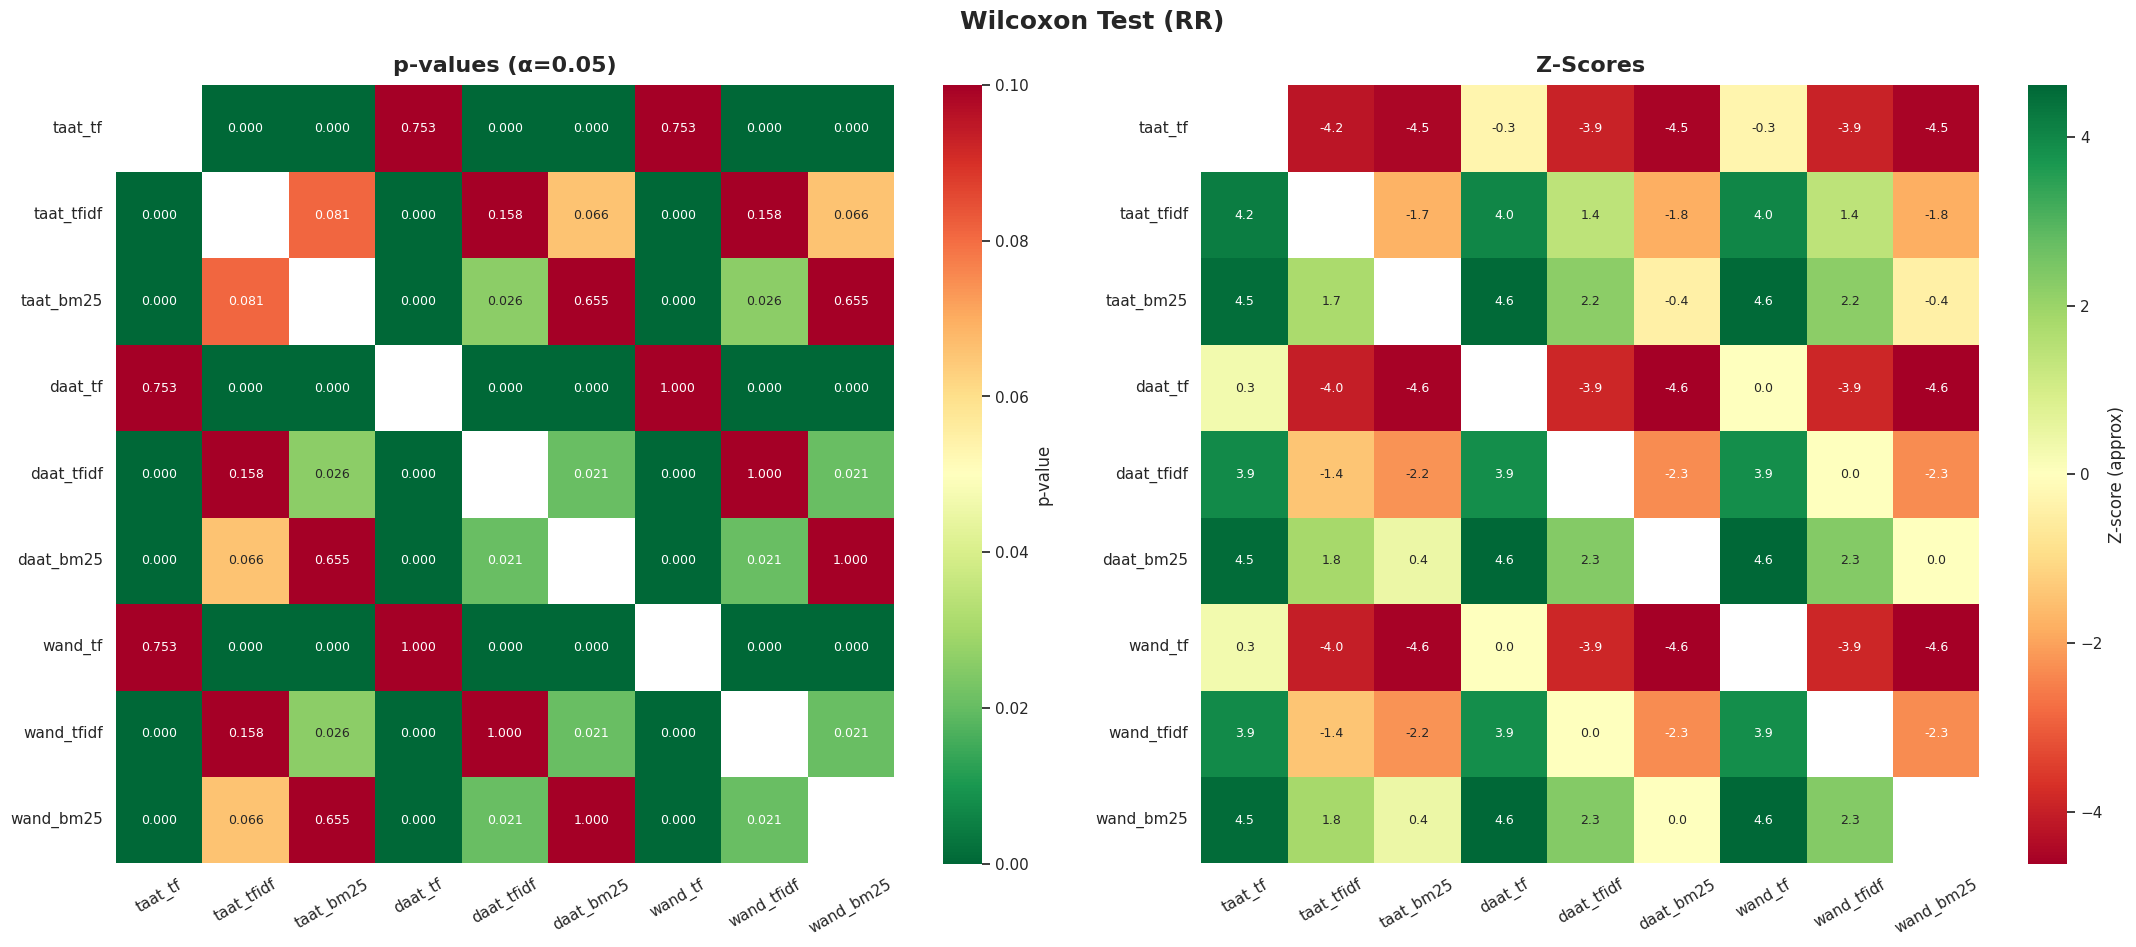

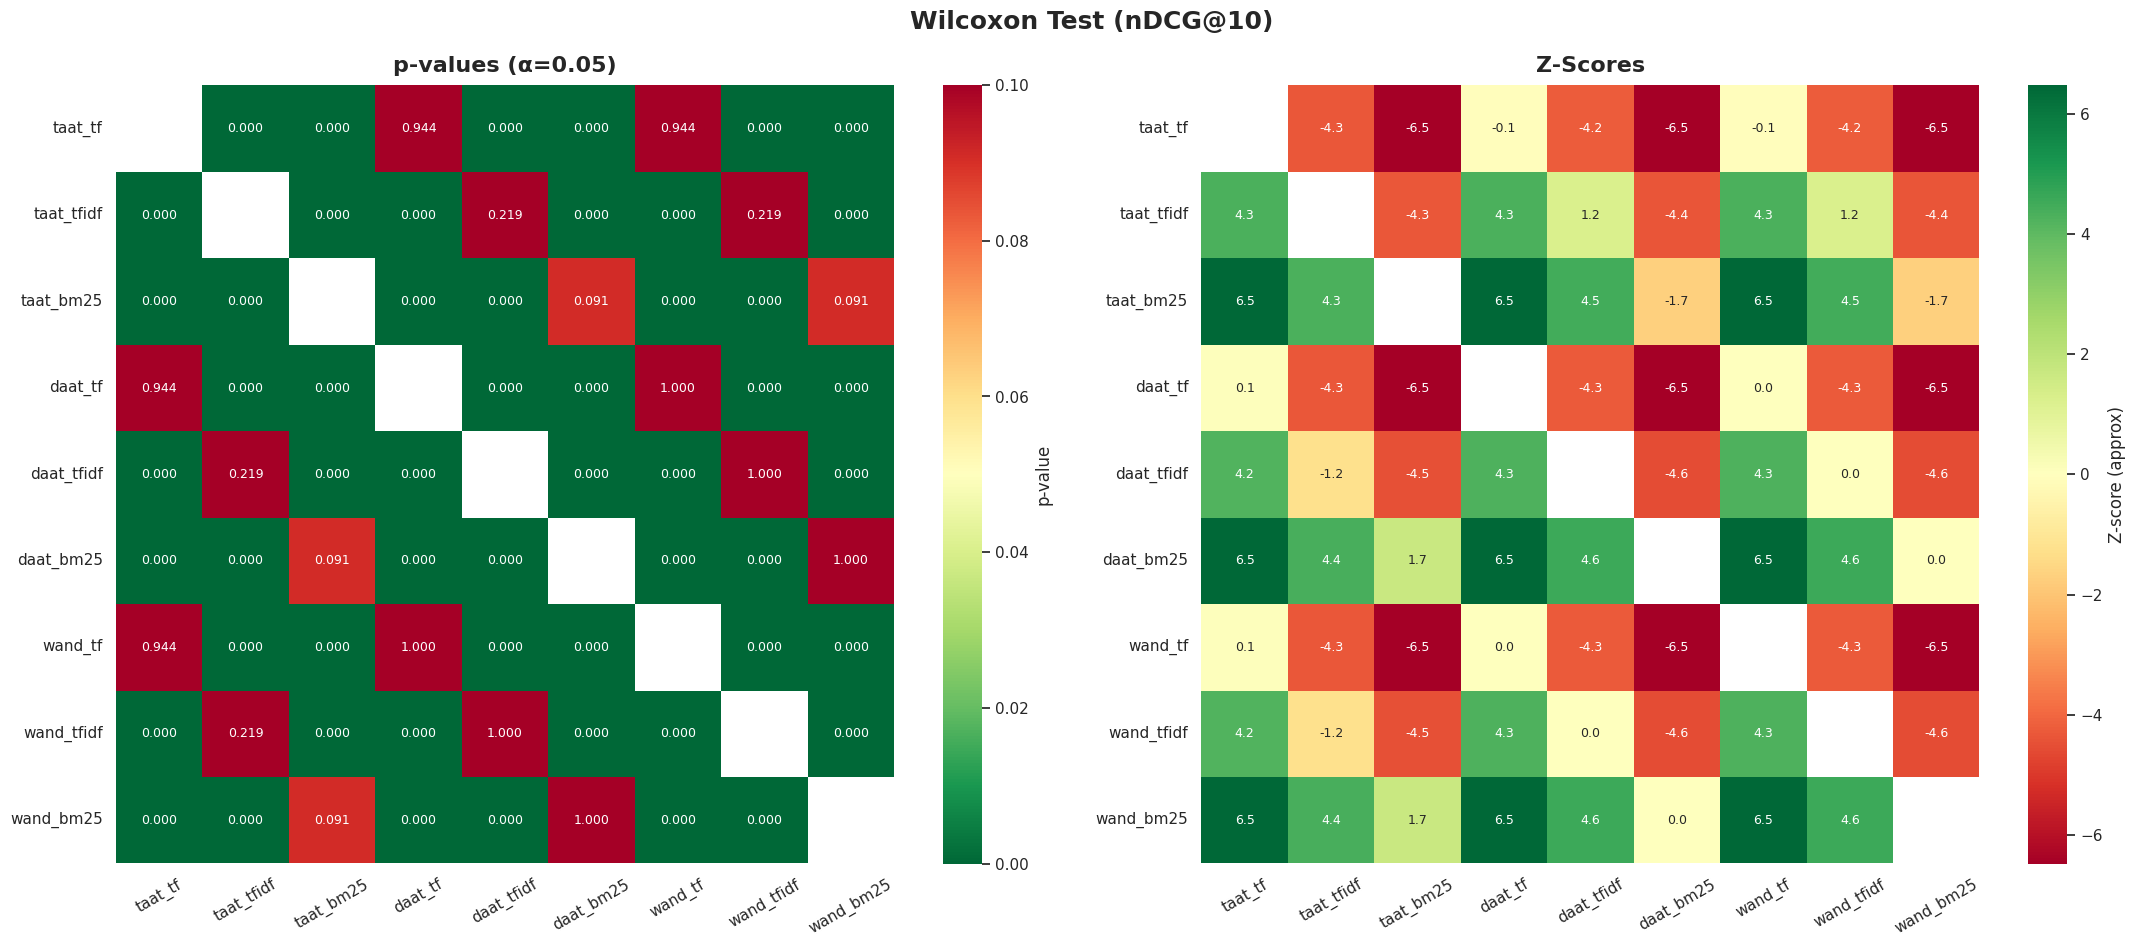

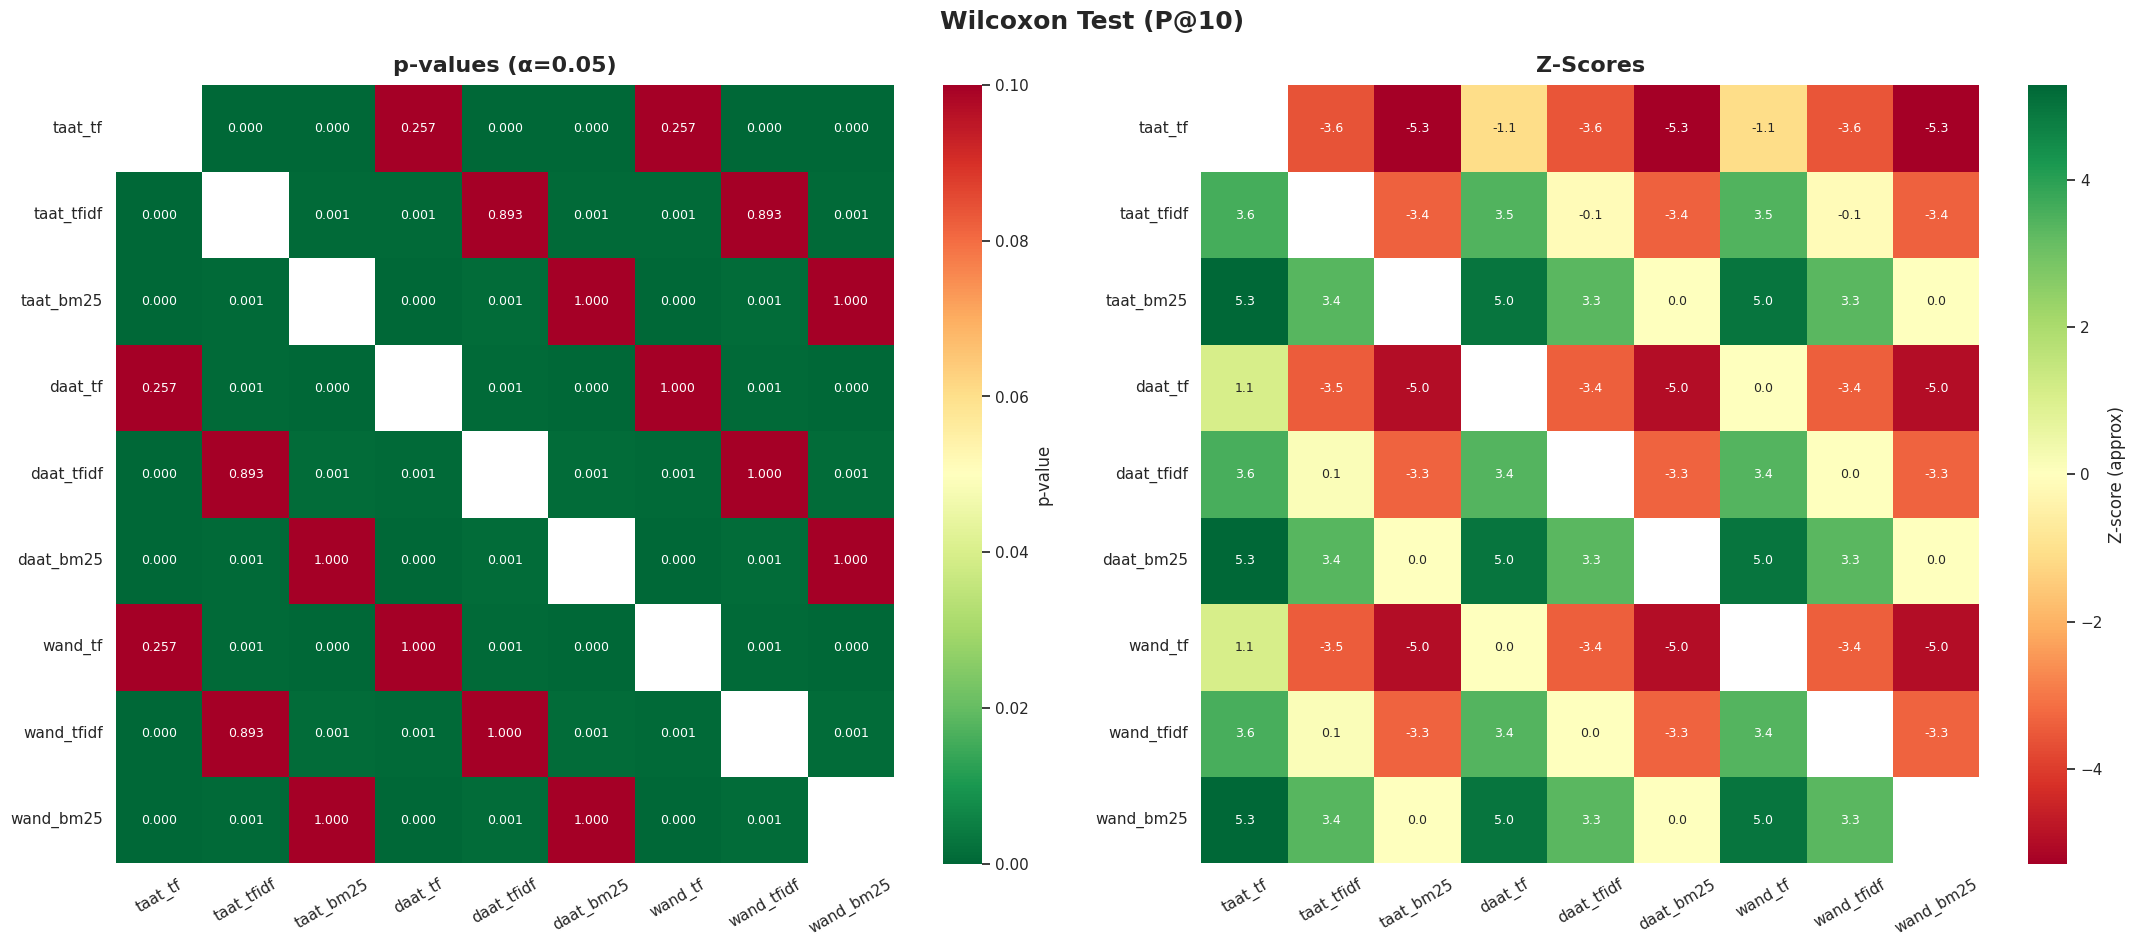

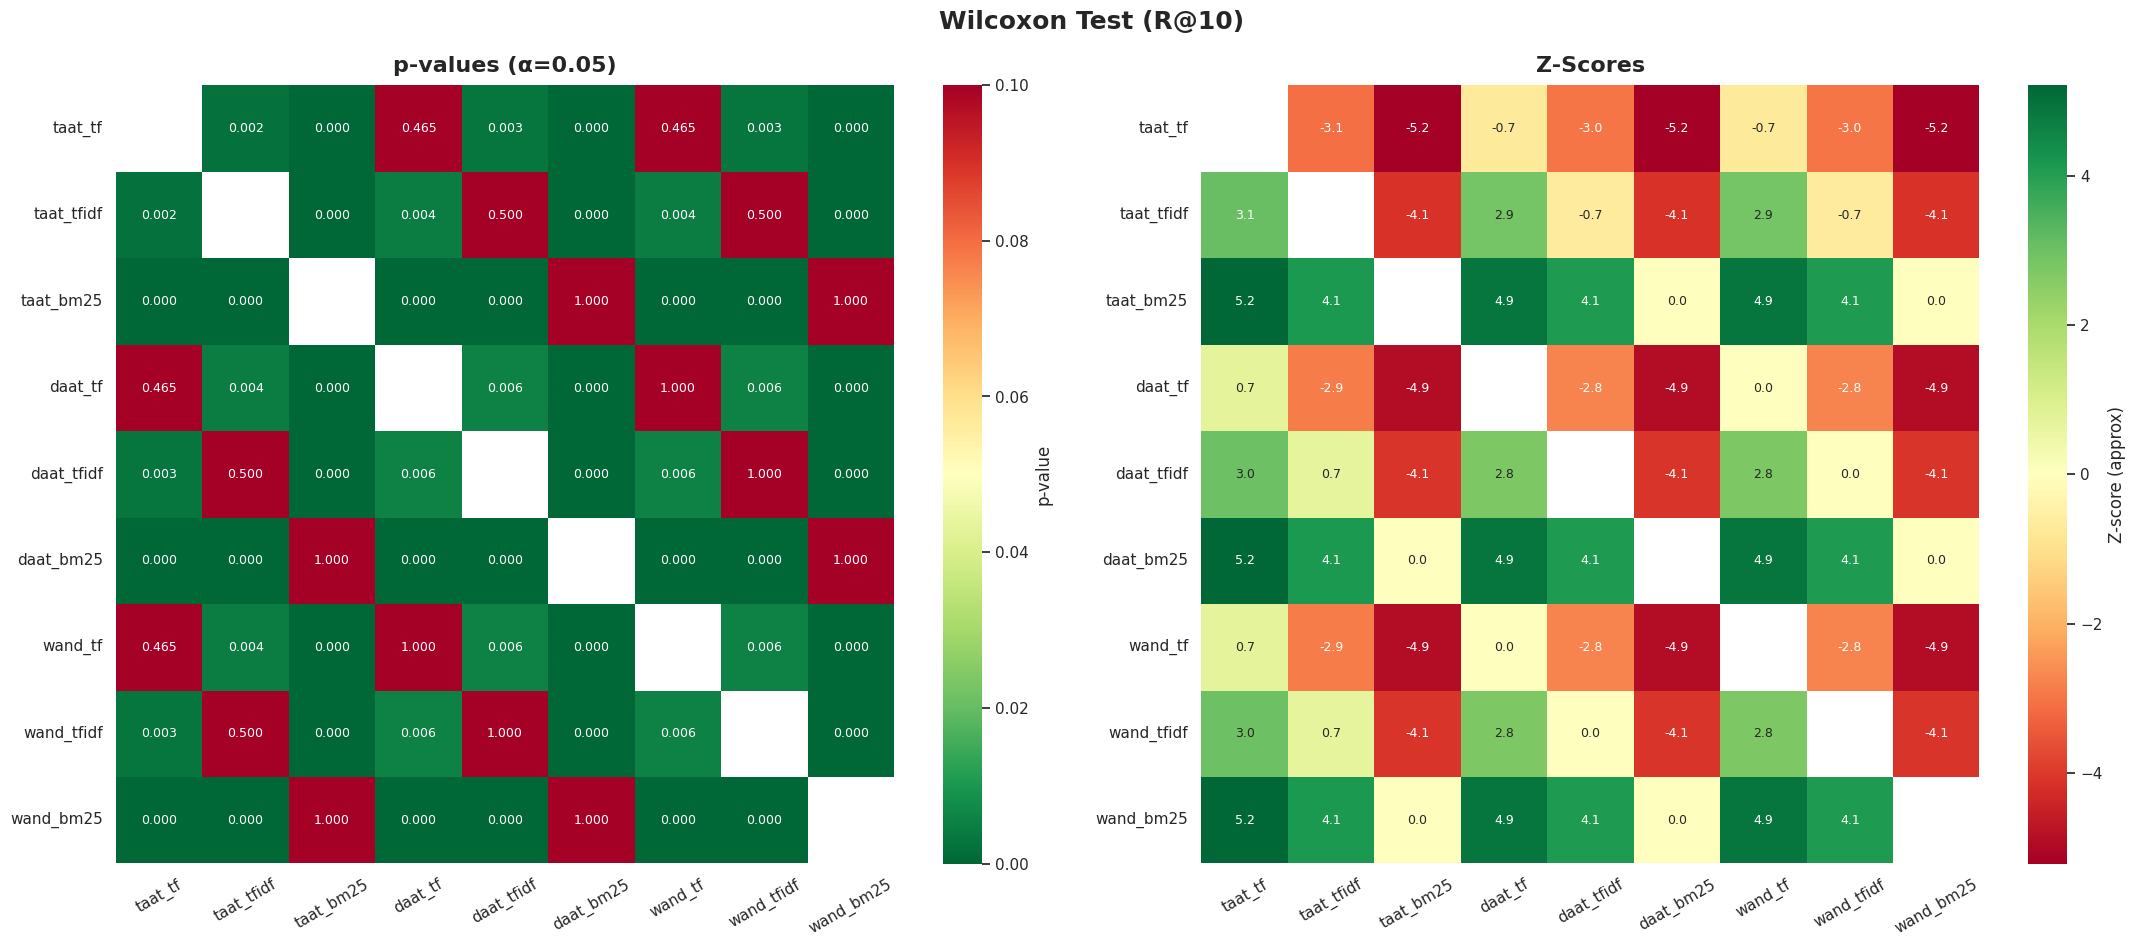

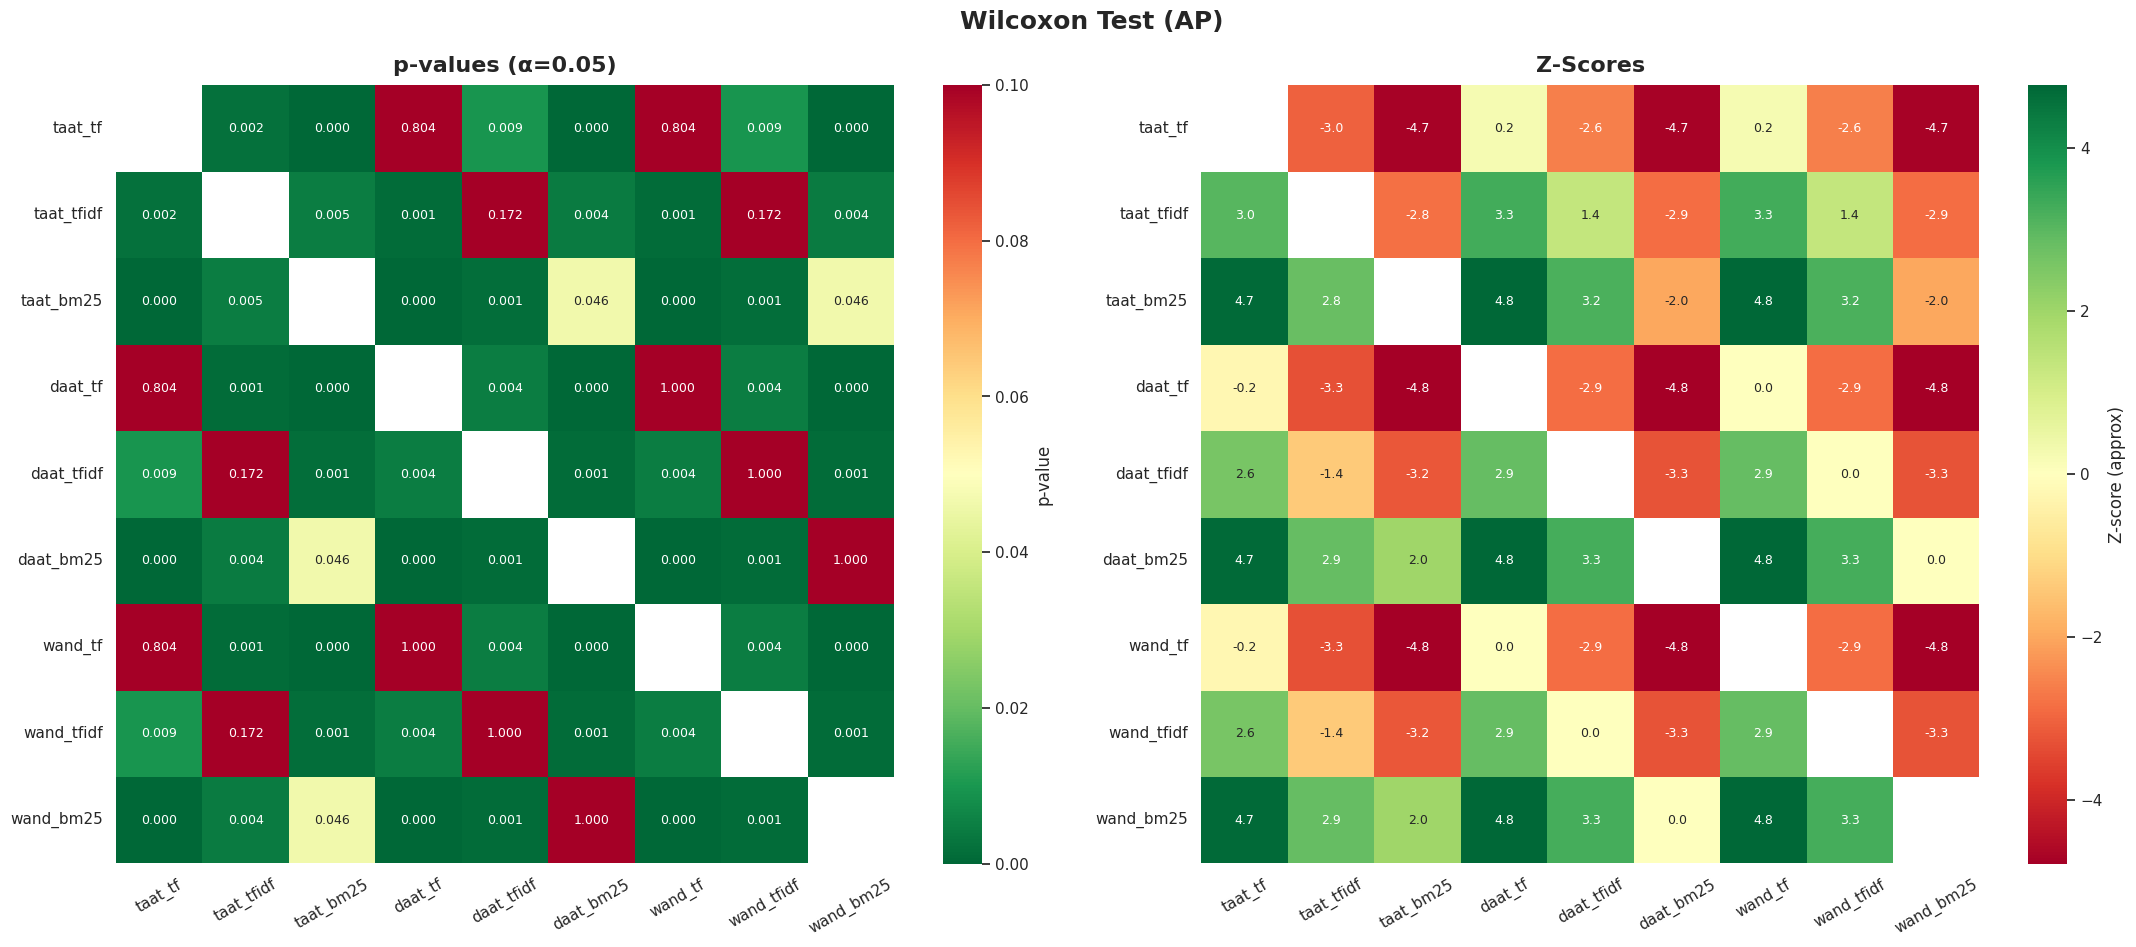

In [ ]:
def plot_wilcoxon_heatmaps(z_dict, p_dict, metric_list):
    sns.set_theme(style="white")

    for m in metric_list:
        fig, axes = plt.subplots(1, 2, figsize=(22, 9))
        fig.suptitle(f'Wilcoxon Test ({m})', fontsize=18, fontweight='bold', y=1.01)

        data_shape = p_dict[m].shape
        mask = np.eye(data_shape[0], dtype=bool)

        sns.heatmap(p_dict[m].astype(float),
                    annot=True,
                    fmt=".3f",
                    cmap="RdYlGn_r",
                    vmin=0, vmax=0.1,
                    cbar_kws={'label': 'p-value'},
                    square=True,
                    mask=mask,
                    annot_kws={"size": 9},
                    ax=axes[0])
        axes[0].set_title(f'p-values (α=0.05)', fontsize=16, fontweight='bold', pad=10)
        axes[0].tick_params(axis='x', rotation=30)

        max_val = np.nanmax(np.abs(z_dict[m].values))

        sns.heatmap(z_dict[m].astype(float),
                    annot=True,
                    fmt=".1f",
                    cmap="RdYlGn",
                    center=0,
                    vmin=-max_val, vmax=max_val,
                    cbar_kws={'label': 'Z-score (approx)'},
                    square=True,
                    mask=mask,
                    annot_kws={"size": 9},
                    ax=axes[1])
        axes[1].set_title(f'Z-Scores', fontsize=16, fontweight='bold', pad=10)
        axes[1].tick_params(axis='x', rotation=30)

        plt.tight_layout()
        plt.savefig(f"graphs/opt/wilcoxon_heatmaps_{m}.svg", format='svg', bbox_inches='tight')

        plt.show()

for m in metrics:
    z_matrices[m].to_csv(f"wilcoxon/opt/z_scores_{m}.csv")
    p_matrices_wilcoxon[m].to_csv(f"wilcoxon/opt/p_values_{m}.csv")

plot_wilcoxon_heatmaps(z_matrices, p_matrices_wilcoxon, metrics)

## **13.6. Analysis of Statistical Tests Results**
In this section, we analyze the output of the *Wilcoxon Tests* performed on the 9 combinations of our retrieving system. We focus on identifying the best performing one, analyzing the statistical significance of the differences among them, and highlighting any anomaly or unexpected equivalence between systems.

###  Metric-by-Metric Analysis
We observe different behaviors depending on the specific metric. Some metrics are more "discriminative" (able to distinguish between good systems) than others.

#### *nDCG@10*, *P@10*, and *R@10*
* **No anomalies:** The *p-values* are distributed as we expected. The red cells ($p > 0.05$) follows diagonal lines which perfectly fits the spots having the same *weighting model*: this means that, for *nDCG@10*, *P@10*, and *R@10*, we cannot claim one system is statistically better than the other by mantaining the same *weighting model* (changing only the *matching strategy*). All the other cells are green ($p < 0.05$), stating that all other comparisons provide statistically significant result (we can look a the *t-statistic* of the same cell and find which system is better than the other).
* **Best Systems:** Three-way tie between **TAAT/BM25**, **DAAT/BM25**, and **WAND/BM25** (excluding comparison between systems using the same *weighting model*).

#### *RR*
* **Anomalies:** The test fails to find a significant difference between BM25 and TF-IDF for some comparisons.
    * TAAT/BM25 vs TAAT/TF-IDF yields $p \approx 0.08$.
    * DAAT/BM25 vs TAAT/TF-IDF yields $p \approx 0.07$.
    * WAND/BM25 vs TAAT/TF-IDF yields $p \approx 0.07$.
* **Interpretation:** *RR* only cares about the first relevant document. Both BM25 and TF-IDF are likely good enough to put one relevant document near the top, making them indistinguishable.
* **Best Systems:** Four-way tie between **TAAT/BM25**, **DAAT/BM25**, **WAND/BM25** and **TAAT/TF-IDF** (excluding comparison between systems using the same *weighting model*).

#### *AP*
* ***Anomaly:** This is the only metric where DAAT/BM25 and WAND/BM25 are statistically superior to TAAT/BM25 (both $p < 0.05$ and $t > 0$).
* **Best Systems:** Two-way tie between **DAAT/BM25** and **WAND/BM25**.

### Overall Best System
Looking at the *p-values* and the *mean results* across all metrics, the systems using **BM25** consistently outperform those using TF-IDF and TF. This confirms the theoretical superiority of probabilistic models over vector space models for this task.

Among the BM25-based systems (TAAT/BM25, DAAT/BM25, WAND/BM25), the results indicate a clear winner:
* **Top Performers:** **DAAT/BM25** and **WAND/BM25** (thanks to *AP*).
* **Observation:** These two systems are statistically indistinguishable from each other across all metrics ($p \approx 1.0$), suggesting that the WAND optimization was implemented correctly and returns the exact same ranking as DAAT.

### Final Conclusion
| Metric | Winner (Statistically Significant) |
| :--- | :--- |
| **RR** | Tie (all BM25 variants + TAAT/TFIDF) |
| **nDCG@10** | Tie (all BM25 variants) |
| **P@10** | Tie (all BM25 variants) |
| **R@10** | Tie (all BM25 variants) |
| **AP** | Tie (DAAT/BM25, WAND/BM25) |

For the final system implementation, **WAND/BM25** is the best configuration: it offers the best retrieval quality (winning on all metrics, even if with ties) combined with the smallest execution time.

# **14. PyTerrier Implementation**
In this section we use **PyTerrier** to perform the same queries on the same collection that we previously tested our system on.

**PyTerrier** is a Python framework for *Information Retrieval* research and experimentation founded on **Terrier**, which is written in `JAVA`. PyTerrier allows to build Information Retrieval *pipelines* and conducting *experiemnts* in Python in a very easy way. Since it has been built through many years, it provides a well-performing benchmark for the evaluation of IR systems. Indeed, the same experiments we carried out on our own search engine will be conducted also with PyTerrier APIs, in order to have a performance comparison.

Firstly, we ensure the *Java Virtual Machine (JVM)* that executes Terrier code to run, than we define *paths* and *functions* that we use with PyTerrier APIs.

In [ ]:
print(f"Starting JVM...\n")
if not pt.java.started():
    pt.java.init()

print(f"\nDefining auxiliary functions...")
def count_lines(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        return sum(1 for _ in f)

def doc_generator(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 2:
                yield {'docno': parts[0], 'text': parts[1]}

print(f"Initializing index ref...")
index_ref = None

print(f"--- DONE ---\n")

Starting JVM...

terrier-assemblies 5.11 jar-with-dependencies not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-assemblies/5.11/terrier-assemblies-5.11-jar-with-dependenci…

Done
terrier-python-helper 0.0.8 jar not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-python-helper/0.0.8/terrier-python-helper-0.0.8.jar:   0%| …

Done

Defining auxiliary functions...
Initializing index ref...
--- DONE ---



Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]


## **14.1. PyTerrier Indexer**
PyTerrier provides predefined classes to allocate objects containing the index: in the code below, we instantiate a variable `indexer` with type `IterDictIndexer`, which is a flexible Terrier *indexer* implemementation that allows us to process indefinite iterables, such as those returned by generator functions (like our generator function definined in previous cell, which access *MSMARCO Passage Ranking* dataset).

We need to specify as argument the path of the directory where we would like the *index* to be saved.

After instantiating the `indexer`, we can easily create the *index* of our collection by calling on that object the function `.index()`: the function saves the *index* to disk (ensuring persistence of results) and returns an *index reference*.

In [ ]:
print(f"Counting lines...")
total_docs = count_lines(collection_path)
print(f"Total documents found: {total_docs}")

print(f"Indexing...")
indexer = pt.IterDictIndexer(index_pyterrier_dir, meta={'docno': 20}, overwrite=True)
index_ref = indexer.index(tqdm(doc_generator(collection_path), total=total_docs, desc="Indexing", unit="docs")) # type: ignore
print(f"Index generated in: {index_ref}")

print(f"--- DONE ---")

Counting lines...
Total documents found: 8841823
Indexing...


Indexing:   0%|          | 0/8841823 [00:00<?, ?docs/s]

16:02:28.394 [ForkJoinPool-1-worker-1] WARN org.terrier.structures.indexing.Indexer -- Adding an empty document to the index (500080) - further warnings are suppressed
16:11:36.945 [ForkJoinPool-1-worker-1] WARN org.terrier.structures.indexing.Indexer -- Indexed 5 empty documents
Index generated in: <org.terrier.querying.IndexRef at 0x791c27263b60 jclass=org/terrier/querying/IndexRef jself=<LocalRef obj=0x4024c200 at 0x791c26eb59b0>>
--- DONE ---


From the statistics above, we can see that PyTerrier found a total of about *8.8 millions* documents.

Looking back at the results obtained in paragraph ***5.2. Improved version - Indexing phase improvements***, we can compare the *indexing time* needed by PyTerrier and by our system.

*   **Our indexer (optimized)**
    *   **Total indexing time**: $15m 6s$
    *   **Average docs per second**: $≈9759 docs/s$
    *   **Average time per doc**: $≈102 μs/doc$

*   **PyTerrier indexer**
    *   **Total indexing time**: $6m 57s$
    *   **Average docs per second**: $≈22418 docs/s$
    *   **Average time per doc**: $≈ 40 μs/doc$

Looking at this results, we can compute that *PyTerrier indexer* is $≈60\%$ faster than our indexer (optimized).

An *index reference* (`index_ref`) is basically a pointer to the real *index* in memory: PyTerrier provides the function `IndexFactory.of()`, which creates a structure of type `Index` starting both from:
*   the *directory path* where an index has been previously saved;
*   the *index reference* previously created.

Once the *index* (`index`) has been created (or loaded from disk), we check that the procedure has been done correctly by printing out collection statistics with the appropriate function (`.getCollectionStatistics()`) and by plotting a graph of *Number of Terms* over *Term Frequency*.

Loading index...
Checking index statistics...
Number of documents: 8841823
Number of terms: 1170682
Number of postings: 215238456
Number of fields: 0
Number of tokens: 288759529
Field names: []
Positions:   false

Plotting number of terms statistical trend...


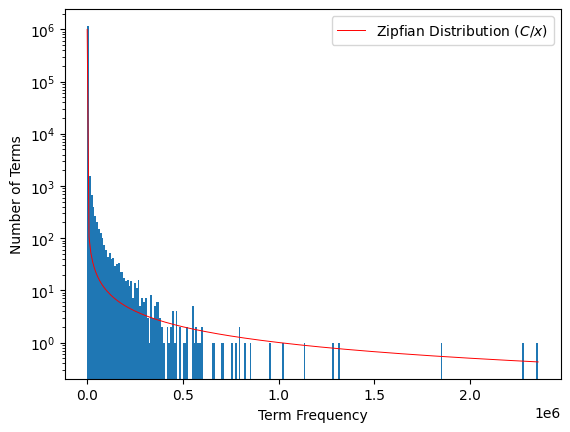

--- DONE ---


In [ ]:
print(f"Loading index...")
if index_ref is None:
    index_path_abs = os.path.abspath(index_pyterrier_dir)
    py_index = pt.IndexFactory.of(index_path_abs)   # type: ignore
else:
    py_index = pt.IndexFactory.of(index_ref)        # type: ignore

print(f"Checking index statistics...")
print(py_index.getCollectionStatistics().toString())

print(f"Plotting number of terms statistical trend...")
term_freqs = [kv.getValue().getFrequency() for kv in py_index.getLexicon()]

plt.hist(term_freqs, bins=250)
plt.yscale('log')
plt.xlabel('Term Frequency')
plt.ylabel('Number of Terms')

x_ref = np.linspace(1, max(term_freqs), 250)
C = 10**6
y_ref = C / (x_ref)
plt.plot(x_ref, y_ref, color='red', label="Zipfian Distribution ($C/x$)", linewidth=0.7)
plt.legend()

plt.show()

print(f"--- DONE ---")

As we can see from the graph, the *Number of Terms* follows a **Zipfian distribution**, which is good indicator for a well-done creation of the *index*: we can assume that it is statistically correct and it can be used for further tests.

## **14.2. PyTerrier Retriever**
After the creation of the *index*, we now need a way to access information inside it: we use the class `pyterrier.terrier.Retriever` to instantiate objects that we can use to perform *queries* on the *index*.

We specify the following parameters:
*   `index`, i.e. the *index* we want to use to perform the *queries*;
*   `wmodel=""`, i.e. the *weighting model* of the ranking function used by the *retriever*, in order to properly rank and order results;
*   `num_results`, i.e. the number of documents we want the *retriever* to return.

In [ ]:
tfidf = pt.terrier.Retriever(py_index, wmodel="TF_IDF", num_results=10) # type: ignore
bm25 = pt.terrier.Retriever(py_index, wmodel="BM25", num_results=10)   # type: ignore

We test both *retrievers* with a single *query* to check if they have been created correctly: we call on them the function `.search()`, which performs the query given as argument using the specific *retriever* on which it has been called.

In [ ]:
tfidf_results = tfidf.search("what slows down the flow of blood")
bm25_results = bm25.search("what slows down the flow of blood")

concat_results = pd.concat([tfidf_results, bm25_results], axis=1)
concat_results.columns = ["qid", "TFIDF_docid", "TFIDF_docno", "rank", "TFIDF_score", "query", "BM25_qid", "BM25_docid", "BM25_docno", "BM25_rank", "BM25_score", "BM25_query"]

columns_to_drop = ["qid", "query", "BM25_qid", "BM25_rank", "BM25_query"]
concat_results.drop(columns=columns_to_drop, inplace=True)

new_column_order = ["rank", "TFIDF_docid", "TFIDF_docno", "TFIDF_score", "BM25_docid", "BM25_docno", "BM25_score"]
concat_results = concat_results[new_column_order]

concat_results

,rank,TFIDF_docid,TFIDF_docno,TFIDF_score,BM25_docid,BM25_docno,BM25_score
0,0,4069373,4069373,19.899,4069373,4069373,36.189
1,1,4744533,4744533,19.699,4744533,4744533,35.866
2,2,7454708,7454708,18.793,7454708,7454708,34.214
3,3,7724054,7724054,18.623,7724054,7724054,33.891
4,4,841975,841975,18.540,841975,841975,33.764
5,5,130390,130390,18.366,130390,130390,33.446
6,6,3652655,3652655,18.356,3652655,3652655,33.428
7,7,7152561,7152561,18.180,7152561,7152561,33.105
8,8,6669588,6669588,17.871,6273537,6273537,32.525
9,9,6273537,6273537,17.866,6669588,6669588,32.524


After having verified that *retrievers* with both **TF-IDF** and **BM25** as *weighting models* work, we load from the disk *topics* (queries) and *qrels*, using the function `.read_csv()` provided by `pandas`: the function takes as input the path of a file and transforms its content into a `pandas.DataFrame`. For a correct import of data, we need also to specify:

*   `sep=""`, i.e. the *separator* that the function must use to identify a unique piece of data inside a single line of the file;
*   `names=[...]`, i.e. the names of the columns to be created in the dataframe structure.
*   `dtype={...}`, i.e. the type we want the columns to have in the dataframe.

We import both the *test-2019* and the *test-2020* query set and we merge them in a single query set to test the *retrievers* on all queries having also a relevance assessment (*qrels*).

In [ ]:
queries_2019 = pd.read_csv(queries_2019_path, sep='\t', names=["qid", "query"], dtype={'qid': str})
queries_2020 = pd.read_csv(queries_2020_path, sep='\t', names=["qid", "query"], dtype={'qid': str})
qrels_2019 = pd.read_csv(qrels_2019_path, sep=r'\s+', names=["qid", "iter", "docno", "label"], dtype={'qid': str, 'docno': str})
qrels_2020 = pd.read_csv(qrels_2020_path, sep=r'\s+', names=["qid", "iter", "docno", "label"], dtype={'qid': str, 'docno': str})

all_queries = pd.concat([queries_2019, queries_2020], ignore_index=True)
all_qrels = pd.concat([qrels_2019, qrels_2020], ignore_index=True)

The function `pandas.read_csv()` is mandatory to satisfy the requirements of the function `pyterrier.Experiment()`, which requires *topics* and *qrels* to be dataframes. It also requires `"qid"` and `"docno"` columns to be strings (for these reason we need to explicitely specify conversion into the parameters of function `.read_csv()`, otherwise, such columns would be interpreted as integers).

## **14.3. PyTerrier Experiment**
Now we have all the elements we need to call `pyterrier.Experiment()`, which allows us to perform retrieval and evaluation in a declarative fashion, allowing multiple retrieval systems to be executed using a single function call.

We explicit the following arguments.

*   `retr_systems=[tfidf, bm25]`: An array containing the *retrievers* to use in the *experiment* (therefore, we are telling the function the *collections*, the *indexes* and the *weighting models*)
*   `names=['TF-IDF', 'BM25']`: An array containing the names we want to give to our *retrievers* (they will appear in the first column of the result dataframe).
*   `topics=all_queries`: A dataframe containing the *queries* to perform.
*   `qrels=all_qrels`: A dataframe containing the *qrels* to check the results of the *queries*.
*   `eval_metrics=[P(rel=2)@10, RR, ...]`: An array containing the metrics to compute on the results, in order to carry out the evaluation of the performance of the system. We used the following metrics (the same used in section ***9. Load Metadata and Execute Queries (Conjunctive & Disjunctive)***):
    * `RR(rel=2)` to compute *Mean Reciprocal Rank (MRR)*;
    * `nDCG@10` to compute *Normalized Discounted Cumulative Gain (NDCG)* on the top 10 results;
    * `P(rel=2)@10` to compute *precision* on the top 10 results considering only documents with a relevance assessment equal or more than 2;
    * `R(rel=2)@10` to compute *recall* on the top 10 results considering only documents with a relevance assessment equal or more than 2;
    * `AP` to compute *Mean Average Precision (MAP)*;
    * `'mrt'` to compute *mean response time (mrt)* of the system, i.i.e. the average time the system takes to execute a single query.
*   `round={'RR(rel=2)': 4, 'nDCG@10': 4, ...},`: A document containing the number of decimal places reported in the result dataframe (can be a different one for each metric).
*   `baseline=0`: A value to specify that we want `pyterrier.Experiment()` to perform statistical tests and to provide us *p-values* as a result, computed using the `0`th system as baseline (the ordering among the systems tested is given by the parameter `retr_systems`).
* `test='wilcoxon'`: The statistical test we want `pyterrier.Experiment()` to perform.
*   `save_dir=results_pyterrier_dir`: The path of the directory in which we want the results to be saved before been displayed on screen.
*   `save_mode='overwrite'`: A string that specifies the behaviour that the `pyterrier.Experiment()` should have with previously saved results (if found in path `save_dir`). We used the following behaviours in different moments of the project:
    * `'overwrite'` forces the `pyterrier.Experiment()` to re-compute all metrics from scratch and saves new results to disk overwriting the previous results;
    * `'reuse'` let the `pyterrier.Experiment()` re-use the previous results, loading them from disk instead of re-computing them (**N.B.**: using this option we will get `0` as *MRT* in all rows).
*   `verbose=True`: A boolean that sets the verbosity of the output.

In [ ]:
res_exp_trial = pt.Experiment(
    retr_systems=[tfidf, bm25],
    names=['TF-IDF', 'BM25'],
    topics=all_queries,
    qrels=all_qrels,
    eval_metrics=[RR(rel=2), nDCG@10, P(rel=2)@10, R(rel=2)@10, AP(rel=2), 'mrt'], # type: ignore
    round={'RR(rel=2)': 4, 'nDCG@10': 4, 'P(rel=2)@10': 4, 'R(rel=2)@10': 4, 'AP(rel=2)': 4, 'mrt': 4},
    baseline=0,
    test='wilcoxon',
    save_dir=results_pyterrier_dir,
    save_mode='overwrite',
    verbose=True
)

with open(res_exp_trial_path, "w") as f:
    res_exp_trial.set_index("name", inplace=True)
    res_exp_trial.index.name = None
    res_exp_trial.to_csv(f, index=True)

res_exp_trial

pt.Experiment:   0%|          | 0/2 [00:00<?, ?system/s]

,AP(rel=2),RR(rel=2),P(rel=2)@10,R(rel=2)@10,nDCG@10,mrt,AP(rel=2) +,AP(rel=2) -,AP(rel=2) p-value,RR(rel=2) +,RR(rel=2) -,RR(rel=2) p-value,P(rel=2)@10 +,P(rel=2)@10 -,P(rel=2)@10 p-value,R(rel=2)@10 +,R(rel=2)@10 -,R(rel=2)@10 p-value,nDCG@10 +,nDCG@10 -,nDCG@10 p-value
TF-IDF,0.149,0.621,0.364,0.218,0.486,16879.611,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BM25,0.150,0.626,0.365,0.219,0.487,15201.477,3.000,3.000,0.600,1.000,0.000,0.317,1.000,0.000,0.317,1.000,0.000,0.317,5.000,4.000,0.767


As we can see from the results of the previous cell, by running a `pyterrier.Experiment()` we obtain all metrics we need in a single dataframe, which can be easily exported to a single CSV file saved to disk.

## **14.4. PyTerrier Results Visualization**
In the following cells, we import the CSV file containing the results of the previous `pyterrier.Experiment()` execution. We print on screen only the "main" metrics (without *p-values*) to check correctness of loading.

In [ ]:
res_exp_trial = pd.read_csv(res_exp_trial_path, index_col=0)
res_exp_trial.index.name = None

metrics = ['RR(rel=2)', 'nDCG@10', 'P(rel=2)@10', 'R(rel=2)@10', 'AP(rel=2)']
res_exp_trial_metrics = res_exp_trial[metrics]

res_exp_trial_metrics

,RR(rel=2),nDCG@10,P(rel=2)@10,R(rel=2)@10,AP(rel=2)
TF-IDF,0.621,0.486,0.364,0.218,0.149
BM25,0.626,0.487,0.365,0.219,0.150


In [ ]:
res_exp_trial_mrt = res_exp_trial['mrt'] / 1000
res_exp_trial_mrt

,mrt
TF-IDF,16.880
BM25,15.201


The following cell generate a figure comparing the evaluated models about the metrics we just excracted from the results dataframe. In this way, we obtain a clear comparison of the performance comparison between **TF-IDF** and **BM25**.

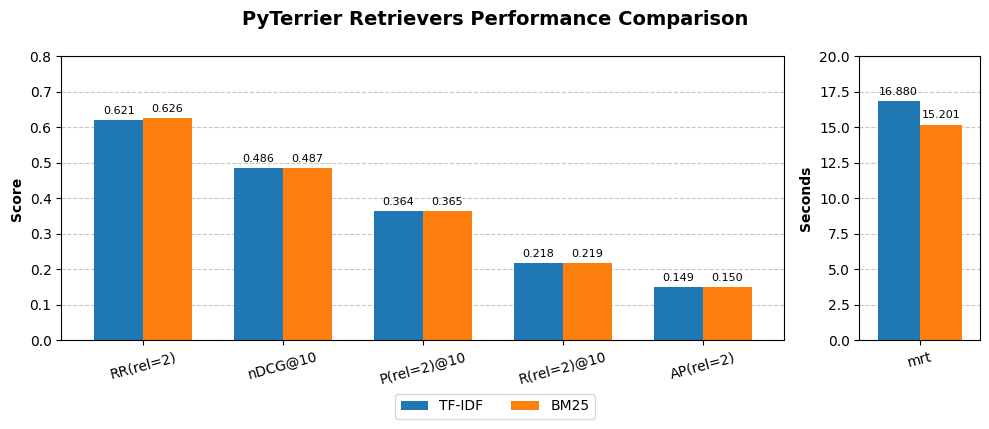

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [6, 1]})

# --- Subplot 1: Performance Metrics ---
x = np.arange(len(metrics))
width = 0.35
models = res_exp_trial_metrics.index
n_models = len(models)

for i, model_name in enumerate(models):
    offset = (i - n_models/2) * width + width/2
    values = res_exp_trial_metrics.loc[model_name].values
    rects = ax1.bar(x + offset, values, width, label=model_name)
    ax1.bar_label(rects, padding=3, fmt='%.3f', fontsize=8)

ax1.set_ylabel('Score', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics, rotation=15)
ax1.set_ylim(0, 0.8)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.set_axisbelow(True)

# --- Subplot 2: Mean Response Time ---
x_mrt = np.arange(1)
width_mrt = 0.35
models_mrt = res_exp_trial_mrt.index
n_models_mrt = len(models_mrt)

for i, model_name in enumerate(models_mrt):
    offset = (i - n_models_mrt/2) * width_mrt + width_mrt/2
    value = res_exp_trial_mrt.loc[model_name]
    rects = ax2.bar(x_mrt + offset, value, width_mrt, label=model_name)
    ax2.bar_label(rects, padding=3, fmt='%.3f', fontsize=8)

ax2.set_ylabel('Seconds', fontweight='bold')
ax2.set_xticks(x_mrt)
ax2.set_xticklabels(["mrt"], rotation=15)
ax2.set_xlim(-0.5, 0.5)
ax2.set_ylim(0, 20)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.set_axisbelow(True)

# --- Global Configuration ---
fig.suptitle('PyTerrier Retrievers Performance Comparison', fontsize=14, fontweight='bold')

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=n_models, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()

plt.savefig('graphs/pyterrier/perf_compare_pytfidf_pybm25.svg')
plt.show()

Looking at the graphs we do **not** see **great differences** between TF-IDF and BM25 in any metric. Taking into account that the we used a total of 400 queries, it took to the retrieving system made with PyTerrier an **average processing time** of:

*   $≈42ms/query$ using **TF-IDF** as weighting model;
*   $≈38ms/query$ using **BM25** as weighting model.

Therefore, PyTerrier turns out to be on average **$≈10\%$ faster using BM25** over TF-IDF.

We now need to display efficiently *Wilcoxon Test* results, showing *p-values* automathically computed by `pyterrier.Experiment()`.

The following code generates heatmaps for five metrics: **RR(rel=2)**, **nDCG@10**, **P(rel=2)@10**, **R(rel=2)@10**, and **AP(rel=2)** (`pyterrier.Experiment()` executes statistical tests only for these metrics). For each metric, a symmetric $2 \times 2$ matrix is constructed representing the comparison between systems.
* **<span style="color:green">Green</span>**: Indicates a statistically significant difference ($p < 0.05$).
* **<span style="color:red">Red</span>**: Indicates no statistically significant difference ($p \geq 0.05$).

The diagonal elements are masked as they represent self-comparison.

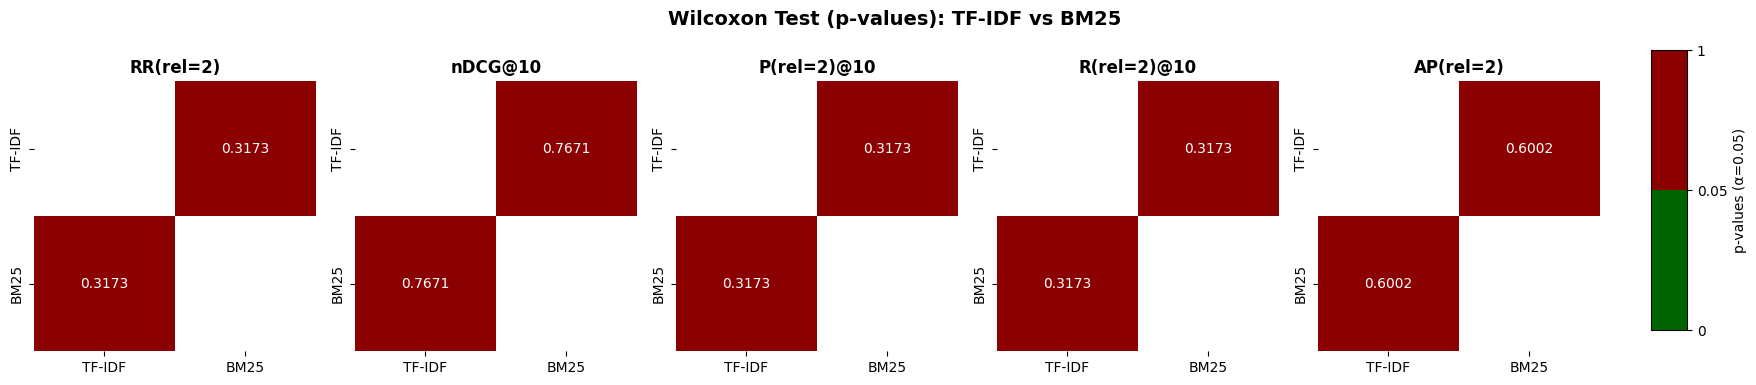

In [ ]:
models_names = ['TF-IDF', 'BM25']
metrics_config = {
    'RR(rel=2)': 'RR(rel=2) p-value',
    'nDCG@10': 'nDCG@10 p-value',
    'P(rel=2)@10': 'P(rel=2)@10 p-value',
    'R(rel=2)@10': 'R(rel=2)@10 p-value',
    'AP(rel=2)': 'AP(rel=2) p-value'
}

matrices = {}
for metric, col_name in metrics_config.items():
    mat = pd.DataFrame(np.zeros((len(models_names), len(models_names))), index=models_names, columns=models_names)

    p_val = res_exp_trial.loc['BM25', col_name]

    mat.loc['BM25', 'TF-IDF'] = p_val
    mat.loc['TF-IDF', 'BM25'] = p_val

    matrices[metric] = mat

colors = ['darkgreen', 'darkred']
cmap = mcolors.ListedColormap(colors)

bounds = [0, 0.05, 1.0]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
axes = axes.flatten()

mask = np.zeros_like(matrices['AP(rel=2)'], dtype=bool)
mask[np.diag_indices_from(mask)] = True

for i, (metric, mat) in enumerate(matrices.items()):
    ax = axes[i]

    sns.heatmap(mat,
                annot=True,
                annot_kws={"size": 10},
                fmt=".4f",
                cmap=cmap,
                norm=norm,
                mask=mask,
                cbar=False,
                ax=ax)

    ax.set_facecolor('white')

    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')

fig.suptitle(f'Wilcoxon Test (p-values): TF-IDF vs BM25', fontsize=14, fontweight='bold', y=0.95, x=0.5)

plt.tight_layout(rect=[0, 0, 0.9, 0.95])    # type: ignore

# --- Global Colorbar ---
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) # type: ignore

cb = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=cbar_ax,
    boundaries=bounds,
    ticks=[0, 0.05, 1],
    label="p-values (α=0.05)"
)

cb.ax.set_yticklabels(['0', '0.05', '1'])

plt.savefig('graphs/pyterrier/wilcoxon_heatmaps_pyterrier_oursystem.svg')
plt.show()

From the heatmaps we clearly see that we **cannot reject the *null hypothesis***, therefore we **cannot choose a winner** between the two retrieval systems: TF-IDF and BM25 cannot be declared statistically different.

Looking at the metrics graph some cells before and at these heatmaps, we can say that, from a practical point of view, the two systems seem to show **no difference** in performances in any metric.

# **15. Our Retrieving System VS PyTerrier**
In this last section we run a comparison between the optimal configuration of *our retrieving systems* (WAND/BM25) and the retrieving system built with *PyTerrier APIs*. For the latter, we use the configuration with BM25, since it was proved in section ***14.4. PyTerrier Results Visualization*** to have the same performances of TF-IDF in terms of performance metrics but slightly better in terms of execution time.

## **15.1. Evaluating metrics**
We lightly rewrite function `evaluate_system()` to let it evaluate the two systems we want to compare in this paragraph.

In [ ]:
print("Defining system evaluation function...")
def evaluate_system(all_qrels, k=10):
    results_pyte_bm25 = pd.read_csv("./results/pyterrier/BM25.res/BM25.res", sep=" ", index_col=False, dtype={'query_id': str, 'Q0': str, 'doc_id': str, 'rank': int, 'score': float, 'name': str})
    results_wand_bm25_opt = pd.read_csv(results_wand_bm25_opt_test_path, index_col=False, dtype={'query_id': str, 'doc_id': str, 'rank': int, 'score': float})

    all_results = {
        "pyte_bm25": results_pyte_bm25,
        "wand_bm25": results_wand_bm25_opt
    }

    all_metrics = defaultdict(dict)

    for results_name, results in all_results.items():
        grouped_results = results.groupby('query_id')
        for query_id, group in grouped_results:
            if query_id not in all_qrels:
                continue

            qrels = all_qrels[query_id]
            retrieved_docids = group['doc_id'].tolist()
            relevant_docids = [d for (d, r) in qrels.items() if r >= 2]
            if len(relevant_docids) == 0:
                continue

            p_at_k = precision_at_k(retrieved_docids, relevant_docids, k)
            r_at_k = recall_at_k(retrieved_docids, relevant_docids, k)
            rr = reciprocal_rank(retrieved_docids, relevant_docids)
            ap = average_precision(retrieved_docids, relevant_docids)
            nDCG_at_k = ndcg_at_k(retrieved_docids, qrels, k)

            all_metrics[results_name][query_id] = {
                f"P@{k}": p_at_k,
                f"R@{k}": r_at_k,
                "RR": rr,
                "AP": ap,
                f"nDCG@{k}": nDCG_at_k
            }

    mean_metrics = {}
    for results_name, metrics in all_metrics.items():
        mean_metrics[results_name] = {
            "RR": np.mean([m["RR"] for m in metrics.values()]),
            f"nDCG@{k}": np.mean([m[f"nDCG@{k}"] for m in metrics.values()]),
            f"P@{k}": np.mean([m[f"P@{k}"] for m in metrics.values()]),
            f"R@{k}": np.mean([m[f"R@{k}"] for m in metrics.values()]),
            "AP": np.mean([m["AP"] for m in metrics.values()])
        }
    print(f"--- MEAN METRICS ---")
    for results_name, metrics in mean_metrics.items():
        print(f"{results_name.upper()}:")
        for metric_name, metric_value in metrics.items():
            print(f"  {metric_name}: {metric_value:.4f}")
        print("")

    for results_name, metrics in all_metrics.items():
        metrics_df = pd.DataFrame.from_dict(metrics, orient='index')
        metrics_df.index.name = 'query_id'
        metrics_df.to_csv(f"metrics/opt/metrics_{results_name}.csv")

    return mean_metrics
print("System evaluation function defined successfully.")

Defining system evaluation function...
System evaluation function defined successfully.


We call the just defined function to compute the metrics of the two systems we want to compare in this paragraph.

In [ ]:
mean_metrics = evaluate_system(all_qrels, k=10)

--- MEAN METRICS ---
PYTE_BM25:
  RR: 0.6257
  nDCG@10: 0.4863
  P@10: 0.3649
  R@10: 0.2188
  AP: 0.1496

WAND_BM25:
  RR: 0.6345
  nDCG@10: 0.4857
  P@10: 0.3629
  R@10: 0.2136
  AP: 0.1513



## **15.2. Visualizing Comparison Results**
We plot the *mean metrics* obtained from previous metrics computation.

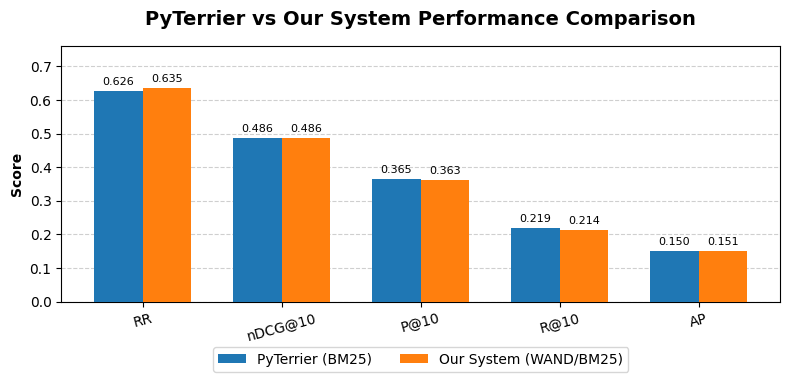

In [ ]:
metrics = list(mean_metrics['pyte_bm25'].keys())

pyte_bm25 = [mean_metrics['pyte_bm25'][m] for m in metrics]
wand_bm25 = [mean_metrics['wand_bm25'][m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

_, ax = plt.subplots(figsize=(8, 4))

rects1 = ax.bar(x - width/2, pyte_bm25, width, label='PyTerrier (BM25)', zorder=3)
rects2 = ax.bar(x + width/2, wand_bm25, width, label='Our System (WAND/BM25)', zorder=3)

ax.set_ylabel('Score', fontweight='bold', fontsize=10)
ax.set_title('PyTerrier vs Our System Performance Comparison', fontweight='bold', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=15, fontsize=10)

max_val = max(max(pyte_bm25), max(wand_bm25))
ax.set_ylim(0, max_val * 1.2)
ax.grid(axis='y', linestyle='--', alpha=0.6, zorder=0)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        if height > 0:
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)

autolabel(rects1)
autolabel(rects2)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=10)

plt.tight_layout()

plt.savefig("graphs/pyterrier/perf_compare_pyterrier_oursystem.svg", format='svg', bbox_inches='tight')
plt.show()

Looking at the graphs, we can state that **our system** shows more or less the **same matrics** than PyTerrier: this is perfectly reasonable considering that the main logic of the ranking process is based on the same algorithm, that is BM25.

The main advantage of PyTerrier over our system is *execution time*: looking back at previous sections, taking into account that we used 400 queries, it took to the retrieving systems an **average processing time** of:
*   $≈38ms/query$ to **PyTerrier retriever** using **BM25**.
*   $≈239ms/query$ to **our own retriever** using **BM25**.

Therefore, **PyTerrier (using BM25) turns out to be $≈83\% faster$** than our system using the best-performing combination of *matching strategy* and *weighting model*.

## **15.3. Statistical Tests**
Now, we perform statistical tests (*Wilcoxon Test*) to statistically validate the previous metrics results.

Aligned data on 97 common queries.
Running pairwise Wilcoxon tests...
Computation complete.


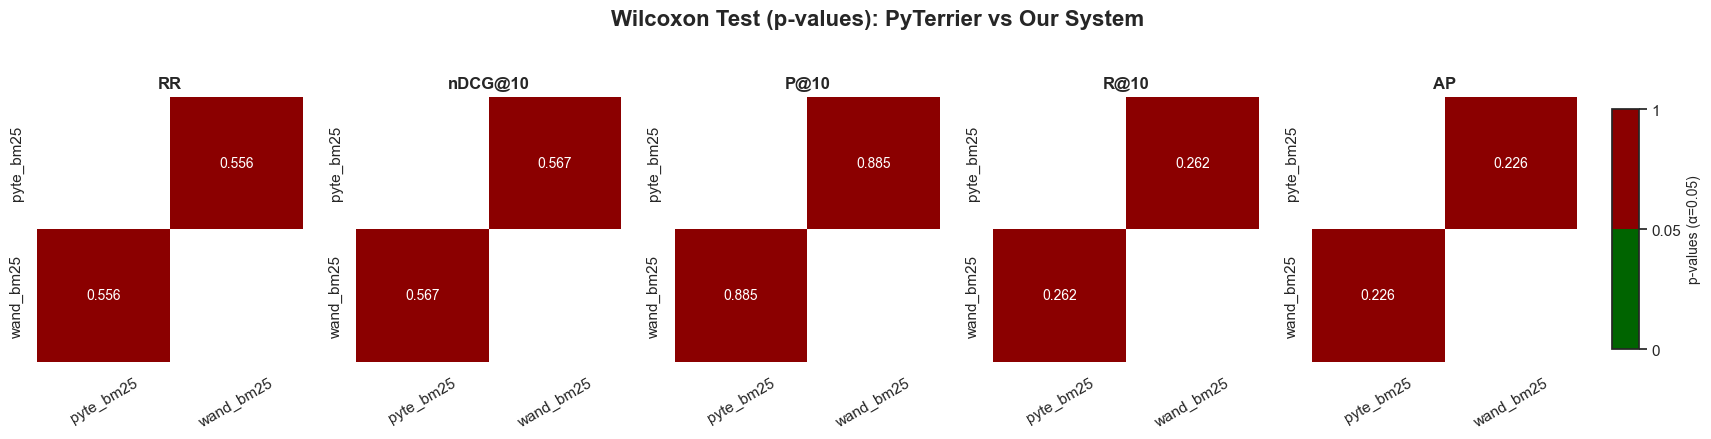

In [ ]:
system_files = {
    "pyte_bm25": "metrics/opt/metrics_pyte_bm25.csv",
    "wand_bm25": "metrics/opt/metrics_wand_bm25.csv"
}

k = 10
aligned_data = load_and_align_data(system_files)
system_names = list(aligned_data.keys())
z_matrices, p_matrices_wilcoxon = run_all_pairwise_wilcoxon(aligned_data, metrics)

sns.set_theme(style="white")
n_metrics = len(metrics)

fig, axes = plt.subplots(1, n_metrics, figsize=(3.5 * n_metrics, 4), squeeze=False)
axes = axes.flatten()

colors_p = ['darkgreen', 'darkred']
cmap_p = mcolors.ListedColormap(colors_p)
bounds_p = [0, 0.05, 1.0]
norm_p = mcolors.BoundaryNorm(bounds_p, cmap_p.N)

data_shape = p_matrices_wilcoxon[metrics[0]].shape
mask = np.eye(data_shape[0], dtype=bool)

for i, m in enumerate(metrics):
    ax = axes[i]
    sns.heatmap(p_matrices_wilcoxon[m].astype(float),
                annot=True,
                fmt=".3f",
                cmap=cmap_p,
                norm=norm_p,
                mask=mask,
                cbar=False,
                square=True,
                annot_kws={"size": 10},
                ax=ax)

    ax.set_title(f'{m}', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Wilcoxon Test (p-values): PyTerrier vs Our System', fontsize=16, fontweight='bold', y=1.05)

plt.subplots_adjust(left=0.02, right=0.90, bottom=0.15, top=0.85)
cbar_ax = fig.add_axes([0.92, 0.20, 0.015, 0.60])   # type: ignore
cb = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm_p, cmap=cmap_p),
    cax=cbar_ax,
    boundaries=bounds_p,
    ticks=[0, 0.05, 1]
)
cb.ax.set_yticklabels(['0', '0.05', '1'])
cb.set_label("p-values (α=0.05)", fontsize=10)

plt.savefig("graphs/pyterrier/wilcoxon_heatmaps_combined.svg", format='svg', bbox_inches='tight')
plt.show()

for m in metrics:
    z_matrices[m].to_csv(f"wilcoxon/pyterrier/z_scores_{m}.csv")
    p_matrices_wilcoxon[m].to_csv(f"wilcoxon/pyterrier/p_values_{m}.csv")

From the heatmaps we clearly see that we **cannot reject the *null hypothesis***, therefore we **cannot choose a winner** between the two retrieval systems: PyTerrier using BM25 and our system using BM25 cannot be declared statistically different.

Looking at the metrics graph some cells before and at these heatmaps, we can say that, from a practical point of view, the two systems seem to show **no difference** in performances in any metric.